# Clean Gemma 4 + MedGemma Medical Quantization Benchmark

This simplified notebook benchmarks only:

- `google/gemma-4-E4B-it`
- `google/gemma-4-12B-it`
- `google/medgemma-1.5-4b-it`

Each model is tested as Baseline BF16/FP16, BitsAndBytes INT8, and BitsAndBytes INT4 NF4 on PubMedQA, MedQA, and MedMCQA. The old Gemma 2 runner, legacy MedGemma runner, and AWQ/GPTQ benchmark are intentionally not included. Google Drive is mounted once near the start and every checkpoint is saved directly into one dated Corrected Pipeline folder; Hugging Face publishing remains optional.

This notebook is **Experiment A: CUDA + bitsandbytes**, which is the main experiment. Any Mac mini results belong to **Experiment B: Apple Silicon + MLX** and remain preliminary until complete. CUDA and MLX speed/memory numbers must not be compared directly because MXFP8, MLX 4-bit, bitsandbytes INT8, and bitsandbytes NF4 are different implementations.


## 1. Runtime Check


In [1]:
import os, platform, subprocess, sys

def command_output(command):
    '''Return command output without failing the notebook.'''
    try:
        return subprocess.check_output(command, text=True, stderr=subprocess.STDOUT).strip()
    except Exception as exc:
        return f"Unavailable ({type(exc).__name__}: {exc})"

try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name}")
        print(f"Total GPU memory: {props.total_memory / 2**30:.2f} GiB")
    else:
        print("WARNING: No CUDA GPU is available. Select Runtime > Change runtime type > GPU.")
    print(f"CUDA reported by PyTorch: {torch.version.cuda}")
    print(f"PyTorch: {torch.__version__}")
except Exception as exc:
    print(f"PyTorch environment check failed: {exc}")

print(f"Python: {platform.python_version()}")
print("Driver / nvidia-smi:")
print(command_output(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]))


GPU: NVIDIA A100-SXM4-40GB
Total GPU memory: 39.49 GiB
CUDA reported by PyTorch: 12.8
PyTorch: 2.11.0+cu128
Python: 3.12.13
Driver / nvidia-smi:
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07


## 2. Install Dependencies


In [2]:
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "transformers==5.14.1" "datasets==5.0.0" "accelerate==1.14.0" \
  "bitsandbytes==0.49.2" "huggingface_hub>=1.2,<2" \
  "sentencepiece>=0.2,<0.3" "psutil>=5.9,<8" "tqdm>=4.67,<5"

# Diagnostic only: any remaining lines are pre-existing runtime conflicts.
!python -m pip check


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 113.9 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 52.0 MB/s eta 0:00:00:00:0100:01
ipython 7.34.0 requires jedi, which is not installed.


## 3. Imports


In [3]:
import gc
import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import re
import shutil
import statistics
import subprocess
import sys
import threading
import time
import traceback
import warnings
from contextlib import nullcontext
from datetime import datetime, timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import psutil
import torch
import transformers
from datasets import load_dataset
from huggingface_hub import HfApi, notebook_login, scan_cache_dir
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor, AutoTokenizer, BitsAndBytesConfig, set_seed

def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "not installed"

print("Transformers:", transformers.__version__)
print("Datasets:", package_version("datasets"))
print("Accelerate:", package_version("accelerate"))
print("BitsAndBytes:", package_version("bitsandbytes"))

Transformers: 5.14.1
Datasets: 5.0.0
Accelerate: 1.14.0
BitsAndBytes: 0.49.2


## 4. Configuration


In [4]:
from google.colab import drive
from pathlib import Path

def ensure_google_drive():
    '''Reuse an existing Drive mount or create a clean fallback mountpoint.'''
    def verify_writable(root):
        probe = root / f".gemma_benchmark_write_test_{os.getpid()}.txt"
        probe.write_text("ok\n", encoding="utf-8")
        if probe.read_text(encoding="utf-8").strip() != "ok":
            raise RuntimeError(f"Google Drive write verification failed at {root}")
        probe.unlink()
        return root

    candidates = [Path("/content/drive"), Path("/content/google_drive"),
                  Path("/content/gemma_benchmark_drive")]
    for mountpoint in candidates:
        root = mountpoint / "MyDrive"
        if root.is_dir():
            verify_writable(root)
            print("Google Drive already mounted at:", root)
            return root
    for mountpoint in candidates:
        mountpoint.mkdir(parents=True, exist_ok=True)
        if not any(mountpoint.iterdir()):
            drive.mount(str(mountpoint))
            root = mountpoint / "MyDrive"
            if root.is_dir():
                verify_writable(root)
                print("Google Drive mounted at:", root)
                return root
    raise RuntimeError(
        "Could not mount Google Drive: all candidate mountpoints contain non-Drive files. "
        "Restart the runtime or empty one fallback mountpoint."
    )

DRIVE_ROOT = ensure_google_drive()

Mounted at /content/drive
Google Drive mounted at: /content/drive/MyDrive


In [5]:
MODEL_ID = None
MODEL_REVISION = None

MODEL_FAMILIES = {
    "Gemma4-E4B": {"model_id": "google/gemma-4-E4B-it", "revision": None, "enabled": True},
    "Gemma4-12B": {"model_id": "google/gemma-4-12B-it", "revision": None, "enabled": True},
    "MedGemma": {"model_id": "google/medgemma-1.5-4b-it", "revision": None, "enabled": True},
}

RUN_PRECISIONS = {"Baseline": True, "INT8": True, "INT4-NF4": True}
REFERENCE_PRECISION = "Baseline"

BENCHMARKS = ["pubmedqa", "medqa", "medmcqa"]
DATASET_CONFIGS = {
    "pubmedqa": {"path": "qiaojin/PubMedQA", "name": "pqa_labeled", "split": "train", "revision": None},
    "medqa": {"path": "GBaker/MedQA-USMLE-4-options", "name": None, "split": "test", "revision": None},
    "medmcqa": {"path": "openlifescienceai/medmcqa", "name": None, "split": "validation", "revision": None},
}

# One automatic smoke flow: constrained 100, then free generation 5 per dataset.
EVALUATION_MODES = ["constrained", "free_generation"]
PRIMARY_EVALUATION_MODE = "constrained"
MAX_SAMPLES_PER_DATASET = 300
FREE_GENERATION_MAX_SAMPLES_PER_DATASET = 5
FREE_GENERATION_MAX_NEW_TOKENS = 64

# Every configuration first runs this small subset. The full run starts only
# after constrained scoring has 100% coverage and no scoring errors.
RUN_SMOKE_TEST = True
SMOKE_TEST_ONLY = True  # True = stop after 100 constrained questions/dataset/configuration
SMOKE_SAMPLES_PER_DATASET = 100

BATCH_SIZE = 1
CHECKPOINT_EVERY_N_QUESTIONS = 5
NUM_WARMUP_RUNS = 5
NUM_TIMED_RUNS = 30
RANDOM_SEED = 1337
BANGKOK_TZ = ZoneInfo("Asia/Bangkok")
RUN_DATE = datetime.now(BANGKOK_TZ).strftime("%Y%m%d")
DRIVE_RESULTS_BASE = DRIVE_ROOT / "gemma4_medgemma_benchmark_results"
RUN_FOLDER_NAME = f"corrected_pipeline_v6_{RUN_DATE}"
OUTPUT_DIR = str(DRIVE_RESULTS_BASE / "runs" / RUN_FOLDER_NAME)
FIGURE_DIR = Path(OUTPUT_DIR) / "figures"

ENABLE_CPU_OFFLOAD_FALLBACK = False
CPU_OFFLOAD_FOLDER = f"{OUTPUT_DIR}/offload"
TRUST_REMOTE_CODE = False
MULTI_FAMILY_PREFIX = "clean_three_model_v6"
EXPERIMENT_VERSION = "corrected-constrained-v6"
SCORING_METHOD_VERSION = "context-verified-next-token-v5"

SCORING_PROMPT_TEMPLATE = '''You are answering a medical multiple-choice question.

{context_block}Question:
{question}

Choices:
{choices}

Select the single best answer from {allowed_letters}.
Answer:'''

FREE_GENERATION_PROMPT_TEMPLATE = '''You are answering a medical multiple-choice question.

{context_block}Question:
{question}

Choices:
{choices}

Return exactly one final answer line.

Rules:
- Do not explain.
- Do not include reasoning.
- Choose exactly one option.
- For PubMedQA, answer with: Final answer: yes / no / maybe
- For MedQA and MedMCQA, answer with: Final answer: A / B / C / D

Final answer:'''

FREE_GENERATION_REPAIR_ON_INVALID = True
FREE_GENERATION_REPAIR_MAX_NEW_TOKENS = 16
FREE_GENERATION_REPAIR_PROMPT_TEMPLATE = '''The previous response did not follow the required answer format.

Question:
{question}

Choices:
{choices}

Previous response:
{previous_response}

Return exactly one line and nothing else.
Allowed answers: {allowed_letters}
Final answer:'''

GENERATION_PARAMETERS = {
    "do_sample": False,
    "temperature": 0.0,
    "max_new_tokens": FREE_GENERATION_MAX_NEW_TOKENS,
    "use_cache": True,
}

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_RESULTS_BASE.mkdir(parents=True, exist_ok=True)
(DRIVE_RESULTS_BASE / "CURRENT_RUN.txt").write_text(
    f"{RUN_FOLDER_NAME}\n{OUTPUT_DIR}\n", encoding="utf-8"
)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
set_seed(RANDOM_SEED)

ACTIVE_FAMILIES = [name for name, cfg in MODEL_FAMILIES.items() if cfg.get("enabled", True)]
ACTIVE_PRECISIONS = [name for name, enabled in RUN_PRECISIONS.items() if enabled]
CONFIGURATION_INDEX = {
    f"{family} {precision}": (family, precision)
    for family in ACTIVE_FAMILIES for precision in ACTIVE_PRECISIONS
}

print("Active models:", ACTIVE_FAMILIES)
print("Active precisions:", ACTIVE_PRECISIONS)
print("Evaluation modes:", EVALUATION_MODES)
print("Results will be written to", OUTPUT_DIR)

Active models: ['Gemma4-E4B', 'Gemma4-12B', 'MedGemma']
Active precisions: ['Baseline', 'INT8', 'INT4-NF4']
Evaluation modes: ['constrained', 'free_generation']
Results will be written to /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819


## 5. Hugging Face Login

Run this if Hugging Face asks for access. MedGemma usually requires accepting terms on the model page first.


In [6]:
# Run when the selected model or dataset is gated.
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 6. Load Datasets


In [7]:
def save_json(data, filename):
    '''Write JSON atomically enough for routine Colab use.'''
    path = Path(OUTPUT_DIR) / filename
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with temp_path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, ensure_ascii=False, default=str)
    temp_path.replace(path)
    return path

def save_csv(data, filename, columns=None):
    '''Write a valid CSV atomically; empty results still retain readable headers.'''
    path = Path(OUTPUT_DIR) / filename
    frame = data.copy() if isinstance(data, pd.DataFrame) else pd.DataFrame(data)
    if frame.empty and columns:
        frame = pd.DataFrame(columns=columns)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp_path, index=False)
    temp_path.replace(path)
    return path

def refresh_output_manifest(status="checkpoint"):
    '''Create a human-readable inventory proving which files reached Drive.'''
    base = Path(OUTPUT_DIR)
    files = []
    for item in sorted(base.rglob("*")):
        relative = item.relative_to(base)
        if relative.parts and relative.parts[0] == "organized":
            continue
        if item.is_file() and not item.name.endswith(".tmp") and item.name != "OUTPUT_MANIFEST.json":
            files.append({"path": str(relative), "bytes": item.stat().st_size})
    manifest = {
        "status": status, "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "output_dir": str(base), "run_folder": RUN_FOLDER_NAME,
        "file_count": len(files), "files": files,
    }
    save_json(manifest, "OUTPUT_MANIFEST.json")
    return manifest

def refresh_organized_output():
    '''Mirror current root artifacts into stable, professor-friendly subfolders.'''
    base = Path(OUTPUT_DIR)
    organized = base / "organized"
    folders = {
        "raw": organized / "01_raw_predictions",
        "summary": organized / "02_summary_tables",
        "performance": organized / "03_performance_and_memory",
        "reports": organized / "04_reports_and_analysis",
        "figures": organized / "05_figures",
        "config": organized / "06_config_and_sample_ids",
        "errors": organized / "07_errors_and_failures",
        "other": organized / "08_other",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    for item in base.iterdir():
        if not item.is_file() or item.name.endswith((".tmp", ".zip")):
            continue
        name = item.name.lower()
        if "raw_prediction" in name or "diagnostic" in name:
            target = folders["raw"]
        elif "performance" in name or "memory" in name:
            target = folders["performance"]
        elif any(key in name for key in ("summary", "comparison", "table_", "mcnemar", "relative", "tradeoff", "chance_floor")):
            target = folders["summary"]
        elif item.suffix.lower() == ".md":
            target = folders["reports"]
        elif any(key in name for key in ("config", "sample_id", "manifest", "environment")):
            target = folders["config"]
        elif any(key in name for key in ("error", "failure")):
            target = folders["errors"]
        else:
            target = folders["other"]
        shutil.copy2(item, target / item.name)
    if FIGURE_DIR.exists():
        shutil.copytree(FIGURE_DIR, folders["figures"], dirs_exist_ok=True)
    (organized / "README.txt").write_text(
        "Corrected Pipeline v3 organized output\n"
        "Primary metric: constrained conditional answer-surface scoring.\n"
        "Smoke results use 10 questions per dataset and are preliminary.\n",
        encoding="utf-8",
    )
    return organized

def friendly_access_error(exc, resource):
    text = str(exc)
    if any(term in text.lower() for term in ("401", "403", "gated", "unauthorized")):
        return f"Access denied for {resource}. Accept its license and run notebook_login(). Original error: {text}"
    if any(term in text.lower() for term in ("not found", "404", "doesn't exist")):
        return f"Resource not found: {resource}. Check its ID, configuration, and split. Original error: {text}"
    return f"Could not load {resource}: {type(exc).__name__}: {text}"

raw_datasets = {}
dataset_errors = {}
requested_benchmarks = list(BENCHMARKS)

for benchmark in requested_benchmarks:
    cfg = DATASET_CONFIGS.get(benchmark, {})
    if not cfg.get("path"):
        dataset_errors[benchmark] = f"No dataset path configured for optional benchmark '{benchmark}'."
        print("SKIP:", dataset_errors[benchmark])
        continue
    try:
        kwargs = {"path": cfg["path"], "split": cfg["split"]}
        if cfg.get("name"):
            kwargs["name"] = cfg["name"]
        if cfg.get("revision"):
            kwargs["revision"] = cfg["revision"]
        raw_datasets[benchmark] = load_dataset(**kwargs)
        print(f"Loaded {benchmark}: {len(raw_datasets[benchmark]):,} rows")
    except Exception as exc:
        dataset_errors[benchmark] = friendly_access_error(exc, cfg.get("path", benchmark))
        print("ERROR:", dataset_errors[benchmark])

save_json(dataset_errors, "dataset_errors.json")


README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded pubmedqa: 1,000 rows


...

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Loaded medmcqa: 4,183 rows


PosixPath('/content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/dataset_errors.json')

## 7. Normalize Datasets


In [8]:
LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def first_present(row, keys, default=None):
    for key in keys:
        if key in row and row[key] is not None:
            return row[key]
    return default

def normalize_answer(value, choices, benchmark):
    '''Map textual, letter, or numeric answers to a choice letter.'''
    if value is None:
        return None
    labels = list(choices)
    text = str(value).strip()
    lowered = text.lower()
    if benchmark == "pubmedqa":
        return {"yes": "A", "no": "B", "maybe": "C", "a": "A", "b": "B", "c": "C"}.get(lowered)
    if text.upper() in labels:
        return text.upper()
    if lowered in {str(v).strip().lower() for v in choices.values()}:
        for label, choice_text in choices.items():
            if lowered == str(choice_text).strip().lower():
                return label
    try:
        number = int(value)
        # MedMCQA's `cop` is zero-based. Other common numeric answers may be one-based.
        if benchmark == "medmcqa" and 0 <= number < len(labels):
            return labels[number]
        if 1 <= number <= len(labels):
            return labels[number - 1]
        if 0 <= number < len(labels):
            return labels[number]
    except (TypeError, ValueError):
        pass
    match = re.search(r"\b([A-Z])\b", text.upper())
    return match.group(1) if match and match.group(1) in labels else None

def normalize_choices(value, row, benchmark):
    if benchmark == "pubmedqa":
        return {"A": "Yes", "B": "No", "C": "Maybe"}
    if isinstance(value, dict):
        # Some datasets store {label: [...], text: [...]}.
        if isinstance(value.get("label"), (list, tuple)) and isinstance(value.get("text"), (list, tuple)):
            return {str(k).upper(): str(v) for k, v in zip(value["label"], value["text"])}
        normalized = {}
        for key, item in value.items():
            key_text = str(key).strip().upper()
            if key_text in LETTERS:
                normalized[key_text] = str(item)
        if normalized:
            return dict(sorted(normalized.items(), key=lambda pair: LETTERS.index(pair[0])))
    if isinstance(value, (list, tuple)):
        return {LETTERS[i]: str(item) for i, item in enumerate(value)}
    option_fields = [
        ["opa", "option_a", "choice_a", "A"], ["opb", "option_b", "choice_b", "B"],
        ["opc", "option_c", "choice_c", "C"], ["opd", "option_d", "choice_d", "D"],
        ["ope", "option_e", "choice_e", "E"],
    ]
    choices = {}
    for i, aliases in enumerate(option_fields):
        item = first_present(row, aliases)
        if item is not None and str(item).strip():
            choices[LETTERS[i]] = str(item)
    return choices

def normalize_context(value):
    if value is None:
        return ""
    if isinstance(value, dict):
        value = first_present(value, ["contexts", "context", "text"], value)
    if isinstance(value, (list, tuple)):
        return "\n".join(str(item) for item in value if item is not None)
    return str(value)

def normalize_row(row, benchmark, row_index):
    question = first_present(row, ["question", "question_stem", "query", "prompt"])
    choice_value = first_present(row, ["choices", "options", "answer_options"])
    choices = normalize_choices(choice_value, row, benchmark)
    answer_value = first_present(row, ["answer_idx", "answer", "label", "cop", "correct", "final_decision"])
    answer = normalize_answer(answer_value, choices, benchmark)
    sample_id = first_present(row, ["id", "question_id", "qid", "pubid", "uid"], f"{benchmark}-{row_index}")
    context = normalize_context(first_present(row, ["context", "contexts", "long_answer"]))
    return {
        "id": str(sample_id), "question": "" if question is None else str(question).strip(),
        "choices": choices, "answer": answer, "benchmark": benchmark, "context": context.strip(),
    }

def validate_samples(samples):
    '''Return valid samples and structured validation errors.'''
    valid, errors, seen = [], [], set()
    for sample in samples:
        problems = []
        if not sample["question"]:
            problems.append("missing question")
        if len(sample["choices"]) < 2 or any(not str(v).strip() for v in sample["choices"].values()):
            problems.append("missing/insufficient choices")
        if sample["answer"] not in sample["choices"]:
            problems.append(f"invalid answer label: {sample['answer']!r}")
        unique_key = f"{sample['benchmark']}::{sample['id']}"
        if unique_key in seen:
            problems.append("duplicate sample ID")
        seen.add(unique_key)
        if problems:
            errors.append({"id": sample["id"], "benchmark": sample["benchmark"], "problems": problems})
        else:
            valid.append(sample)
    return valid, errors

normalized_datasets, preprocessing_errors, sample_ids = {}, {}, {}
for benchmark, dataset in raw_datasets.items():
    try:
        candidates = [normalize_row(row, benchmark, i) for i, row in enumerate(dataset)]
        valid, errors = validate_samples(candidates)
        rng = random.Random(f"{RANDOM_SEED}:{benchmark}")
        shuffled = list(valid)
        rng.shuffle(shuffled)
        selected_pool = shuffled[: min(MAX_SAMPLES_PER_DATASET, len(shuffled))]
        # Keep the full 300-question sample random, but make the first smoke prefix
        # approximately label-balanced so a 10-question diagnostic is less misleading.
        buckets = {label: [] for label in sorted({item['answer'] for item in selected_pool})}
        for item in selected_pool:
            buckets[item['answer']].append(item)
        smoke_prefix = []
        while len(smoke_prefix) < min(SMOKE_SAMPLES_PER_DATASET, len(selected_pool)):
            added = False
            for label in buckets:
                if buckets[label] and len(smoke_prefix) < SMOKE_SAMPLES_PER_DATASET:
                    smoke_prefix.append(buckets[label].pop())
                    added = True
            if not added:
                break
        smoke_ids = {item['id'] for item in smoke_prefix}
        selected = smoke_prefix + [item for item in selected_pool if item['id'] not in smoke_ids]
        normalized_datasets[benchmark] = selected
        preprocessing_errors[benchmark] = errors[:1000]
        sample_ids[benchmark] = [item["id"] for item in selected]
        print(f"{benchmark}: {len(selected)} selected, {len(errors)} rejected")
    except Exception as exc:
        dataset_errors[benchmark] = f"Schema adapter failed: {type(exc).__name__}: {exc}"
        print(f"ERROR preprocessing {benchmark}: {dataset_errors[benchmark]}")

if not normalized_datasets:
    print("WARNING: No benchmark is ready. Fix dataset access/configuration before model evaluation.")
save_json(preprocessing_errors, "preprocessing_errors.json")
save_json(sample_ids, "sample_ids.json")

MODEL_IDENTITIES = {}
for family in ACTIVE_FAMILIES:
    settings = MODEL_FAMILIES[family]
    model_id = settings["model_id"]
    requested_revision = settings.get("revision")
    try:
        resolved_revision = HfApi().model_info(model_id, revision=requested_revision).sha
        fingerprint_processor = AutoProcessor.from_pretrained(
            model_id, revision=resolved_revision, trust_remote_code=TRUST_REMOTE_CODE
        )
        fingerprint_tokenizer = getattr(fingerprint_processor, "tokenizer", fingerprint_processor)
        effective_template = (getattr(fingerprint_processor, "chat_template", None)
                              or getattr(fingerprint_tokenizer, "chat_template", None))
        if not effective_template:
            raise RuntimeError("No chat template was found in the model processor/tokenizer.")
        template_text = (json.dumps(effective_template, sort_keys=True, ensure_ascii=False)
                         if not isinstance(effective_template, str) else effective_template)
        template_hash = hashlib.sha256(template_text.encode("utf-8")).hexdigest()
        settings["resolved_revision"] = resolved_revision
        MODEL_IDENTITIES[family] = {
            "model_id": model_id,
            "requested_revision": requested_revision,
            "resolved_revision": resolved_revision,
            "chat_template_sha256": template_hash,
        }
        del fingerprint_processor, fingerprint_tokenizer
    except Exception as exc:
        raise RuntimeError(
            f"Cannot establish immutable model identity for {family} ({model_id}). "
            "Accept the model license, run notebook_login(), and rerun this cell. "
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc

fingerprint_payload = {
    "experiment_version": EXPERIMENT_VERSION,
    "models": MODEL_FAMILIES,
    "model_identities": MODEL_IDENTITIES,
    "precisions": RUN_PRECISIONS,
    "datasets": DATASET_CONFIGS,
    "sample_ids": sample_ids,
    "evaluation_modes": EVALUATION_MODES,
    "primary_evaluation_mode": PRIMARY_EVALUATION_MODE,
    "scoring_method": {
        "name": SCORING_METHOD_VERSION,
        "candidate_boundary_policy": "verify prompt+surface tokenization before scoring",
        "pubmedqa_candidates": ["yes", "no", "maybe"],
        "medqa_candidates": ["A", "B", "C", "D"],
        "medmcqa_candidates": ["A", "B", "C", "D"],
    },
    "chat_template_policy": "model processor apply_chat_template(add_generation_prompt=True)",
    "scoring_prompt": SCORING_PROMPT_TEMPLATE,
    "free_generation_prompt": FREE_GENERATION_PROMPT_TEMPLATE,
    "free_generation_repair_prompt": FREE_GENERATION_REPAIR_PROMPT_TEMPLATE,
    "free_generation_repair_on_invalid": FREE_GENERATION_REPAIR_ON_INVALID,
    "free_generation_repair_max_new_tokens": FREE_GENERATION_REPAIR_MAX_NEW_TOKENS,
    "generation_parameters": GENERATION_PARAMETERS,
    "free_generation_max_samples_per_dataset": FREE_GENERATION_MAX_SAMPLES_PER_DATASET,
    "random_seed": RANDOM_SEED,
}
fingerprint_json = json.dumps(fingerprint_payload, sort_keys=True, ensure_ascii=False, default=str)
EXPERIMENT_FINGERPRINT = hashlib.sha256(fingerprint_json.encode("utf-8")).hexdigest()[:16]
RUN_PREFIX = f"{MULTI_FAMILY_PREFIX}_{EXPERIMENT_FINGERPRINT}"

save_json({
    **fingerprint_payload,
    "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
    "run_prefix": RUN_PREFIX,
    "max_samples_per_dataset": MAX_SAMPLES_PER_DATASET,
    "batch_size": BATCH_SIZE,
    "note": "Pre-experiment checkpoint; resolved revisions and environment metadata are saved later.",
}, f"{RUN_PREFIX}_experiment_config.json")

print("Experiment fingerprint:", EXPERIMENT_FINGERPRINT)
print("Checkpoint prefix:", RUN_PREFIX)

pubmedqa: 300 selected, 0 rejected
medqa: 300 selected, 0 rejected
medmcqa: 300 selected, 0 rejected


processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.14k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Experiment fingerprint: 25d8fa6d6b2ca4bb
Checkpoint prefix: clean_three_model_v6_25d8fa6d6b2ca4bb


## 8. Prompting and Two-Mode Evaluation

The notebook now separates two different questions:

1. **Constrained scoring (primary):** compares the next-token log-probabilities of the allowed labels. This measures medical multiple-choice knowledge with 100% answer coverage and no answer parser.
2. **Free generation (secondary):** lets the model reason and then parses an explicit `Final answer:` line. This measures instruction/format following and reports validity, truncation, and token-cap rates separately.

Each model family uses its own `apply_chat_template()`. The rendered prompt is printed once per family before inference.

In [9]:
def constrained_answer_surfaces(sample):
    if sample["benchmark"] == "pubmedqa":
        return {"A": "yes", "B": "no", "C": "maybe"}
    return {label: label for label in sample["choices"]}

def format_prompt(sample, template, answer_surfaces=None):
    context_block = f"Context:\n{sample['context']}\n\n" if sample.get("context") else ""
    if answer_surfaces and sample["benchmark"] == "pubmedqa":
        choices = "\n".join(answer_surfaces.values())
        allowed = ", ".join(answer_surfaces.values())
    else:
        choices = "\n".join(f"{label}. {text}" for label, text in sample["choices"].items())
        allowed = ", ".join(sample["choices"].keys())
    return template.format(
        context_block=context_block, question=sample["question"], choices=choices,
        allowed_letters=allowed,
    )

def format_plain_prompt(sample, evaluation_mode="free_generation"):
    template = (SCORING_PROMPT_TEMPLATE if evaluation_mode == "constrained"
                else FREE_GENERATION_PROMPT_TEMPLATE)
    answer_surfaces = constrained_answer_surfaces(sample) if evaluation_mode == "constrained" else None
    return format_prompt(sample, template, answer_surfaces)

def format_model_prompt(sample, tokenizer, evaluation_mode="free_generation"):
    plain = format_plain_prompt(sample, evaluation_mode)
    if getattr(tokenizer, "chat_template", None):
        return tokenizer.apply_chat_template(
            [{"role": "user", "content": plain}], tokenize=False, add_generation_prompt=True
        )
    raise RuntimeError(
        "This instruction-tuned benchmark requires the model's chat template; none was found."
    )

def format_repair_prompt(sample, tokenizer, previous_response):
    if sample["benchmark"] == "pubmedqa":
        choices = "\n".join(constrained_answer_surfaces(sample).values())
        allowed = "yes, no, maybe"
    else:
        choices = "\n".join(f"{label}. {text}" for label, text in sample["choices"].items())
        allowed = ", ".join(sample["choices"].keys())
    plain = FREE_GENERATION_REPAIR_PROMPT_TEMPLATE.format(
        question=sample["question"], choices=choices, allowed_letters=allowed,
        previous_response=str(previous_response)[-1200:],
    )
    if getattr(tokenizer, "chat_template", None):
        return tokenizer.apply_chat_template(
            [{"role": "user", "content": plain}], tokenize=False, add_generation_prompt=True
        )
    raise RuntimeError(
        "This instruction-tuned benchmark requires the model's chat template; none was found."
    )

def extract_answer(output, choices):
    '''Parse only an explicit final answer; never guess from arbitrary reasoning text.'''
    if output is None or not str(output).strip():
        return "INVALID"
    labels = list(choices)
    choice_texts = choices if isinstance(choices, dict) else {}
    text = re.sub(r"[*_`]+", "", str(output)).strip()
    if not text:
        return "INVALID"
    first_word = text.split()[0].strip(".,:;!?()[]\"'").casefold()
    if first_word in {"yes", "no", "maybe"} and choice_texts:
        matched = [label for label, value in choice_texts.items()
                   if first_word == str(value).strip().casefold()]
        if len(matched) == 1:
            return matched[0]

    # Prefer the last explicit final-answer statement. This avoids capturing a
    # tentative answer mentioned earlier in a chain of thought.
    patterns = [
        r"(?:final\s+answer|answer|correct\s+answer)\s*(?:is|:)?\s*\(?([A-Za-z])\)?(?![A-Za-z])",
        r"(?:final\s+answer|answer|correct\s+answer)\s*(?:is|:)?\s*([^\n]+)",
    ]
    for pattern in patterns:
        matches = list(re.finditer(pattern, text, flags=re.IGNORECASE))
        for match in reversed(matches):
            candidate = match.group(1).strip().strip(".,:;!?()[]\"'")
            if len(candidate) == 1 and candidate.upper() in labels:
                return candidate.upper()
            if choice_texts:
                matched = [label for label, value in choice_texts.items()
                           if candidate.casefold() == str(value).strip().casefold()]
                if len(matched) == 1:
                    return matched[0]

    # A bare label on the final non-empty line is unambiguous.
    lines = [line.strip().strip(".,:;!?()[]\"'") for line in text.splitlines() if line.strip()]
    if lines and len(lines[-1]) == 1 and lines[-1].upper() in labels:
        return lines[-1].upper()
    if lines and choice_texts:
        last_word = lines[-1].split()[0].strip(".,:;!?()[]\"'").casefold()
        if last_word in {"yes", "no", "maybe"}:
            matched = [label for label, value in choice_texts.items()
                       if last_word == str(value).strip().casefold()]
            if len(matched) == 1:
                return matched[0]

    # Exact choice text is also unambiguous, especially for PubMedQA.
    if choice_texts and lines:
        matched = [label for label, value in choice_texts.items()
                   if lines[-1].casefold() == str(value).strip().casefold()]
        if len(matched) == 1:
            return matched[0]
    return "INVALID"

PUBMEDQA_CHOICES = {"A": "Yes", "B": "No", "C": "Maybe"}
for example, example_choices, expected in [
    ("A", list("ABCD"), "A"), ("Final answer: A", list("ABCD"), "A"),
    ("The correct answer is B", list("ABCD"), "B"), ("**D**", list("ABCD"), "D"),
    ("I first considered A.\nFinal answer: C", list("ABCD"), "C"),
    ("A patient with chest pain should get D", list("ABCD"), "INVALID"),
    ("Final answer: Yes", PUBMEDQA_CHOICES, "A"),
    ("yes", PUBMEDQA_CHOICES, "A"),
    ("Final answer: maybe", PUBMEDQA_CHOICES, "C"),
    ("Possibly yes but the evidence is weak", PUBMEDQA_CHOICES, "INVALID"),
]:
    assert extract_answer(example, example_choices) == expected, (example, expected)

## 8A. Audit Legacy Free-Generation Outputs (20 examples)

**Preliminary results affected by answer-extraction errors.** The legacy accuracy tables must not be used as final findings because generation could contain reasoning, hit the old token limit, or contain an answer that the old parser failed to extract. This audit samples Gemma 4 12B on MedQA and MedGemma on PubMedQA/MedQA. The primary results later in this notebook come only from the new constrained-scoring experiment.


In [10]:
LEGACY_RAW_PREDICTIONS_PATH = Path(OUTPUT_DIR) / "clean_three_model_raw_predictions.csv"
LEGACY_AUDIT_SIZE = 20
LEGACY_MAX_NEW_TOKENS = 64

if LEGACY_RAW_PREDICTIONS_PATH.exists():
    legacy = pd.read_csv(LEGACY_RAW_PREDICTIONS_PATH)
    legacy["sample_id"] = legacy["sample_id"].astype(str)
    legacy["generated_tokens"] = pd.to_numeric(legacy.get("generated_tokens"), errors="coerce")

    gemma12 = legacy[
        legacy["model_configuration"].astype(str).str.contains("Gemma4-12B", regex=False)
        & legacy["benchmark"].eq("medqa")
    ].copy()
    medgemma = legacy[
        legacy["model_configuration"].astype(str).str.contains("MedGemma", regex=False)
        & legacy["benchmark"].isin(["pubmedqa", "medqa"])
    ].copy()

    def prioritize_legacy(frame, count):
        if frame.empty:
            return frame
        valid = frame.get("is_valid", pd.Series(False, index=frame.index))
        valid = valid.astype(str).str.lower().eq("true")
        frame = frame.assign(_invalid_priority=(~valid).astype(int))
        return (frame.sort_values(["_invalid_priority", "generated_tokens"], ascending=[False, False])
                .head(count).drop(columns="_invalid_priority"))

    legacy_audit = pd.concat([
        prioritize_legacy(gemma12, LEGACY_AUDIT_SIZE // 2),
        prioritize_legacy(medgemma, LEGACY_AUDIT_SIZE - LEGACY_AUDIT_SIZE // 2),
    ], ignore_index=True).head(LEGACY_AUDIT_SIZE)

    sample_lookup = {
        (benchmark, str(sample["id"])): sample
        for benchmark, samples in normalized_datasets.items() for sample in samples
    }

    def audit_legacy_row(row):
        raw = "" if pd.isna(row.get("raw_response")) else str(row.get("raw_response"))
        explicit = list(re.finditer(
            r"(?:final\s+answer|answer|correct\s+answer)\s*(?:is|:)?",
            raw, flags=re.IGNORECASE,
        ))
        reasoning_before_answer = bool(explicit and raw[:explicit[-1].start()].strip())
        if not explicit:
            reasoning_before_answer = len(raw.split()) > 8 or "\n" in raw
        sample = sample_lookup.get((str(row.get("benchmark")), str(row.get("sample_id"))))
        recovered = extract_answer(raw, sample["choices"]) if sample else "UNVERIFIABLE"
        old_valid = str(row.get("is_valid", "")).lower() == "true"
        return pd.Series({
            "reasoning_before_answer": reasoning_before_answer,
            "hit_old_token_limit": bool(pd.notna(row.get("generated_tokens"))
                                        and row.get("generated_tokens") >= LEGACY_MAX_NEW_TOKENS),
            "answer_recovered_by_strict_parser": recovered,
            "legacy_parser_missed_answer": bool(not old_valid and recovered not in ("INVALID", "UNVERIFIABLE")),
            "chat_template_status": "Not recorded in legacy CSV; cannot verify retrospectively",
        })

    if not legacy_audit.empty:
        legacy_audit = pd.concat([legacy_audit, legacy_audit.apply(audit_legacy_row, axis=1)], axis=1)
        audit_columns = [
            "model_configuration", "benchmark", "sample_id", "gold_answer", "predicted_answer",
            "generated_tokens", "reasoning_before_answer", "hit_old_token_limit",
            "answer_recovered_by_strict_parser", "legacy_parser_missed_answer",
            "chat_template_status", "raw_response",
        ]
        legacy_audit[audit_columns].to_csv(
            Path(OUTPUT_DIR) / f"{RUN_PREFIX}_legacy_raw_audit_20.csv", index=False
        )
        display(Markdown("### Legacy raw-output audit — preliminary, not final accuracy"))
        display(legacy_audit[audit_columns])
    else:
        print("Legacy CSV found, but no requested Gemma 4 12B / MedGemma rows matched.")
else:
    print("Legacy raw CSV not found; audit skipped:", LEGACY_RAW_PREDICTIONS_PATH)
    print("Copy clean_three_model_raw_predictions.csv to this path to generate the 20-row audit.")


Legacy raw CSV not found; audit skipped: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_raw_predictions.csv
Copy clean_three_model_raw_predictions.csv to this path to generate the 20-row audit.


## 9. Model, Memory, and Processor Utilities


In [11]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def gpu_memory_snapshot():
    if not torch.cuda.is_available():
        return {"allocated_gib": 0.0, "reserved_gib": 0.0, "device_used_gib": None}
    allocated = torch.cuda.memory_allocated() / 2**30
    reserved = torch.cuda.memory_reserved() / 2**30
    try:
        used_mib = subprocess.check_output(
            ["nvidia-smi", "--query-compute-apps=used_memory", "--format=csv,noheader,nounits"], text=True
        ).strip().splitlines()
        device_used = sum(float(x) for x in used_mib if x.strip()) / 1024
    except Exception:
        device_used = None
    return {"allocated_gib": allocated, "reserved_gib": reserved, "device_used_gib": device_used}

class PeakRSSMonitor:
    '''Sample this process and its children to approximate peak resident CPU RAM.'''
    def __init__(self, interval=0.05):
        self.interval, self.peak_bytes, self._stop = interval, 0, threading.Event()
        self._thread = None
    def _rss(self):
        process = psutil.Process()
        total = process.memory_info().rss
        for child in process.children(recursive=True):
            try:
                total += child.memory_info().rss
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass
        return total
    def _run(self):
        while not self._stop.is_set():
            self.peak_bytes = max(self.peak_bytes, self._rss())
            self._stop.wait(self.interval)
    def start(self):
        self.peak_bytes = self._rss()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()
        return self
    def stop(self):
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=1)
        self.peak_bytes = max(self.peak_bytes, self._rss())
        return self.peak_bytes / 2**30

def choose_baseline_dtype():
    if not torch.cuda.is_available():
        raise RuntimeError("No CUDA GPU. Baseline GPU benchmark was skipped.")
    if hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported():
        return torch.bfloat16, "BF16"
    warnings.warn("BF16 is unsupported on this GPU; falling back to FP16.")
    return torch.float16, "FP16"

def bf16_supported():
    return bool(torch.cuda.is_available() and hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported())

def common_model_kwargs(model_id):
    kwargs = {
        "pretrained_model_name_or_path": model_id,
        "revision": MODEL_REVISION,
        # Keep every default run on one GPU. Opt-in fallback below permits CPU/disk placement.
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "low_cpu_mem_usage": True,
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs.update({"offload_folder": CPU_OFFLOAD_FOLDER, "offload_state_dict": True})
    return kwargs

def load_tokenizer(model_id=MODEL_ID):
    tokenizer = AutoTokenizer.from_pretrained(
        model_id, revision=MODEL_REVISION, trust_remote_code=TRUST_REMOTE_CODE
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return tokenizer

def load_baseline_model():
    dtype, dtype_name = choose_baseline_dtype()
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), dtype_name, "None"

def load_int8_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT8 requires a supported CUDA GPU.")
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), "INT8 weights (mixed compute)", "BitsAndBytes"

def load_int4_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT4 requires a supported CUDA GPU.")
    compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes"

def unload_model():
    '''Collect already-released references and clear PyTorch's reusable CUDA cache.'''
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def model_input_device(model):
    try:
        device = model.get_input_embeddings().weight.device
        if device.type != "meta":
            return device
    except Exception:
        pass
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def cached_model_size_gib(model_id):
    '''Return cache size for the repository when discoverable (not in-memory weight size).'''
    try:
        cache = scan_cache_dir()
        repo = next((r for r in cache.repos if r.repo_id == model_id and r.repo_type == "model"), None)
        return repo.size_on_disk / 2**30 if repo else None
    except Exception:
        return None

def current_environment_info():
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    gpu_total = torch.cuda.get_device_properties(0).total_memory / 2**30 if torch.cuda.is_available() else None
    try:
        driver = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"], text=True
        ).strip()
    except Exception:
        driver = None
    return {
        "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "gpu_name": gpu_name,
        "gpu_total_memory_gib": gpu_total,
        "cuda_version": torch.version.cuda,
        "driver_version": driver,
        "pytorch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        "datasets_version": package_version("datasets"),
        "accelerate_version": package_version("accelerate"),
        "bitsandbytes_version": package_version("bitsandbytes"),
    }



In [12]:
from IPython.display import Markdown, display
from transformers import AutoModelForMultimodalLM, AutoProcessor

class TextOnlyProcessorAdapter:
    '''Expose a tokenizer-compatible interface for text-only MedGemma evaluation.'''
    def __init__(self, processor):
        self.processor = processor
        self.tokenizer = getattr(processor, "tokenizer", processor)
        self.chat_template = getattr(processor, "chat_template", None) or getattr(self.tokenizer, "chat_template", None)

    @property
    def pad_token_id(self):
        return self.tokenizer.pad_token_id

    @property
    def eos_token_id(self):
        return self.tokenizer.eos_token_id

    def __call__(self, text, return_tensors="pt", **kwargs):
        return self.processor(text=text, return_tensors=return_tensors, **kwargs)

    def decode(self, token_ids, **kwargs):
        return self.tokenizer.decode(token_ids, **kwargs)

    def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=True, **kwargs):
        multimodal_messages = []
        for message in messages:
            content = message.get("content", "")
            if isinstance(content, str):
                content = [{"type": "text", "text": content}]
            multimodal_messages.append({"role": message["role"], "content": content})
        return self.processor.apply_chat_template(
            multimodal_messages,
            tokenize=tokenize,
            add_generation_prompt=add_generation_prompt,
            **kwargs,
        )


## 10. Dual Evaluation, Statistical, and Profiling Helpers

Constrained accuracy is the primary quantization metric. Free generation is retained as a separate behavioral metric. Wilson confidence intervals are reported for every accuracy cell, and paired exact McNemar tests are produced when matched configurations are available.

In [13]:
def _to_model_device(inputs, model):
    device = model_input_device(model)
    return {key: value.to(device) if hasattr(value, "to") else value for key, value in inputs.items()}

@torch.inference_mode()
def generate_once(model, tokenizer, prompt, max_new_tokens=FREE_GENERATION_MAX_NEW_TOKENS):
    inputs = tokenizer(prompt, return_tensors="pt")
    input_length = inputs["input_ids"].shape[-1]
    inputs = _to_model_device(inputs, model)
    cuda_sync()
    start = time.perf_counter()
    output_ids = model.generate(
        **inputs, do_sample=False, max_new_tokens=max_new_tokens,
        use_cache=GENERATION_PARAMETERS["use_cache"],
        pad_token_id=tokenizer.pad_token_id,
    )
    cuda_sync()
    latency = time.perf_counter() - start
    new_ids = output_ids[:, input_length:]
    new_token_count = int(new_ids.shape[-1])
    response = tokenizer.decode(new_ids[0], skip_special_tokens=True).strip()
    hit_token_cap = new_token_count >= max_new_tokens
    return response, new_token_count, latency, hit_token_cap

def _raw_tokenizer(processor):
    return getattr(processor, "tokenizer", processor)

def resolve_contextual_candidates(processor, prompt, candidates):
    '''Resolve answer continuations after the exact rendered chat prompt.'''
    raw = _raw_tokenizer(processor)
    base_ids = raw.encode(prompt, add_special_tokens=True)
    diagnostics = {}
    for template in (" {}", "\n{}", "{}"):
        continuation_ids = {}
        valid_boundary = True
        for label, answer_text in candidates.items():
            full_ids = raw.encode(prompt + template.format(answer_text), add_special_tokens=True)
            if full_ids[:len(base_ids)] != base_ids or len(full_ids) <= len(base_ids):
                valid_boundary = False
                break
            continuation_ids[label] = full_ids[len(base_ids):]
        diagnostics[template] = {label: len(ids) for label, ids in continuation_ids.items()}
        if valid_boundary and len(continuation_ids) == len(candidates):
            return template, base_ids, continuation_ids, diagnostics
    raise RuntimeError(f"No candidate surface preserves the rendered prompt token boundary: {diagnostics}")

@torch.inference_mode()
def constrained_score_once(model, tokenizer, prompt, sample):
    '''Choose the label with the highest conditional answer-surface log probability.'''
    candidates = constrained_answer_surfaces(sample)
    surface, base_ids, continuation_ids, boundary_diagnostics = resolve_contextual_candidates(
        tokenizer, prompt, candidates
    )
    cuda_sync()
    start = time.perf_counter()
    labels = list(candidates)
    candidate_texts = [prompt + surface.format(candidates[label]) for label in labels]
    raw = _raw_tokenizer(tokenizer)
    inputs = _to_model_device(raw(
        candidate_texts, return_tensors="pt", padding=True, add_special_tokens=True
    ), model)
    outputs = model(**inputs)
    scores = {}
    for row_index, label in enumerate(labels):
        ids = inputs["input_ids"][row_index]
        continuation_length = len(continuation_ids[label])
        pad_length = int((inputs["attention_mask"][row_index] == 0).sum().item())
        start_index = pad_length + len(base_ids) - 1
        token_logits = outputs.logits[
            row_index, start_index:start_index + continuation_length, :
        ].float()
        targets = ids[start_index + 1:start_index + 1 + continuation_length]
        token_logprobs = torch.log_softmax(token_logits, dim=-1).gather(
            1, targets.unsqueeze(1)
        ).squeeze(1)
        scores[label] = float(token_logprobs.mean().item())
    cuda_sync()
    latency = time.perf_counter() - start
    ranked = sorted(scores, key=scores.get, reverse=True)
    margin = scores[ranked[0]] - scores[ranked[1]] if len(ranked) > 1 else math.nan
    details = {
        "scoring_method": SCORING_METHOD_VERSION,
        "surface_template": surface,
        "continuation_token_ids": continuation_ids,
        "boundary_diagnostics": boundary_diagnostics,
        "mean_logprobs": scores,
    }
    return ranked[0], latency, margin, details

def wilson_interval(correct, total, z=1.959963984540054):
    if total <= 0:
        return (math.nan, math.nan)
    p = correct / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    margin = z * math.sqrt((p*(1-p) + z*z/(4*total))/total) / denominator
    return max(0.0, center-margin), min(1.0, center+margin)

def mode_sample_limit(evaluation_mode, requested_limit=None):
    base = (MAX_SAMPLES_PER_DATASET if evaluation_mode == "constrained"
            else min(MAX_SAMPLES_PER_DATASET, FREE_GENERATION_MAX_SAMPLES_PER_DATASET))
    return min(base, requested_limit) if requested_limit is not None else base

def evaluate_accuracy(model, tokenizer, config_name, completed_keys=None,
                      requested_limit_per_dataset=None, record_tags=None,
                      checkpoint_callback=None):
    records = []
    completed_keys = completed_keys or set()
    record_tags = record_tags or {}
    skipped = 0
    for evaluation_mode in EVALUATION_MODES:
        limit = mode_sample_limit(evaluation_mode, requested_limit_per_dataset)
        for benchmark, all_samples in normalized_datasets.items():
            samples = all_samples[:limit]
            pending = [sample for sample in samples if (
                EXPERIMENT_FINGERPRINT, config_name, evaluation_mode,
                benchmark, str(sample["id"])
            ) not in completed_keys]
            skipped += len(samples) - len(pending)
            if not pending:
                print(f"{config_name} - {benchmark} - {evaluation_mode}: checkpoint complete")
                continue
            for sample in tqdm(pending, desc=f"{config_name} - {benchmark} - {evaluation_mode}"):
                prompt = format_model_prompt(sample, tokenizer, evaluation_mode)
                response, score_details = "", None
                token_count, latency, hit_cap, score_margin = 0, math.nan, False, math.nan
                used_repair = False
                try:
                    if evaluation_mode == "constrained":
                        prediction, latency, score_margin, score_details = constrained_score_once(
                            model, tokenizer, prompt, sample
                        )
                    else:
                        response, token_count, latency, hit_cap = generate_once(
                            model, tokenizer, prompt, FREE_GENERATION_MAX_NEW_TOKENS
                        )
                        prediction = extract_answer(response, sample["choices"])
                        if (FREE_GENERATION_REPAIR_ON_INVALID
                                and (prediction not in sample["choices"] or hit_cap)):
                            repair_prompt = format_repair_prompt(sample, tokenizer, response)
                            repair_response, repair_tokens, repair_latency, repair_hit_cap = generate_once(
                                model, tokenizer, repair_prompt,
                                FREE_GENERATION_REPAIR_MAX_NEW_TOKENS,
                            )
                            repair_prediction = extract_answer(repair_response, sample["choices"])
                            if repair_prediction in sample["choices"]:
                                response = (f"{response}\n\n--- FORMAT_REPAIR ---\n"
                                            f"{repair_response}")
                                prediction = repair_prediction
                                token_count += repair_tokens
                                latency += repair_latency
                                hit_cap = bool(hit_cap or repair_hit_cap)
                                used_repair = True
                            else:
                                response = (f"{response}\n\n--- FORMAT_REPAIR_FAILED ---\n"
                                            f"{repair_response}")
                                token_count += repair_tokens
                                latency += repair_latency
                                hit_cap = bool(hit_cap or repair_hit_cap)
                    error = None
                except torch.cuda.OutOfMemoryError as exc:
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    prediction = "INVALID"
                    error = f"CUDA OOM: {exc}"
                except Exception as exc:
                    prediction = "INVALID"
                    error = f"{type(exc).__name__}: {exc}"

                is_valid = prediction in sample["choices"]
                status = ("error" if error else "truncated" if hit_cap and not is_valid
                          else "invalid" if not is_valid else "valid")
                record = {
                    "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
                    "model_configuration": config_name,
                    "evaluation_mode": evaluation_mode,
                    "benchmark": benchmark,
                    "sample_id": sample["id"],
                    "gold_answer": sample["answer"],
                    "predicted_answer": prediction,
                    "is_correct": prediction == sample["answer"],
                    "is_valid": is_valid,
                    "response_status": status,
                    "is_truncated": bool(hit_cap and not is_valid),
                    "hit_token_cap": bool(hit_cap),
                    "used_format_repair": bool(used_repair),
                    "raw_response": response,
                    "generated_tokens": token_count,
                    "latency_seconds": latency,
                    "score_margin": score_margin,
                    "score_details": json.dumps(score_details, ensure_ascii=False) if score_details else None,
                    "error": error,
                    **record_tags,
                }
                records.append(record)
                if checkpoint_callback is not None:
                    checkpoint_callback(record)
    if skipped:
        print(f"{config_name}: skipped {skipped} checkpointed row(s); added {len(records)} row(s)")
    return records

def validate_smoke_records(predictions, config_name):
    expected = set()
    for benchmark, samples in normalized_datasets.items():
        for sample in samples[:mode_sample_limit("constrained", SMOKE_SAMPLES_PER_DATASET)]:
            expected.add((benchmark, str(sample["id"])))
    rows = [record for record in predictions
            if record.get("experiment_fingerprint") == EXPERIMENT_FINGERPRINT
            and record.get("model_configuration") == config_name
            and record.get("evaluation_mode") == "constrained"
            and (str(record.get("benchmark")), str(record.get("sample_id"))) in expected]
    observed = {(str(row["benchmark"]), str(row["sample_id"])) for row in rows}
    errors = [row for row in rows if row.get("error") or not bool(row.get("is_valid"))]
    if observed != expected or errors:
        raise RuntimeError(
            f"Smoke test failed for {config_name}: {len(observed)}/{len(expected)} constrained rows, "
            f"{len(errors)} invalid/error rows. Full evaluation was not started."
        )
    print(f"Smoke test passed: {len(observed)} constrained rows, 100% coverage.")
    smoke_frame = pd.DataFrame(rows)
    diagnostic_rows = []
    for benchmark, group in smoke_frame.groupby("benchmark"):
        accuracy = group["is_correct"].fillna(False).astype(bool).mean()
        floor = {"pubmedqa": 1/3, "medqa": 1/4, "medmcqa": 1/4}.get(benchmark)
        marker = " REVIEW" if floor is not None and accuracy < floor else ""
        gold_counts = group["gold_answer"].value_counts().sort_index().to_dict()
        prediction_counts = group["predicted_answer"].value_counts().sort_index().to_dict()
        median_margin = float(pd.to_numeric(group["score_margin"], errors="coerce").median())
        print(f"  {benchmark}: smoke constrained accuracy={accuracy:.3f}{marker}; "
              f"gold={gold_counts}; predicted={prediction_counts}; median_margin={median_margin:.4f}")
        diagnostic_rows.append({
            "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
            "model_configuration": config_name, "benchmark": benchmark,
            "n": len(group), "accuracy": accuracy, "chance_floor": floor,
            "gold_distribution": json.dumps(gold_counts, sort_keys=True),
            "prediction_distribution": json.dumps(prediction_counts, sort_keys=True),
            "median_score_margin": median_margin,
            "interpretation": ("review_small_n_zero_accuracy" if accuracy == 0 else
                               "below_chance_small_n" if floor is not None and accuracy < floor else "ok"),
        })
    diagnostic_path = Path(OUTPUT_DIR) / f"{RUN_PREFIX}_smoke_diagnostics.csv"
    existing = pd.read_csv(diagnostic_path) if diagnostic_path.exists() and diagnostic_path.stat().st_size else pd.DataFrame()
    combined = pd.concat([existing, pd.DataFrame(diagnostic_rows)], ignore_index=True)
    combined = combined.drop_duplicates(
        subset=["experiment_fingerprint", "model_configuration", "benchmark"], keep="last"
    )
    combined.to_csv(diagnostic_path, index=False)

def profile_performance(model, tokenizer, config_name):
    # Interleave datasets so the timed prefix is not accidentally PubMedQA-only.
    all_samples = []
    longest = max((len(samples) for samples in normalized_datasets.values()), default=0)
    for index in range(longest):
        for benchmark in BENCHMARKS:
            samples = normalized_datasets.get(benchmark, [])
            if index < len(samples):
                all_samples.append(samples[index])
    if not all_samples:
        raise RuntimeError("No normalized samples are available for profiling.")
    prompts = [format_model_prompt(item, tokenizer, "free_generation") for item in all_samples]
    for i in range(NUM_WARMUP_RUNS):
        generate_once(model, tokenizer, prompts[i % len(prompts)], FREE_GENERATION_MAX_NEW_TOKENS)
    latencies, ttfts, tokens = [], [], []
    hit_caps = 0
    for i in tqdm(range(NUM_TIMED_RUNS), desc=f"Profiling {config_name}"):
        prompt = prompts[i % len(prompts)]
        _, count, latency, hit_cap = generate_once(
            model, tokenizer, prompt, FREE_GENERATION_MAX_NEW_TOKENS
        )
        _, _, ttft, _ = generate_once(model, tokenizer, prompt, max_new_tokens=1)
        latencies.append(latency)
        ttfts.append(ttft)
        tokens.append(count)
        hit_caps += int(hit_cap)
    return {
        "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
        "model_configuration": config_name,
        "tokens_per_second": sum(tokens) / sum(latencies) if sum(latencies) else math.nan,
        "mean_latency_seconds": statistics.fmean(latencies),
        "median_latency_seconds": statistics.median(latencies),
        "p95_latency_seconds": float(np.percentile(latencies, 95)),
        "mean_time_to_first_token_seconds": statistics.fmean(ttfts),
        "overall_samples_per_second": NUM_TIMED_RUNS / sum(latencies) if sum(latencies) else math.nan,
        "hit_token_cap_rate": hit_caps / NUM_TIMED_RUNS,
        "timed_runs": NUM_TIMED_RUNS,
        "profiling_max_new_tokens": FREE_GENERATION_MAX_NEW_TOKENS,
    }

def summarize_predictions(records, evaluation_mode=None):
    rows = []
    if not records:
        return rows
    frame = pd.DataFrame(records)
    if "experiment_fingerprint" in frame:
        frame = frame[frame["experiment_fingerprint"] == EXPERIMENT_FINGERPRINT]
    if evaluation_mode is not None:
        frame = frame[frame["evaluation_mode"] == evaluation_mode]
    if frame.empty:
        return rows
    group_columns = ["model_configuration", "evaluation_mode", "benchmark"]
    for (configuration, mode, benchmark), group in frame.groupby(group_columns):
        total, correct = len(group), int(group["is_correct"].fillna(False).astype(bool).sum())
        valid = int(group["is_valid"].fillna(False).astype(bool).sum())
        invalid = total - valid
        low, high = wilson_interval(correct, total)
        rows.append({
            "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
            "model_configuration": configuration,
            "evaluation_mode": mode,
            "benchmark": benchmark,
            "total_evaluated": total,
            "correct": correct,
            "incorrect": total-correct-invalid,
            "invalid": invalid,
            "accuracy": correct/total if total else math.nan,
            "valid_response_rate": valid/total if total else math.nan,
            "truncation_rate": float(group["is_truncated"].fillna(False).astype(bool).mean()),
            "hit_token_cap_rate": float(group["hit_token_cap"].fillna(False).astype(bool).mean()),
            "format_repair_rate": float(group.get("used_format_repair", pd.Series(False, index=group.index))
                                        .fillna(False).astype(bool).mean()),
            "accuracy_excluding_invalid": int((group["is_correct"].fillna(False).astype(bool)
                                                & group["is_valid"].fillna(False).astype(bool)).sum())/valid
                                          if valid else math.nan,
            "accuracy_ci95_low": low,
            "accuracy_ci95_high": high,
            "mean_seconds_per_question": float(group["latency_seconds"].dropna().mean()),
            "mean_generated_tokens": float(group["generated_tokens"].dropna().mean()),
        })
    return rows

def save_running_results(predictions, performance, memory, failures):
    pd.DataFrame(predictions).to_csv(Path(OUTPUT_DIR) / "raw_predictions.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions, PRIMARY_EVALUATION_MODE)).to_csv(
        Path(OUTPUT_DIR) / "benchmark_summary.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions)).to_csv(
        Path(OUTPUT_DIR) / "benchmark_summary_all_modes.csv", index=False)
    pd.DataFrame(performance).to_csv(Path(OUTPUT_DIR) / "performance_summary.csv", index=False)
    pd.DataFrame(memory).to_csv(Path(OUTPUT_DIR) / "memory_summary.csv", index=False)
    save_json(failures, "experiment_failures.json")

## 11. Generic Three-Model Runner with Safe Resume

Checkpoint keys include the experiment fingerprint, model configuration, evaluation mode, benchmark, and sample ID. A changed prompt, sample set, decoding setup, or scoring version therefore cannot silently reuse stale answers. Progress is persisted every five questions. The constrained scorer verifies candidate token boundaries after the rendered chat template, and the first 10 smoke questions are approximately balanced by gold label.

In [14]:
from transformers import AutoModelForMultimodalLM, AutoProcessor

def family_model_kwargs(model_id, revision):
    kwargs = {
        "pretrained_model_name_or_path": model_id,
        "revision": revision,
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs["offload_folder"] = CPU_OFFLOAD_FOLDER
    return kwargs

def load_family_processor(model_id, revision):
    processor = AutoProcessor.from_pretrained(
        model_id, revision=revision, trust_remote_code=TRUST_REMOTE_CODE
    )
    tokenizer = getattr(processor, "tokenizer", None)
    if tokenizer is not None:
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"
    return TextOnlyProcessorAdapter(processor)

def load_family_model(model_id, revision, precision):
    kwargs = family_model_kwargs(model_id, revision)
    if precision == "Baseline":
        dtype, dtype_name = choose_baseline_dtype()
        kwargs["dtype"] = dtype
        return AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(), dtype_name, "None"
    if not torch.cuda.is_available():
        raise RuntimeError(f"BitsAndBytes {precision} requires a supported CUDA GPU.")
    if precision == "INT8":
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
        return (AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(),
                "INT8 weights (mixed compute)", "BitsAndBytes")
    if precision == "INT4-NF4":
        compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
        kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=compute_dtype,
        )
        return (AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(),
                f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes")
    raise ValueError(f"Unknown precision: {precision!r}")

def save_multi_family_results(predictions, performance, memory, failures):
    prediction_columns = [
        "experiment_fingerprint", "model_configuration", "evaluation_mode", "benchmark",
        "sample_id", "gold_answer", "predicted_answer", "is_correct", "is_valid",
        "response_status", "is_truncated", "hit_token_cap", "used_format_repair", "raw_response",
        "generated_tokens", "latency_seconds", "score_margin", "score_details", "error",
        "model_family", "precision", "model_id",
    ]
    summary_columns = [
        "experiment_fingerprint", "model_configuration", "evaluation_mode", "benchmark",
        "total_evaluated", "correct", "incorrect", "invalid", "accuracy",
        "valid_response_rate", "truncation_rate", "hit_token_cap_rate", "format_repair_rate",
        "accuracy_excluding_invalid", "accuracy_ci95_low", "accuracy_ci95_high",
        "mean_seconds_per_question", "mean_generated_tokens",
    ]
    summary_primary = summarize_predictions(predictions, PRIMARY_EVALUATION_MODE)
    summary_all = summarize_predictions(predictions)
    save_csv(predictions, f"{RUN_PREFIX}_raw_predictions.csv", prediction_columns)
    save_csv(summary_primary, f"{RUN_PREFIX}_benchmark_summary.csv", summary_columns)
    save_csv(summary_all, f"{RUN_PREFIX}_benchmark_summary_all_modes.csv", summary_columns)
    save_csv(performance, f"{RUN_PREFIX}_performance_summary.csv",
             ["experiment_fingerprint", "model_configuration", "model_family", "precision"])
    save_csv(memory, f"{RUN_PREFIX}_memory_summary.csv",
             ["experiment_fingerprint", "model_configuration", "model_family", "precision"])
    save_json(failures, f"{RUN_PREFIX}_failures.json")
    refresh_output_manifest("checkpoint")

RESUME_FROM_CHECKPOINTS = True
CHECKPOINT_KEY_COLUMNS = [
    "experiment_fingerprint", "model_configuration", "evaluation_mode", "benchmark", "sample_id"
]

def checkpoint_csv_path(kind):
    return Path(OUTPUT_DIR) / f"{RUN_PREFIX}_{kind}.csv"

def read_checkpoint_csv(kind):
    path = checkpoint_csv_path(kind)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        frame = pd.read_csv(path)
        if "experiment_fingerprint" not in frame.columns:
            warnings.warn(f"Ignoring legacy checkpoint without fingerprint: {path.name}")
            return pd.DataFrame()
        return frame[frame["experiment_fingerprint"] == EXPERIMENT_FINGERPRINT]
    except Exception as exc:
        warnings.warn(f"Could not read checkpoint {path}: {exc}")
        return pd.DataFrame()

def dataframe_records(frame, key_columns=None):
    if frame.empty:
        return []
    if key_columns and all(column in frame.columns for column in key_columns):
        frame = frame.drop_duplicates(subset=key_columns, keep="last")
    return frame.to_dict("records")

def load_multi_family_checkpoints():
    if not RESUME_FROM_CHECKPOINTS:
        return [], [], [], []
    predictions = dataframe_records(read_checkpoint_csv("raw_predictions"), CHECKPOINT_KEY_COLUMNS)
    performance = dataframe_records(read_checkpoint_csv("performance_summary"),
                                    ["experiment_fingerprint", "model_configuration"])
    memory = dataframe_records(read_checkpoint_csv("memory_summary"),
                               ["experiment_fingerprint", "model_configuration"])
    failures_path = Path(OUTPUT_DIR) / f"{RUN_PREFIX}_failures.json"
    failures = []
    if failures_path.exists():
        try:
            failures = json.loads(failures_path.read_text(encoding="utf-8"))
        except Exception as exc:
            warnings.warn(f"Could not read checkpoint {failures_path}: {exc}")
    print("Checkpoint resume:",
          f"{len(predictions)} predictions, {len(performance)} performance rows, {len(memory)} memory rows")
    return predictions, performance, memory, failures

def prediction_key(record):
    return (
        str(record.get("experiment_fingerprint")),
        str(record.get("model_configuration")),
        str(record.get("evaluation_mode")),
        str(record.get("benchmark")),
        str(record.get("sample_id")),
    )

def expected_prediction_keys(config_name, requested_limit_per_dataset=None):
    keys = set()
    for mode in EVALUATION_MODES:
        limit = mode_sample_limit(mode, requested_limit_per_dataset)
        for benchmark, samples in normalized_datasets.items():
            keys.update((EXPERIMENT_FINGERPRINT, config_name, mode, benchmark, str(sample["id"]))
                        for sample in samples[:limit])
    return keys

def completed_prediction_keys(predictions, config_name):
    def usable_checkpoint_record(record):
        if str(record.get("error") or "").strip():
            return False
        if str(record.get("evaluation_mode")) == "constrained" and not bool(record.get("is_valid")):
            return False
        return True
    return {prediction_key(record) for record in predictions
            if str(record.get("experiment_fingerprint")) == EXPERIMENT_FINGERPRINT
            and str(record.get("model_configuration")) == config_name
            and usable_checkpoint_record(record)}

def predictions_complete_for_config(predictions, config_name):
    expected = expected_prediction_keys(config_name)
    return bool(expected) and expected.issubset(completed_prediction_keys(predictions, config_name))

def smoke_predictions_complete(predictions, config_name):
    expected = expected_prediction_keys(config_name, SMOKE_SAMPLES_PER_DATASET)
    return bool(expected) and expected.issubset(completed_prediction_keys(predictions, config_name))

def has_summary_row(rows, config_name):
    return any(str(row.get("experiment_fingerprint")) == EXPERIMENT_FINGERPRINT
               and str(row.get("model_configuration")) == config_name for row in rows)

def config_checkpoint_complete(predictions, performance, memory, config_name):
    return (predictions_complete_for_config(predictions, config_name)
            and has_summary_row(performance, config_name)
            and has_summary_row(memory, config_name))

def append_unique_predictions(predictions, new_records):
    def usable_checkpoint_record(record):
        if str(record.get("error") or "").strip():
            return False
        if str(record.get("evaluation_mode")) == "constrained" and not bool(record.get("is_valid")):
            return False
        return True
    existing = {prediction_key(record): index for index, record in enumerate(predictions)}
    for record in new_records:
        key = prediction_key(record)
        if key in existing:
            old_index = existing[key]
            old_record = predictions[old_index]
            if usable_checkpoint_record(record) and not usable_checkpoint_record(old_record):
                predictions[old_index] = record
            continue
        else:
            predictions.append(record)
            existing[key] = len(predictions) - 1

def show_prompt_preview(tokenizer, family):
    sample = next(iter(normalized_datasets.values()))[0]
    print(f"\n--- Rendered prompt preview: {family} / constrained ---")
    print(format_model_prompt(sample, tokenizer, "constrained")[:2000])
    print("--- End prompt preview ---")

def run_all_families(families, precisions):
    predictions, performance, memory, failures = load_multi_family_checkpoints()
    reference_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    previewed_families = set()
    for family in families:
        settings = MODEL_FAMILIES[family]
        model_id = settings["model_id"]
        revision = settings.get("resolved_revision") or settings.get("revision")
        for precision in precisions:
            config_name = f"{family} {precision}"
            if (SMOKE_TEST_ONLY and smoke_predictions_complete(predictions, config_name)
                    and has_summary_row(performance, config_name)
                    and has_summary_row(memory, config_name)):
                print()
                print(f"=== {config_name} ({model_id}) ===")
                print("Smoke, performance, and memory checkpoints complete; skipping model load.")
                continue
            if config_checkpoint_complete(predictions, performance, memory, config_name):
                print()
                print(f"=== {config_name} ({model_id}) ===")
                print("Checkpoint complete; skipping model load and generation.")
                continue

            model = tokenizer = None
            unload_model()
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            before = gpu_memory_snapshot()
            ram_monitor = PeakRSSMonitor().start()
            try:
                print()
                print(f"=== {config_name} ({model_id}) ===")
                existing_keys = completed_prediction_keys(predictions, config_name)
                if SMOKE_TEST_ONLY:
                    expected_keys = expected_prediction_keys(config_name, SMOKE_SAMPLES_PER_DATASET)
                    checkpoint_label = "Smoke checkpoint"
                else:
                    expected_keys = expected_prediction_keys(config_name)
                    checkpoint_label = "Evaluation checkpoint"
                missing_count = len(expected_keys - existing_keys)
                print(f"{checkpoint_label}: {len(expected_keys)-missing_count}/{len(expected_keys)} complete; "
                      f"{missing_count} pending")

                tokenizer = load_family_processor(model_id, revision)
                if family not in previewed_families:
                    show_prompt_preview(tokenizer, family)
                    previewed_families.add(family)
                cuda_sync()
                load_start = time.perf_counter()
                model, actual_dtype, quant_method = load_family_model(model_id, revision, precision)
                cuda_sync()
                load_time = time.perf_counter() - load_start
                after_load = gpu_memory_snapshot()
                tags = {"model_family": family, "precision": precision, "model_id": model_id}
                checkpoint_counter = {"value": 0}

                def checkpoint_record(record):
                    append_unique_predictions(predictions, [record])
                    checkpoint_counter["value"] += 1
                    if checkpoint_counter["value"] % CHECKPOINT_EVERY_N_QUESTIONS == 0:
                        save_multi_family_results(predictions, performance, memory, failures)
                        print(f"  Drive checkpoint saved ({checkpoint_counter['value']} new rows): {OUTPUT_DIR}")

                if RUN_SMOKE_TEST:
                    smoke_records = evaluate_accuracy(
                        model, tokenizer, config_name,
                        completed_keys=completed_prediction_keys(predictions, config_name),
                        requested_limit_per_dataset=SMOKE_SAMPLES_PER_DATASET,
                        record_tags=tags, checkpoint_callback=checkpoint_record,
                    )
                    for record in smoke_records:
                        record.update(tags)
                    append_unique_predictions(predictions, smoke_records)
                    save_multi_family_results(predictions, performance, memory, failures)
                    validate_smoke_records(predictions, config_name)
                    if SMOKE_TEST_ONLY:
                        print("SMOKE_TEST_ONLY=True: saved constrained 100 + free generation 5 per dataset; "
                              "full evaluation skipped after profiling/memory.")

                if not SMOKE_TEST_ONLY:
                    records = evaluate_accuracy(
                        model, tokenizer, config_name,
                        completed_keys=completed_prediction_keys(predictions, config_name),
                        record_tags=tags, checkpoint_callback=checkpoint_record,
                    )
                    for record in records:
                        record.update(tags)
                    append_unique_predictions(predictions, records)

                if has_summary_row(performance, config_name):
                    print(f"{config_name}: performance profile already checkpointed; skipping")
                else:
                    profile = profile_performance(model, tokenizer, config_name)
                    profile.update(tags)
                    profile.update({
                        "load_time_seconds": load_time,
                        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
                    })
                    performance.append(profile)

                peak_ram = ram_monitor.stop()
                if has_summary_row(memory, config_name):
                    print(f"{config_name}: memory profile already checkpointed; keeping existing row")
                else:
                    memory.append({
                        "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
                        "model_configuration": config_name, **tags,
                        "actual_dtype": actual_dtype, "quantization_method": quant_method,
                        "gpu_allocated_before_load_gib": before["allocated_gib"],
                        "gpu_allocated_after_load_gib": after_load["allocated_gib"],
                        "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30
                                                   if torch.cuda.is_available() else 0,
                        "peak_reserved_vram_gib": torch.cuda.max_memory_reserved()/2**30
                                                  if torch.cuda.is_available() else 0,
                        "peak_cpu_ram_gib": peak_ram,
                        "model_cache_size_gib": cached_model_size_gib(model_id),
                    })
            except Exception as exc:
                ram_monitor.stop()
                message = friendly_access_error(exc, model_id)
                if isinstance(exc, torch.cuda.OutOfMemoryError) or "out of memory" in str(exc).lower():
                    message = f"CUDA out of memory during {config_name}: {exc}"
                failures.append({
                    "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
                    "model_configuration": config_name, "model_family": family,
                    "precision": precision, "error": message, "traceback": traceback.format_exc(),
                })
                print("FAILED:", message)
            finally:
                save_multi_family_results(predictions, performance, memory, failures)
                refresh_output_manifest("configuration_complete")
                refresh_organized_output()
                del model
                del tokenizer
                unload_model()
    if torch.cuda.is_available() and torch.cuda.get_device_name(0) != reference_gpu:
        warnings.warn("GPU identity changed during this section. Do not compare these runs directly.")
    return predictions, performance, memory, failures

## 12. Run Benchmark

Run this one cell. Each configuration automatically runs constrained scoring on 100 approximately label-balanced questions per dataset, followed by free generation on 5 questions per dataset with a 64-token cap and a short format-repair retry for invalid/truncated free-generation outputs. Checkpoints are saved directly to Google Drive every five questions. Full evaluation is skipped; these n=100 results are stronger than a tiny smoke test but still preliminary.

In [15]:
# One automatic smoke run; no other benchmark cell is needed.
RUN_SMOKE_TEST = True
SMOKE_TEST_ONLY = True
SMOKE_SAMPLES_PER_DATASET = 100
EVALUATION_MODES = ["constrained", "free_generation"]
FREE_GENERATION_MAX_SAMPLES_PER_DATASET = 5
FREE_GENERATION_MAX_NEW_TOKENS = 64
print("Run mode: constrained 100 + free generation 5 per dataset (automatic).")

(multi_family_predictions, multi_family_performance_rows,
 multi_family_memory_rows, multi_family_failures) = run_all_families(
    ACTIVE_FAMILIES, ACTIVE_PRECISIONS
)

multi_family_mode_summary = pd.DataFrame(summarize_predictions(multi_family_predictions))
multi_family_benchmark_summary = pd.DataFrame(
    summarize_predictions(multi_family_predictions, PRIMARY_EVALUATION_MODE)
)
benchmark_summary = multi_family_benchmark_summary
multi_family_performance_summary = pd.DataFrame(multi_family_performance_rows)
performance_summary = multi_family_performance_summary
multi_family_memory_summary = pd.DataFrame(multi_family_memory_rows)
memory_summary = multi_family_memory_summary

completed_configs = sum(
    config_checkpoint_complete(multi_family_predictions, multi_family_performance_rows,
                               multi_family_memory_rows, name)
    for name in CONFIGURATION_INDEX
)
completed_smoke_configs = sum(
    smoke_predictions_complete(multi_family_predictions, name)
    for name in CONFIGURATION_INDEX
)
print()
if SMOKE_TEST_ONLY:
    print(f"Smoke completed: {completed_smoke_configs}/{len(CONFIGURATION_INDEX)} configurations")
    print("PRELIMINARY N=100 RESULTS ONLY — report as a 100-question-per-dataset run, not final full-300 accuracy.")
else:
    print(f"Completed: {completed_configs}/{len(CONFIGURATION_INDEX)} configurations")
print(f"Primary accuracy metric: {PRIMARY_EVALUATION_MODE}")
print(f"Checkpoint prefix: {RUN_PREFIX}")
if multi_family_failures:
    print(f"Failure records: {len(multi_family_failures)}")
    for failure in multi_family_failures[-10:]:
        print(f"  {failure['model_configuration']}: {failure['error'][:110]}")

Run mode: constrained 100 + free generation 5 per dataset (automatic).
Checkpoint resume: 336 predictions, 1 performance rows, 1 memory rows

=== Gemma4-E4B Baseline (google/gemma-4-E4B-it) ===
Smoke checkpoint: 0/315 complete; 315 pending

--- Rendered prompt preview: Gemma4-E4B / constrained ---
<bos><|turn>user
You are answering a medical multiple-choice question.

Context:
Heterotopic ossification is a common complication after total hip arthroplasty. Non-steroidal anti-inflammatory drugs (NSAIDs) are known to prevent heterotopic ossifications effectively, however gastrointestinal complaints are reported frequently. In this study, we investigated whether etoricoxib, a selective cyclo-oxygenase-2 (COX-2) inhibitor that produces fewer gastrointestinal side effects, is an effective alternative for the prevention of heterotopic ossification.
We investigated the effectiveness of oral etoricoxib 90 mg for seven days in a prospective two-stage study design for phase-2 clinical trials in a

model.safetensors: reconstructing file:   0%|          |  0.00B / 16.0GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Drive checkpoint saved (315 new rows): /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819
Smoke test passed: 300 constrained rows, 100% coverage.
  medmcqa: smoke constrained accuracy=0.270; gold={'A': 25, 'B': 25, 'C': 25, 'D': 25}; predicted={'A': 95, 'C': 5}; median_margin=2.5605
  medqa: smoke constrained accuracy=0.250; gold={'A': 25, 'B': 25, 'C': 25, 'D': 25}; predicted={'A': 100}; median_margin=4.3203
  pubmedqa: smoke constrained accuracy=0.470; gold={'A': 34, 'B': 33, 'C': 33}; predicted={'A': 60, 'B': 39, 'C': 1}; median_margin=2.6055
SMOKE_TEST_ONLY=True: saved constrained 100 + free generation 5 per dataset; full evaluation skipped after profiling/memory.


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Profiling MedGemma INT4-NF4:   0%|          | 0/30 [00:00<?, ?it/s]


Smoke completed: 9/9 configurations
PRELIMINARY N=100 RESULTS ONLY — report as a 100-question-per-dataset run, not final full-300 accuracy.
Primary accuracy metric: constrained
Checkpoint prefix: clean_three_model_v6_25d8fa6d6b2ca4bb


In [16]:
from pathlib import Path
import pandas as pd

report_prefix = globals().get("REPORT_PREFIX", RUN_PREFIX)
output_path = Path(OUTPUT_DIR)

empty_file_schemas = {
    f"{report_prefix}_performance_summary.csv": [
        "experiment_fingerprint",
        "model_configuration",
        "model_family",
        "precision",
    ],
    f"{report_prefix}_memory_summary.csv": [
        "experiment_fingerprint",
        "model_configuration",
        "model_family",
        "precision",
    ],
}

for filename, columns in empty_file_schemas.items():
    file_path = output_path / filename

    if not file_path.exists() or file_path.stat().st_size <= 1:
        pd.DataFrame(columns=columns).to_csv(file_path, index=False)
        print("Repaired empty CSV:", file_path)
    else:
        print("CSV already contains data:", file_path)

CSV already contains data: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_performance_summary.csv
CSV already contains data: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_memory_summary.csv


In [17]:
from pathlib import Path
import json

failure_files = sorted(Path(OUTPUT_DIR).glob("*failures*.json"))

print("OUTPUT_DIR:", OUTPUT_DIR)
print("Failure files:")
for p in failure_files:
    print("-", p.name, p.stat().st_size, "bytes")
    try:
        data = json.loads(p.read_text(encoding="utf-8"))
        print(json.dumps(data, indent=2, ensure_ascii=False)[:4000])
    except Exception as e:
        print("Could not read:", e)

OUTPUT_DIR: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819
Failure files:
- clean_three_model_v6_25d8fa6d6b2ca4bb_failures.json 2 bytes
[]


## 13. Quick Multi-Family Tables


In [18]:
def tag_with_family_precision(summary):
    tags = pd.DataFrame(
        [CONFIGURATION_INDEX.get(name, (None, None)) for name in summary["model_configuration"]],
        index=summary.index, columns=["model_family", "precision"],
    )
    return pd.concat([summary, tags], axis=1)

def family_precision_frame(summary, value="accuracy"):
    if summary.empty:
        return pd.DataFrame()
    grouped = (tag_with_family_precision(summary)
               .groupby(["model_family", "precision"])[value].mean().unstack("precision"))
    return grouped.reindex(index=ACTIVE_FAMILIES, columns=ACTIVE_PRECISIONS)

if not multi_family_benchmark_summary.empty:
    per_benchmark = tag_with_family_precision(multi_family_benchmark_summary)
    table_f_accuracy_by_benchmark = per_benchmark.pivot_table(
        index=["model_family", "precision"], columns="benchmark", values="accuracy"
    ).reindex(pd.MultiIndex.from_product([ACTIVE_FAMILIES, ACTIVE_PRECISIONS],
                                         names=["model_family", "precision"]))
else:
    table_f_accuracy_by_benchmark = pd.DataFrame()

table_g_mean_accuracy = family_precision_frame(multi_family_benchmark_summary, "accuracy")

free_summary = (multi_family_mode_summary[
    multi_family_mode_summary["evaluation_mode"] == "free_generation"
].copy() if not multi_family_mode_summary.empty else pd.DataFrame())
table_g_free_accuracy = family_precision_frame(free_summary, "accuracy")
table_g_free_valid_rate = family_precision_frame(free_summary, "valid_response_rate")
table_g_free_truncation = family_precision_frame(free_summary, "truncation_rate")
table_g_free_hit_limit = family_precision_frame(free_summary, "hit_token_cap_rate")
table_g_free_generated_tokens = family_precision_frame(free_summary, "mean_generated_tokens")

def performance_frame(performance, memory):
    if performance.empty:
        return pd.DataFrame()
    merged = performance.merge(
        memory[["model_configuration", "peak_allocated_vram_gib", "peak_cpu_ram_gib"]],
        on="model_configuration", how="left",
    ) if not memory.empty else performance
    columns = {
        "model_family": "Family", "precision": "Precision",
        "tokens_per_second": "Tokens/sec", "mean_time_to_first_token_seconds": "TTFT",
        "mean_latency_seconds": "Seconds/question", "median_latency_seconds": "P50 latency",
        "p95_latency_seconds": "P95 latency",
        "overall_samples_per_second": "Throughput", "hit_token_cap_rate": "Hit-cap rate",
        "peak_allocated_vram_gib": "Peak VRAM", "peak_cpu_ram_gib": "Peak CPU RAM",
        "load_time_seconds": "Load Time",
    }
    present = [column for column in columns if column in merged.columns]
    return merged[present].rename(columns=columns)

table_h_performance = performance_frame(multi_family_performance_summary, multi_family_memory_summary)

tables = {
    f"{RUN_PREFIX}_table_f_constrained_accuracy_by_benchmark.csv": table_f_accuracy_by_benchmark,
    f"{RUN_PREFIX}_table_g_constrained_mean_accuracy.csv": table_g_mean_accuracy,
    f"{RUN_PREFIX}_table_g2_free_generation_accuracy.csv": table_g_free_accuracy,
    f"{RUN_PREFIX}_table_g3_free_generation_valid_rate.csv": table_g_free_valid_rate,
    f"{RUN_PREFIX}_table_g4_free_generation_truncation.csv": table_g_free_truncation,
    f"{RUN_PREFIX}_table_g5_free_generation_hit_token_limit.csv": table_g_free_hit_limit,
    f"{RUN_PREFIX}_table_g6_free_generation_generated_tokens.csv": table_g_free_generated_tokens,
    f"{RUN_PREFIX}_table_h_performance.csv": table_h_performance,
}
for name, frame in tables.items():
    if not frame.empty:
        frame.to_csv(Path(OUTPUT_DIR) / name)

display(Markdown("### Primary metric - constrained accuracy"), table_f_accuracy_by_benchmark.round(4))
display(Markdown("### Mean constrained accuracy"), table_g_mean_accuracy.round(4))
display(Markdown("### Secondary metric - free-generation accuracy"), table_g_free_accuracy.round(4))
display(Markdown("### Free-generation valid response rate"), table_g_free_valid_rate.round(4))
display(Markdown("### Free-generation truncation rate"), table_g_free_truncation.round(4))
display(Markdown("### Free-generation hit-token-limit rate"), table_g_free_hit_limit.round(4))
display(Markdown("### Free-generation mean generated-token count"), table_g_free_generated_tokens.round(2))
display(Markdown("### Performance and memory"), table_h_performance.round(4))

# Debugging evidence: preserve a small, readable sample of free-generation
# failures instead of hiding them inside an 8,000-row CSV.
prediction_frame = pd.DataFrame(multi_family_predictions)
if not prediction_frame.empty:
    free_generation_diagnostics = prediction_frame[
        (prediction_frame["evaluation_mode"] == "free_generation")
        & ((~prediction_frame["is_valid"].astype(bool))
           | prediction_frame["hit_token_cap"].astype(bool)
           | prediction_frame["error"].notna())
    ].copy()
    diagnostic_columns = [
        "model_configuration", "benchmark", "sample_id", "gold_answer",
        "predicted_answer", "response_status", "generated_tokens",
        "latency_seconds", "raw_response", "error",
    ]
    free_generation_diagnostics[diagnostic_columns].to_csv(
        Path(OUTPUT_DIR) / f"{RUN_PREFIX}_free_generation_diagnostics.csv", index=False
    )
    display(Markdown("### First 20 free-generation failures/truncations for manual review"))
    display(free_generation_diagnostics[diagnostic_columns].head(20))

# Chance floors are a pipeline alarm. A score below them is not automatically
# impossible, but it must be investigated before writing model conclusions.
CHANCE_FLOORS = {"pubmedqa": 1/3, "medqa": 1/4, "medmcqa": 1/4}
chance_floor_alerts = []
for _, row in multi_family_benchmark_summary.iterrows():
    floor = CHANCE_FLOORS.get(row["benchmark"])
    if floor is not None and row["accuracy"] < floor:
        chance_floor_alerts.append({
            "model_configuration": row["model_configuration"],
            "benchmark": row["benchmark"],
            "accuracy": row["accuracy"],
            "chance_floor": floor,
            "ci95_high": row["accuracy_ci95_high"],
            "urgent": row["accuracy_ci95_high"] < floor,
        })
if chance_floor_alerts:
    chance_floor_alerts = pd.DataFrame(chance_floor_alerts)
    chance_floor_alerts.to_csv(
        Path(OUTPUT_DIR) / f"{RUN_PREFIX}_chance_floor_alerts.csv", index=False
    )
    display(Markdown("### Warning - constrained scores below chance require pipeline review"))
    display(chance_floor_alerts.round(4))
else:
    print("Chance-floor check: no constrained accuracy cell is below its dataset floor.")

### Primary metric - constrained accuracy

benchmark               medmcqa  medqa  pubmedqa
model_family precision                          
Gemma4-E4B   Baseline      0.35   0.32      0.58
             INT8          0.33   0.34      0.58
             INT4-NF4      0.34   0.32      0.61
Gemma4-12B   Baseline      0.33   0.29      0.55
             INT8          0.36   0.25      0.55
             INT4-NF4      0.27   0.27      0.58
MedGemma     Baseline      0.24   0.25      0.52
             INT8          0.25   0.25      0.50
             INT4-NF4      0.27   0.25      0.47

### Mean constrained accuracy

precision,Baseline,INT8,INT4-NF4
model_family,,,
Gemma4-E4B,0.4167,0.4167,0.4233
Gemma4-12B,0.3900,0.3867,0.3733
MedGemma,0.3367,0.3333,0.3300


### Secondary metric - free-generation accuracy

...

,Family,Precision,Tokens/sec,TTFT,Seconds/question,P50 latency,P95 latency,Throughput,Hit-cap rate,Peak VRAM,Peak CPU RAM,Load Time
0,Gemma4-E4B,Baseline,12.3012,0.0901,0.4065,0.4052,0.4202,2.4602,0.0000,16.9209,17.3350,46.7606
1,Gemma4-E4B,INT8,3.0728,0.3760,1.6272,1.6280,1.6456,0.6146,0.0000,12.8003,20.6857,16.3005
2,Gemma4-E4B,INT4-NF4,6.4679,0.1915,0.7730,0.7715,0.7935,1.2936,0.0000,10.7985,18.9276,6.1496
3,Gemma4-12B,Baseline,10.3110,0.1078,1.6293,0.4939,6.1688,0.6137,0.2000,24.9764,26.3464,69.8844
4,Gemma4-12B,INT8,3.0477,0.3942,4.8671,1.6984,20.7774,0.2055,0.1667,14.7915,29.6980,32.7288
5,Gemma4-12B,INT4-NF4,6.3348,0.1994,6.3564,10.0082,10.1456,0.1573,0.5667,9.8490,26.3485,7.6456
6,MedGemma,Baseline,16.5673,0.0815,0.8712,0.3182,3.7863,1.1478,0.1667,9.2967,11.9669,37.4774
7,MedGemma,INT8,4.4287,0.2890,5.0128,1.1694,14.4002,0.1995,0.3000,5.9526,12.0454,11.4298
8,MedGemma,INT4-NF4,9.6880,0.1490,2.1298,0.5554,6.5177,0.4695,0.2667,4.2983,11.9577,3.5466


### First 20 free-generation failures/truncations for manual review

,model_configuration,benchmark,sample_id,gold_answer,predicted_answer,response_status,generated_tokens,latency_seconds,raw_response,error
1250,Gemma4-12B Baseline,medqa,medqa-1263,A,A,valid,69,6.713505,The patient presents with the classic triad of...,None
1251,Gemma4-12B Baseline,medqa,medqa-962,B,B,valid,69,6.622240,The patient presents with classic signs of Pel...,None
1255,Gemma4-12B Baseline,medmcqa,d8b70d4b-8a90-4739-b18a-33c1d42b9708,A,A,valid,66,6.371998,"To determine the correct answer, we must analy...",None
1565,Gemma4-12B INT8,medqa,medqa-1263,A,A,valid,69,22.419828,The patient presents with the classic triad of...,None
1566,Gemma4-12B INT8,medqa,medqa-962,B,B,valid,69,22.376553,The patient presents with classic signs of Pel...,None
1570,Gemma4-12B INT8,medmcqa,d8b70d4b-8a90-4739-b18a-33c1d42b9708,A,A,valid,66,21.399537,The question asks for the reason why the propo...,None
1876,Gemma4-12B INT4-NF4,pubmedqa,11138995,B,B,valid,66,10.400878,"The study results stated that ""Patients with m...",None
1877,Gemma4-12B INT4-NF4,pubmedqa,26037986,C,A,valid,66,10.331005,The provided text describes a study investigat...,None
1880,Gemma4-12B INT4-NF4,medqa,medqa-1263,A,INVALID,truncated,80,12.679564,The patient presents with the classic triad of...,None
1881,Gemma4-12B INT4-NF4,medqa,medqa-962,B,INVALID,truncated,80,12.523598,"The patient is a young, sexually active female...",None


### Warning - constrained scores below chance require pipeline review

,model_configuration,benchmark,accuracy,chance_floor,ci95_high,urgent
0,MedGemma Baseline,medmcqa,0.24,0.25,0.3323,False


## 14. N=100 Preliminary Multi-Family Analysis

In [19]:
def relative_metrics(family, precision, accuracy, performance, memory):
    '''Compare one configuration against its own family reference precision.'''
    reference = f"{family} {REFERENCE_PRECISION}"
    target = f"{family} {precision}"

    def lookup(frame, column, key):
        if frame.empty or column not in frame.columns:
            return math.nan
        row = frame[frame["model_configuration"] == key]
        return float(row[column].iloc[0]) if len(row) else math.nan

    ref_acc, tgt_acc = accuracy.get(reference, math.nan), accuracy.get(target, math.nan)
    ref_latency = lookup(performance, "mean_latency_seconds", reference)
    tgt_latency = lookup(performance, "mean_latency_seconds", target)
    ref_vram = lookup(memory, "peak_allocated_vram_gib", reference)
    tgt_vram = lookup(memory, "peak_allocated_vram_gib", target)
    return {
        "model_family": family, "precision": precision,
        "accuracy": tgt_acc,
        "accuracy_drop_vs_reference": ref_acc - tgt_acc if pd.notna(ref_acc) and pd.notna(tgt_acc) else math.nan,
        "speedup_vs_reference": ref_latency / tgt_latency if pd.notna(ref_latency) and pd.notna(tgt_latency) and tgt_latency else math.nan,
        "vram_reduction_percent": (ref_vram - tgt_vram) / ref_vram * 100 if pd.notna(ref_vram) and ref_vram else math.nan,
        "peak_vram_gib": tgt_vram, "seconds_per_question": tgt_latency,
    }

mean_accuracy_by_configuration = (
    multi_family_benchmark_summary.groupby("model_configuration")["accuracy"].mean().to_dict()
    if not multi_family_benchmark_summary.empty else {}
)

relative_rows = [
    relative_metrics(family, precision, mean_accuracy_by_configuration,
                     multi_family_performance_summary, multi_family_memory_summary)
    for family in ACTIVE_FAMILIES for precision in ACTIVE_PRECISIONS
]
multi_family_relative = pd.DataFrame(relative_rows)
multi_family_relative.to_csv(
    Path(OUTPUT_DIR) / f"{RUN_PREFIX}_relative_metrics.csv", index=False)

analysis_n = int(multi_family_benchmark_summary["total_evaluated"].max()) if not multi_family_benchmark_summary.empty else 0
lines = ["## N=100 preliminary multi-family analysis", ""]
lines.append(
    f"Scope: constrained scoring uses up to **{analysis_n} questions per dataset** in this smoke run. "
    "Wilson 95% confidence intervals and exact paired McNemar tests are reported for the completed n=100 sample, "
    "but they are exploratory and should not be described as final full-300 conclusions."
)
lines.append(f"Reference precision: **{REFERENCE_PRECISION}**. "
             "Relative figures compare a configuration against the same family only.")
lines.append("Published-model rows remain placeholders/literature context only and are not merged with measured n=100 experimental results.")

lines += ["", f"### 1. Cross-family accuracy at {REFERENCE_PRECISION}"]
reference_accuracy = {
    family: mean_accuracy_by_configuration.get(f"{family} {REFERENCE_PRECISION}", math.nan)
    for family in ACTIVE_FAMILIES
}
usable = {k: v for k, v in reference_accuracy.items() if pd.notna(v)}
if usable:
    ranked = sorted(usable.items(), key=lambda kv: kv[1], reverse=True)
    lines.append(", ".join(f"{name} {value:.4f}" for name, value in ranked) + ".")
    lines.append(f"Highest mean accuracy at this precision in this n=100 run: **{ranked[0][0]}**.")
else:
    lines.append("No family completed the reference precision, so no cross-family statement is made.")

lines += ["", "### 2. Cost of quantization within each family"]
for family in ACTIVE_FAMILIES:
    drops = multi_family_relative[
        (multi_family_relative["model_family"] == family)
        & (multi_family_relative["precision"] != REFERENCE_PRECISION)
    ]
    for _, row in drops.iterrows():
        if pd.isna(row["accuracy_drop_vs_reference"]):
            lines.append(f"- {family} {row['precision']}: incomplete, no comparison made.")
        else:
            speed = f"{row['speedup_vs_reference']:.2f}x" if pd.notna(row["speedup_vs_reference"]) else "n/a"
            vram = f"{row['vram_reduction_percent']:.1f}%" if pd.notna(row["vram_reduction_percent"]) else "n/a"
            lines.append(f"- {family} {row['precision']}: accuracy drop "
                         f"{row['accuracy_drop_vs_reference']:.4f}; speedup {speed}; VRAM saved {vram}.")

lines += ["", "### 3. Preliminary quantization robustness by family"]
robustness = {}
for family in ACTIVE_FAMILIES:
    drops = multi_family_relative[
        (multi_family_relative["model_family"] == family)
        & (multi_family_relative["precision"] != REFERENCE_PRECISION)
    ]["accuracy_drop_vs_reference"].dropna().abs()
    if len(drops):
        robustness[family] = float(drops.mean())
if len(robustness) >= 2:
    best = min(robustness, key=robustness.get)
    lines.append("Mean absolute accuracy drop: "
                 + ", ".join(f"{k} {v:.4f}" for k, v in robustness.items()) + ".")
    lines.append(f"Most robust under this exploratory n=100 definition: **{best}**.")
else:
    lines.append("Robustness needs at least two families with a completed reference and quantized run.")

multi_family_analysis_text = "\n".join(lines)
display(Markdown(multi_family_analysis_text))
(Path(OUTPUT_DIR) / f"{RUN_PREFIX}_analysis.md").write_text(
    multi_family_analysis_text, encoding="utf-8")
display(multi_family_relative.round(4))


def exact_mcnemar_pvalue(first_correct, second_correct):
    b = sum(a and not b_ for a, b_ in zip(first_correct, second_correct))
    c = sum((not a) and b_ for a, b_ in zip(first_correct, second_correct))
    discordant = b + c
    if discordant == 0:
        return 1.0, b, c
    tail = sum(math.comb(discordant, k) for k in range(min(b, c) + 1)) / (2 ** discordant)
    return min(1.0, 2 * tail), b, c

def build_mcnemar_table(predictions):
    frame = pd.DataFrame(predictions)
    if frame.empty:
        return pd.DataFrame()
    frame = frame[
        (frame["experiment_fingerprint"] == EXPERIMENT_FINGERPRINT)
        & (frame["evaluation_mode"] == PRIMARY_EVALUATION_MODE)
    ].copy()
    rows = []
    comparisons = []
    for family in ACTIVE_FAMILIES:
        configs = [f"{family} {precision}" for precision in ACTIVE_PRECISIONS]
        comparisons.extend((first, second) for i, first in enumerate(configs)
                           for second in configs[i+1:])
    for precision in ACTIVE_PRECISIONS:
        configs = [f"{family} {precision}" for family in ACTIVE_FAMILIES]
        comparisons.extend((first, second) for i, first in enumerate(configs)
                           for second in configs[i+1:])
    for first, second in comparisons:
        for benchmark in BENCHMARKS:
            subset = frame[frame["benchmark"] == benchmark]
            first_rows = subset[subset["model_configuration"] == first][
                ["sample_id", "is_correct"]
            ].rename(columns={"is_correct": "first_correct"})
            second_rows = subset[subset["model_configuration"] == second][
                ["sample_id", "is_correct"]
            ].rename(columns={"is_correct": "second_correct"})
            paired = first_rows.merge(second_rows, on="sample_id", how="inner")
            if paired.empty:
                continue
            first_correct = paired["first_correct"].astype(bool).tolist()
            second_correct = paired["second_correct"].astype(bool).tolist()
            pvalue, first_only, second_only = exact_mcnemar_pvalue(first_correct, second_correct)
            rows.append({
                "benchmark": benchmark, "configuration_a": first, "configuration_b": second,
                "paired_n": len(paired), "accuracy_a": np.mean(first_correct),
                "accuracy_b": np.mean(second_correct), "a_correct_b_wrong": first_only,
                "a_wrong_b_correct": second_only, "exact_mcnemar_p": pvalue,
                "significant_at_0_05": pvalue < 0.05,
            })
    return pd.DataFrame(rows)

mcnemar_results = build_mcnemar_table(multi_family_predictions)
if not mcnemar_results.empty:
    mcnemar_results.to_csv(Path(OUTPUT_DIR) / f"{RUN_PREFIX}_mcnemar_results.csv", index=False)
    display(Markdown("### Exploratory exact paired McNemar tests (primary constrained metric, n=100)"))
    display(mcnemar_results.round(4))
else:
    print("McNemar table will be available after at least two matched configurations complete for the n=100 constrained sample.")

## N=100 preliminary multi-family analysis

Scope: constrained scoring uses up to **100 questions per dataset** in this smoke run. Wilson 95% confidence intervals and exact paired McNemar tests are reported for the completed n=100 sample, but they are exploratory and should not be described as final full-300 conclusions.
Reference precision: **Baseline**. Relative figures compare a configuration against the same family only.
Published-model rows remain placeholders/literature context only and are not merged with measured n=100 experimental results.

### 1. Cross-family accuracy at Baseline
Gemma4-E4B 0.4167, Gemma4-12B 0.3900, MedGemma 0.3367.
Highest mean accuracy at this precision in this n=100 run: **Gemma4-E4B**.

### 2. Cost of quantization within each family
- Gemma4-E4B INT8: accuracy drop 0.0000; speedup 0.25x; VRAM saved 24.4%.
- Gemma4-E4B INT4-NF4: accuracy drop -0.0067; speedup 0.53x; VRAM saved 36.2%.
- Gemma4-12B INT8: accuracy drop 0.0033; speedup 0.33x; VRAM saved 40.8%.
- Gemma4-12B INT4-NF4: accuracy drop 0.0167; speedup 0.26x; VRAM saved 60.6%.
- MedGemma INT8: accuracy drop 0.0033; speedup 0.17x; VRAM saved 36.0%.
- MedGemma INT4-NF4: accuracy drop 0.0067; speedup 0.41x; VRAM saved 53.8%.

### 3. Preliminary quantization robustness by family
Mean absolute accuracy drop: Gemma4-E4B 0.0033, Gemma4-12B 0.0100, MedGemma 0.0050.
Most robust under this exploratory n=100 definition: **Gemma4-E4B**.

,model_family,precision,accuracy,accuracy_drop_vs_reference,speedup_vs_reference,vram_reduction_percent,peak_vram_gib,seconds_per_question
0,Gemma4-E4B,Baseline,0.4167,0.0000,1.0000,0.0000,16.9209,0.4065
1,Gemma4-E4B,INT8,0.4167,0.0000,0.2498,24.3524,12.8003,1.6272
2,Gemma4-E4B,INT4-NF4,0.4233,-0.0067,0.5258,36.1826,10.7985,0.7730
3,Gemma4-12B,Baseline,0.3900,0.0000,1.0000,0.0000,24.9764,1.6293
4,Gemma4-12B,INT8,0.3867,0.0033,0.3348,40.7778,14.7915,4.8671
5,Gemma4-12B,INT4-NF4,0.3733,0.0167,0.2563,60.5666,9.8490,6.3564
6,MedGemma,Baseline,0.3367,0.0000,1.0000,0.0000,9.2967,0.8712
7,MedGemma,INT8,0.3333,0.0033,0.1738,35.9707,5.9526,5.0128
8,MedGemma,INT4-NF4,0.3300,0.0067,0.4091,53.7652,4.2983,2.1298


### Exploratory exact paired McNemar tests (primary constrained metric, n=100)

,benchmark,configuration_a,configuration_b,paired_n,accuracy_a,accuracy_b,a_correct_b_wrong,a_wrong_b_correct,exact_mcnemar_p,significant_at_0_05
0,pubmedqa,Gemma4-E4B Baseline,Gemma4-E4B INT8,100,0.58,0.58,1,1,1.0000,False
1,medqa,Gemma4-E4B Baseline,Gemma4-E4B INT8,100,0.32,0.34,2,4,0.6875,False
2,medmcqa,Gemma4-E4B Baseline,Gemma4-E4B INT8,100,0.35,0.33,2,0,0.5000,False
3,pubmedqa,Gemma4-E4B Baseline,Gemma4-E4B INT4-NF4,100,0.58,0.61,3,6,0.5078,False
4,medqa,Gemma4-E4B Baseline,Gemma4-E4B INT4-NF4,100,0.32,0.32,4,4,1.0000,False
5,medmcqa,Gemma4-E4B Baseline,Gemma4-E4B INT4-NF4,100,0.35,0.34,9,8,1.0000,False
6,pubmedqa,Gemma4-E4B INT8,Gemma4-E4B INT4-NF4,100,0.58,0.61,4,7,0.5488,False
7,medqa,Gemma4-E4B INT8,Gemma4-E4B INT4-NF4,100,0.34,0.32,4,2,0.6875,False
8,medmcqa,Gemma4-E4B INT8,Gemma4-E4B INT4-NF4,100,0.33,0.34,8,9,1.0000,False
9,pubmedqa,Gemma4-12B Baseline,Gemma4-12B INT8,100,0.55,0.55,5,5,1.0000,False


## 15. Save Resolved Model Metadata


In [20]:
MULTI_FAMILY_CONFIG = {
    "experiment_version": EXPERIMENT_VERSION,
    "experiment_fingerprint": EXPERIMENT_FINGERPRINT,
    "run_prefix": RUN_PREFIX,
    "families": {name: MODEL_FAMILIES[name] for name in ACTIVE_FAMILIES},
    "model_identities": MODEL_IDENTITIES,
    "scoring_method": fingerprint_payload["scoring_method"],
    "chat_template_policy": fingerprint_payload["chat_template_policy"],
    "precisions": ACTIVE_PRECISIONS,
    "reference_precision": REFERENCE_PRECISION,
    "benchmarks": list(normalized_datasets),
    "sample_ids": sample_ids,
    "evaluation_modes": EVALUATION_MODES,
    "primary_evaluation_mode": PRIMARY_EVALUATION_MODE,
    "scoring_prompt_template": SCORING_PROMPT_TEMPLATE,
    "free_generation_prompt_template": FREE_GENERATION_PROMPT_TEMPLATE,
    "free_generation_repair_prompt_template": FREE_GENERATION_REPAIR_PROMPT_TEMPLATE,
    "free_generation_repair_on_invalid": FREE_GENERATION_REPAIR_ON_INVALID,
    "free_generation_repair_max_new_tokens": FREE_GENERATION_REPAIR_MAX_NEW_TOKENS,
    "generation_parameters": GENERATION_PARAMETERS,
    "max_samples_per_dataset": MAX_SAMPLES_PER_DATASET,
    "free_generation_max_samples_per_dataset": FREE_GENERATION_MAX_SAMPLES_PER_DATASET,
    "smoke_samples_per_dataset": SMOKE_SAMPLES_PER_DATASET,
    "random_seed": RANDOM_SEED,
}

resolved_commits = {
    family: MODEL_IDENTITIES[family]["resolved_revision"] for family in ACTIVE_FAMILIES
}

MULTI_FAMILY_CONFIG["resolved_model_commits"] = resolved_commits
MULTI_FAMILY_CONFIG["recorded_at_utc"] = datetime.now(timezone.utc).isoformat()
MULTI_FAMILY_CONFIG["environment"] = current_environment_info()
MULTI_FAMILY_CONFIG["failures"] = multi_family_failures
MULTI_FAMILY_CONFIG["gpu_name"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
MULTI_FAMILY_CONFIG["completed_configurations"] = sorted(
    multi_family_performance_summary["model_configuration"].tolist()
    if not multi_family_performance_summary.empty else []
)
save_json(MULTI_FAMILY_CONFIG, f"{RUN_PREFIX}_config.json")

refresh_output_manifest("metadata_saved")
refresh_organized_output()
print(f"Artifacts written with prefix '{RUN_PREFIX}_'")
print(f"Live Drive folder: {OUTPUT_DIR}")
for family, commit in resolved_commits.items():
    print(f"  {family:<12} {commit}")

Artifacts written with prefix 'clean_three_model_v6_25d8fa6d6b2ca4bb_'
Live Drive folder: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819
  Gemma4-E4B   ee0ef6023621cff504d758262d4e04895a5af4a2
  Gemma4-12B   707f0a3b8a3c7ad586ed01e27eafbad8a27dd0f7
  MedGemma     91850547d9f0b2fdd21aa7c5f4f3d1a8a52c243b


## 16. Final Report Tables


In [21]:
REPORT_PREFIX = globals().get("RUN_PREFIX", globals().get("MULTI_FAMILY_PREFIX", "multi_family"))
FIGURE_DIR = Path(OUTPUT_DIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PRECISION_ORDER = ["Baseline", "INT8", "INT4-NF4"]
PRECISION_LABELS = {"Baseline": ("BF16/FP16", "BF16"), "INT8": ("INT8", "INT8"), "INT4-NF4": ("INT4", "INT4")}
FAMILY_LABELS = {
    "Gemma4-E4B": ("Gemma 4 E4B", "E4B"),
    "Gemma4-12B": ("Gemma 4 12B", "12B"),
    "MedGemma": ("MedGemma 1.5 4B", "MedGemma"),
}
BENCHMARK_LABELS = {"pubmedqa": "PubMedQA", "medqa": "MedQA",
                    "medmcqa": "MedMCQA", "healthbench": "HealthBench"}
CORE_BENCHMARK_ORDER = ["pubmedqa", "medqa", "medmcqa"]

def split_configuration(name):
    '''Split "Gemma4-E4B INT4-NF4" into its family and precision parts.'''
    text = str(name)
    for precision in PRECISION_ORDER:
        if text.endswith(" " + precision):
            return text[: -len(precision) - 1], precision
    return text, None

def family_label(family, short=False):
    return FAMILY_LABELS.get(family, (family, family))[1 if short else 0]

def precision_label(precision, short=False):
    return PRECISION_LABELS.get(precision, (precision, precision))[1 if short else 0]

def short_config_label(family, precision):
    return f"{family_label(family, True)}-{precision_label(precision, True)}"

def load_report_frame(variable_name, filename):
    '''Prefer the in-memory frame, else the saved CSV. Reporting never reruns inference.'''
    frame = globals().get(variable_name)
    if isinstance(frame, pd.DataFrame) and not frame.empty:
        return frame.copy(), "in-memory"
    path = Path(OUTPUT_DIR) / filename
    if path.exists():
        loaded = pd.read_csv(path)
        if not loaded.empty:
            return loaded, path.name
    return pd.DataFrame(), "missing"

report_accuracy, source_accuracy = load_report_frame(
    "multi_family_benchmark_summary", f"{REPORT_PREFIX}_benchmark_summary.csv")
report_performance, source_performance = load_report_frame(
    "multi_family_performance_summary", f"{REPORT_PREFIX}_performance_summary.csv")
report_memory, source_memory = load_report_frame(
    "multi_family_memory_summary", f"{REPORT_PREFIX}_memory_summary.csv")

# Family order follows MODEL_FAMILIES when available, otherwise whatever the results contain.
observed = []
for frame in (report_accuracy, report_performance, report_memory):
    if not frame.empty and "model_configuration" in frame.columns:
        observed += [split_configuration(name)[0] for name in frame["model_configuration"]]
observed = list(dict.fromkeys(observed))
preferred = list(globals().get("MODEL_FAMILIES", {}))
enabled_preferred = [f for f, cfg in globals().get("MODEL_FAMILIES", {}).items() if cfg.get("enabled", True)]
REPORT_FAMILIES = enabled_preferred + [f for f in observed if f not in enabled_preferred]
REPORT_CONFIGS = [(family, precision) for family in REPORT_FAMILIES for precision in PRECISION_ORDER]

# Keep Table 1 and all average-accuracy comparisons on the same three required datasets.
# HealthBench remains optional and is retained in raw/benchmark output when enabled.
REPORT_BENCHMARKS = CORE_BENCHMARK_ORDER.copy()

def indexed_by_configuration(frame):
    if frame.empty or "model_configuration" not in frame.columns:
        return pd.DataFrame()
    return frame.drop_duplicates("model_configuration").set_index("model_configuration")

PERFORMANCE_INDEX = indexed_by_configuration(report_performance)
MEMORY_INDEX = indexed_by_configuration(report_memory)

def metric(index_frame, column, family, precision):
    '''Return one measured value, or NaN when that configuration did not complete.'''
    key = f"{family} {precision}"
    if index_frame.empty or column not in index_frame.columns or key not in index_frame.index:
        return math.nan
    value = index_frame.at[key, column]
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan

def accuracy_lookup():
    '''{(family, precision): {benchmark: accuracy}} from the per-benchmark summary.'''
    table = {}
    if report_accuracy.empty:
        return table
    for _, row in report_accuracy.iterrows():
        family, precision = split_configuration(row["model_configuration"])
        if precision is None:
            continue
        table.setdefault((family, precision), {})[row["benchmark"]] = float(row["accuracy"])
    return table

ACCURACY_BY_CONFIG = accuracy_lookup()

def average_accuracy(family, precision):
    scores = [v for k, v in ACCURACY_BY_CONFIG.get((family, precision), {}).items()
              if k in REPORT_BENCHMARKS and pd.notna(v)]
    return statistics.fmean(scores) if scores else math.nan

def as_na(frame, decimals=4):
    '''Format a numeric report table for reading: missing values become "N/A".'''
    formatted = frame.copy()
    for column in formatted.columns:
        if pd.api.types.is_numeric_dtype(formatted[column]):
            formatted[column] = formatted[column].map(
                lambda v: "N/A" if pd.isna(v) else f"{v:.{decimals}f}")
    return formatted.fillna("N/A")

print(f"Accuracy source    : {source_accuracy}")
print(f"Performance source : {source_performance}")
print(f"Memory source      : {source_memory}")
print(f"Families           : {', '.join(family_label(f) for f in REPORT_FAMILIES) or '(none)'}")
print(f"Benchmarks         : {', '.join(BENCHMARK_LABELS.get(b, b) for b in REPORT_BENCHMARKS)}")
completed = sum(1 for f, p in REPORT_CONFIGS if pd.notna(average_accuracy(f, p)))
print(f"Configurations     : {completed}/{len(REPORT_CONFIGS)} with accuracy results")
if not REPORT_FAMILIES:
    print("\nNo results found. Run Section 4, or place its CSV files in OUTPUT_DIR.")

Accuracy source    : in-memory
Performance source : in-memory
Memory source      : in-memory
Families           : Gemma 4 E4B, Gemma 4 12B, MedGemma 1.5 4B
Benchmarks         : PubMedQA, MedQA, MedMCQA
Configurations     : 9/9 with accuracy results


In [22]:
def build_table1():
    rows = []
    for family, precision in REPORT_CONFIGS:
        scores = ACCURACY_BY_CONFIG.get((family, precision), {})
        row = {"Model": family_label(family), "Precision": precision_label(precision)}
        for benchmark in REPORT_BENCHMARKS:
            row[BENCHMARK_LABELS.get(benchmark, benchmark)] = scores.get(benchmark, math.nan)
        row["Average Constrained Accuracy"] = average_accuracy(family, precision)
        rows.append(row)
    return pd.DataFrame(rows)

def build_table2():
    rows = []
    for family, precision in REPORT_CONFIGS:
        rows.append({
            "Model": family_label(family), "Precision": precision_label(precision),
            "Tokens/sec": metric(PERFORMANCE_INDEX, "tokens_per_second", family, precision),
            "Mean Latency": metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, precision),
            "Median Latency": metric(PERFORMANCE_INDEX, "median_latency_seconds", family, precision),
            "P95 Latency": metric(PERFORMANCE_INDEX, "p95_latency_seconds", family, precision),
            "TTFT": metric(PERFORMANCE_INDEX, "mean_time_to_first_token_seconds", family, precision),
            "Throughput": metric(PERFORMANCE_INDEX, "overall_samples_per_second", family, precision),
            "Hit-token-cap Rate": metric(PERFORMANCE_INDEX, "hit_token_cap_rate", family, precision),
            "Load Time": metric(PERFORMANCE_INDEX, "load_time_seconds", family, precision),
        })
    return pd.DataFrame(rows)

def build_table3():
    rows = []
    for family, precision in REPORT_CONFIGS:
        rows.append({
            "Model": family_label(family), "Precision": precision_label(precision),
            "Peak VRAM": metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, precision),
            "Reserved VRAM": metric(MEMORY_INDEX, "peak_reserved_vram_gib", family, precision),
            "Peak RAM": metric(MEMORY_INDEX, "peak_cpu_ram_gib", family, precision),
            "Model Size": metric(MEMORY_INDEX, "model_cache_size_gib", family, precision),
        })
    return pd.DataFrame(rows)

table1_accuracy = build_table1()
table2_performance = build_table2()
table3_memory = build_table3()

display(Markdown("### Table 1 - Primary Constrained Medical Accuracy"), as_na(table1_accuracy))
display(Markdown("### Table 2 - Inference Performance"), as_na(table2_performance))
display(Markdown("### Table 3 - Memory Efficiency"), as_na(table3_memory))
display(Markdown(
    "*`Model Size` is Hugging Face cache size for the source repository. BitsAndBytes quantizes "
    "in memory and downloads no extra artifact, so this column is identical across precisions of "
    "the same model and is **not** a measure of quantized checkpoint size.*"))

### Table 1 - Primary Constrained Medical Accuracy

,Model,Precision,PubMedQA,MedQA,MedMCQA,Average Constrained Accuracy
0,Gemma 4 E4B,BF16/FP16,0.5800,0.3200,0.3500,0.4167
1,Gemma 4 E4B,INT8,0.5800,0.3400,0.3300,0.4167
2,Gemma 4 E4B,INT4,0.6100,0.3200,0.3400,0.4233
3,Gemma 4 12B,BF16/FP16,0.5500,0.2900,0.3300,0.3900
4,Gemma 4 12B,INT8,0.5500,0.2500,0.3600,0.3867
5,Gemma 4 12B,INT4,0.5800,0.2700,0.2700,0.3733
6,MedGemma 1.5 4B,BF16/FP16,0.5200,0.2500,0.2400,0.3367
7,MedGemma 1.5 4B,INT8,0.5000,0.2500,0.2500,0.3333
8,MedGemma 1.5 4B,INT4,0.4700,0.2500,0.2700,0.3300


### Table 2 - Inference Performance

,Model,Precision,Tokens/sec,Mean Latency,Median Latency,P95 Latency,TTFT,Throughput,Hit-token-cap Rate,Load Time
0,Gemma 4 E4B,BF16/FP16,12.3012,0.4065,0.4052,0.4202,0.0901,2.4602,0.0000,46.7606
1,Gemma 4 E4B,INT8,3.0728,1.6272,1.6280,1.6456,0.3760,0.6146,0.0000,16.3005
2,Gemma 4 E4B,INT4,6.4679,0.7730,0.7715,0.7935,0.1915,1.2936,0.0000,6.1496
3,Gemma 4 12B,BF16/FP16,10.3110,1.6293,0.4939,6.1688,0.1078,0.6137,0.2000,69.8844
4,Gemma 4 12B,INT8,3.0477,4.8671,1.6984,20.7774,0.3942,0.2055,0.1667,32.7288
5,Gemma 4 12B,INT4,6.3348,6.3564,10.0082,10.1456,0.1994,0.1573,0.5667,7.6456
6,MedGemma 1.5 4B,BF16/FP16,16.5673,0.8712,0.3182,3.7863,0.0815,1.1478,0.1667,37.4774
7,MedGemma 1.5 4B,INT8,4.4287,5.0128,1.1694,14.4002,0.2890,0.1995,0.3000,11.4298
8,MedGemma 1.5 4B,INT4,9.6880,2.1298,0.5554,6.5177,0.1490,0.4695,0.2667,3.5466


### Table 3 - Memory Efficiency

,Model,Precision,Peak VRAM,Reserved VRAM,Peak RAM,Model Size
0,Gemma 4 E4B,BF16/FP16,16.9209,28.5352,17.3350,14.9243
1,Gemma 4 E4B,INT8,12.8003,24.5078,20.6857,14.9243
2,Gemma 4 E4B,INT4,10.7985,22.4648,18.9276,14.9243
3,Gemma 4 12B,BF16/FP16,24.9764,36.5371,26.3464,22.3068
4,Gemma 4 12B,INT8,14.7915,26.9766,29.6980,22.3068
5,Gemma 4 12B,INT4,9.8490,21.5234,26.3485,22.3068
6,MedGemma 1.5 4B,BF16/FP16,9.2967,15.1328,11.9669,8.0419
7,MedGemma 1.5 4B,INT8,5.9526,11.8262,12.0454,8.0419
8,MedGemma 1.5 4B,INT4,4.2983,10.1738,11.9577,8.0419


*`Model Size` is Hugging Face cache size for the source repository. BitsAndBytes quantizes in memory and downloads no extra artifact, so this column is identical across precisions of the same model and is **not** a measure of quantized checkpoint size.*

In [23]:
def build_table4():
    '''Quantized configurations measured against the baseline of the SAME family.'''
    rows = []
    for family in REPORT_FAMILIES:
        base_accuracy = average_accuracy(family, "Baseline")
        base_latency = metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, "Baseline")
        base_vram = metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, "Baseline")
        for precision in PRECISION_ORDER:
            if precision == "Baseline":
                continue
            quant_accuracy = average_accuracy(family, precision)
            quant_latency = metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, precision)
            quant_vram = metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, precision)
            rows.append({
                "Model": family_label(family),
                "Quantization": precision_label(precision),
                "Accuracy Drop": base_accuracy - quant_accuracy
                    if pd.notna(base_accuracy) and pd.notna(quant_accuracy) else math.nan,
                "Latency Speedup": base_latency / quant_latency
                    if pd.notna(base_latency) and pd.notna(quant_latency) and quant_latency else math.nan,
                "VRAM Reduction %": (base_vram - quant_vram) / base_vram * 100
                    if pd.notna(base_vram) and pd.notna(quant_vram) and base_vram else math.nan,
            })
    return pd.DataFrame(rows)

table4_tradeoff = build_table4()

# Table 5 keeps published literature strictly separate from measured results.
PUBLISHED_PLACEHOLDER_MODELS = [
    "GPT-4", "GPT-4 MedPrompt", "Med-PaLM 2", "Gemini", "Claude", "Llama", "Qwen",
]
table5_published = pd.DataFrame([
    {"Model": name, "Benchmark": "", "Published Score": np.nan,
     "Source": "Add primary paper or official leaderboard URL",
     "Notes": "Record split, prompting method, model version, retrieval/tool use, and scoring script before entry."}
    for name in PUBLISHED_PLACEHOLDER_MODELS
])

REPORT_TABLE_FILES = {
    "accuracy_comparison.csv": table1_accuracy,
    "performance_comparison.csv": table2_performance,
    "memory_comparison.csv": table3_memory,
    "quantization_tradeoff.csv": table4_tradeoff,
}
for filename, frame in REPORT_TABLE_FILES.items():
    as_na(frame).to_csv(Path(OUTPUT_DIR) / filename, index=False)
table5_published.to_csv(Path(OUTPUT_DIR) / "published_model_comparison.csv", index=False)

display(Markdown("### Table 4 - Quantization Trade-off"), as_na(table4_tradeoff))
display(Markdown("### Table 5 - Published Model Comparison (NOT measured here)"), table5_published)
display(Markdown(
    "*Published scores are empty on purpose. They are never merged into the experimental tables "
    "and must not be filled in without verifying the exact evaluation setup.*"))
print("Saved:", ", ".join(list(REPORT_TABLE_FILES) + ["published_model_comparison.csv"]))

### Table 4 - Quantization Trade-off

,Model,Quantization,Accuracy Drop,Latency Speedup,VRAM Reduction %
0,Gemma 4 E4B,INT8,0.0000,0.2498,24.3524
1,Gemma 4 E4B,INT4,-0.0067,0.5258,36.1826
2,Gemma 4 12B,INT8,0.0033,0.3348,40.7778
3,Gemma 4 12B,INT4,0.0167,0.2563,60.5666
4,MedGemma 1.5 4B,INT8,0.0033,0.1738,35.9707
5,MedGemma 1.5 4B,INT4,0.0067,0.4091,53.7652


### Table 5 - Published Model Comparison (NOT measured here)

,Model,Benchmark,Published Score,Source,Notes
0,GPT-4,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
1,GPT-4 MedPrompt,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
2,Med-PaLM 2,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
3,Gemini,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
4,Claude,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
5,Llama,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
6,Qwen,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."


*Published scores are empty on purpose. They are never merged into the experimental tables and must not be filled in without verifying the exact evaluation setup.*

Saved: accuracy_comparison.csv, performance_comparison.csv, memory_comparison.csv, quantization_tradeoff.csv, published_model_comparison.csv


In [24]:
import pandas as pd
from pathlib import Path

report_prefix = globals().get("RUN_PREFIX", globals().get("MULTI_FAMILY_PREFIX", "clean_three_model_v6"))
summary_path = Path(OUTPUT_DIR) / f"{report_prefix}_benchmark_summary_all_modes.csv"

summary = pd.read_csv(summary_path)

free_medqa = summary[
    (summary["evaluation_mode"] == "free_generation")
    & (summary["benchmark"] == "medqa")
].copy()

display(free_medqa[[
    "model_configuration",
    "benchmark",
    "total_evaluated",
    "correct",
    "invalid",
    "accuracy",
    "valid_response_rate",
    "truncation_rate",
    "hit_token_cap_rate",
    "mean_generated_tokens",
    "mean_seconds_per_question",
]])

,model_configuration,benchmark,total_evaluated,correct,invalid,accuracy,valid_response_rate,truncation_rate,hit_token_cap_rate,mean_generated_tokens,mean_seconds_per_question
4,Gemma4-12B Baseline,medqa,5,5,0,1.0,1.0,0.0,0.4,30.6,2.961319
10,Gemma4-12B INT4-NF4,medqa,5,3,2,0.6,0.6,0.4,1.0,74.0,11.578251
16,Gemma4-12B INT8,medqa,5,4,0,0.8,1.0,0.0,0.4,30.6,9.986593
22,Gemma4-E4B Baseline,medqa,5,4,0,0.8,1.0,0.0,0.0,5.0,0.432332
28,Gemma4-E4B INT4-NF4,medqa,5,4,0,0.8,1.0,0.0,0.0,5.0,0.777549
34,Gemma4-E4B INT8,medqa,5,4,0,0.8,1.0,0.0,0.0,5.0,1.641149
40,MedGemma Baseline,medqa,5,2,1,0.4,0.8,0.2,0.2,18.8,1.150519
46,MedGemma INT4-NF4,medqa,5,2,0,0.4,1.0,0.0,0.4,35.0,3.576680
52,MedGemma INT8,medqa,5,2,2,0.4,0.6,0.4,0.4,33.8,7.627414


In [25]:
raw_path = Path(OUTPUT_DIR) / f"{report_prefix}_raw_predictions.csv"
raw = pd.read_csv(raw_path)

free_medqa_raw = raw[
    (raw["evaluation_mode"] == "free_generation")
    & (raw["benchmark"] == "medqa")
].copy()

display(free_medqa_raw[[
    "model_configuration",
    "sample_id",
    "gold_answer",
    "predicted_answer",
    "is_valid",
    "response_status",
    "hit_token_cap",
    "generated_tokens",
    "raw_response",
]].head(30))

,model_configuration,sample_id,gold_answer,predicted_answer,is_valid,response_status,hit_token_cap,generated_tokens,raw_response
305,Gemma4-E4B Baseline,medqa-1263,A,D,True,valid,False,5,Final answer: D
306,Gemma4-E4B Baseline,medqa-962,B,B,True,valid,False,5,Final answer: B
307,Gemma4-E4B Baseline,medqa-195,C,C,True,valid,False,5,Final answer: C
308,Gemma4-E4B Baseline,medqa-523,D,D,True,valid,False,5,Final answer: D
309,Gemma4-E4B Baseline,medqa-491,A,A,True,valid,False,5,Final answer: A
620,Gemma4-E4B INT8,medqa-1263,A,D,True,valid,False,5,Final answer: D
621,Gemma4-E4B INT8,medqa-962,B,B,True,valid,False,5,Final answer: B
622,Gemma4-E4B INT8,medqa-195,C,C,True,valid,False,5,Final answer: C
623,Gemma4-E4B INT8,medqa-523,D,D,True,valid,False,5,Final answer: D
624,Gemma4-E4B INT8,medqa-491,A,A,True,valid,False,5,Final answer: A


,model_family,precision,model_configuration,total_questions,correct_answers,valid_answers,invalid_answers,hit_token_cap,used_format_repair,mean_generated_tokens,mean_latency_seconds,accuracy,valid_response_rate,hit_token_cap_rate,format_repair_rate
0,Gemma4-12B,Baseline,Gemma4-12B Baseline,15,11,15,0,3,3,17.600000,1.710759,0.733333,1.000000,0.200000,0.200000
1,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,15,9,13,2,10,8,52.400000,8.212417,0.600000,0.866667,0.666667,0.533333
2,Gemma4-12B,INT8,Gemma4-12B INT8,15,11,15,0,3,3,17.600000,5.779678,0.733333,1.000000,0.200000,0.200000
3,Gemma4-E4B,Baseline,Gemma4-E4B Baseline,15,10,15,0,0,0,5.000000,0.448264,0.666667,1.000000,0.000000,0.000000
4,Gemma4-E4B,INT4-NF4,Gemma4-E4B INT4-NF4,15,10,15,0,0,0,5.000000,0.774900,0.666667,1.000000,0.000000,0.000000
5,Gemma4-E4B,INT8,Gemma4-E4B INT8,15,10,15,0,0,0,5.000000,1.648814,0.666667,1.000000,0.000000,0.000000
6,MedGemma,Baseline,MedGemma Baseline,15,7,13,2,3,1,18.466667,1.126409,0.466667,0.866667,0.200000,0.066667
7,MedGemma,INT4-NF4,MedGemma INT4-NF4,15,5,12,3,5,2,29.133333,2.986195,0.333333,0.800000,0.333333,0.133333
8,MedGemma,INT8,MedGemma INT8,15,7,12,3,4,1,23.266667,5.274990,0.466667,0.800000,0.266667,0.066667


,model_family,precision,model_configuration,benchmark,total_questions,correct_answers,valid_answers,invalid_answers,hit_token_cap,used_format_repair,mean_generated_tokens,mean_latency_seconds,accuracy,valid_response_rate,hit_token_cap_rate,format_repair_rate
0,Gemma4-12B,Baseline,Gemma4-12B Baseline,medmcqa,5,2,5,0,1,1,17.2,1.668596,0.4,1.0,0.2,0.2
1,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,medmcqa,5,2,5,0,3,3,53.8,8.415122,0.4,1.0,0.6,0.6
2,Gemma4-12B,INT8,Gemma4-12B INT8,medmcqa,5,3,5,0,1,1,17.2,5.638962,0.6,1.0,0.2,0.2
3,Gemma4-E4B,Baseline,Gemma4-E4B Baseline,medmcqa,5,2,5,0,0,0,5.0,0.419633,0.4,1.0,0.0,0.0
4,Gemma4-E4B,INT4-NF4,Gemma4-E4B INT4-NF4,medmcqa,5,2,5,0,0,0,5.0,0.774197,0.4,1.0,0.0,0.0
5,Gemma4-E4B,INT8,Gemma4-E4B INT8,medmcqa,5,2,5,0,0,0,5.0,1.647880,0.4,1.0,0.0,0.0
6,MedGemma,Baseline,MedGemma Baseline,medmcqa,5,2,4,1,2,1,31.6,1.906389,0.4,0.8,0.4,0.2
7,MedGemma,INT4-NF4,MedGemma INT4-NF4,medmcqa,5,1,2,3,3,0,47.4,4.826127,0.2,0.4,0.6,0.0
8,MedGemma,INT8,MedGemma INT8,medmcqa,5,2,4,1,2,1,31.0,7.022248,0.4,0.8,0.4,0.2
9,Gemma4-12B,Baseline,Gemma4-12B Baseline,medqa,5,5,5,0,2,2,30.6,2.961319,1.0,1.0,0.4,0.4


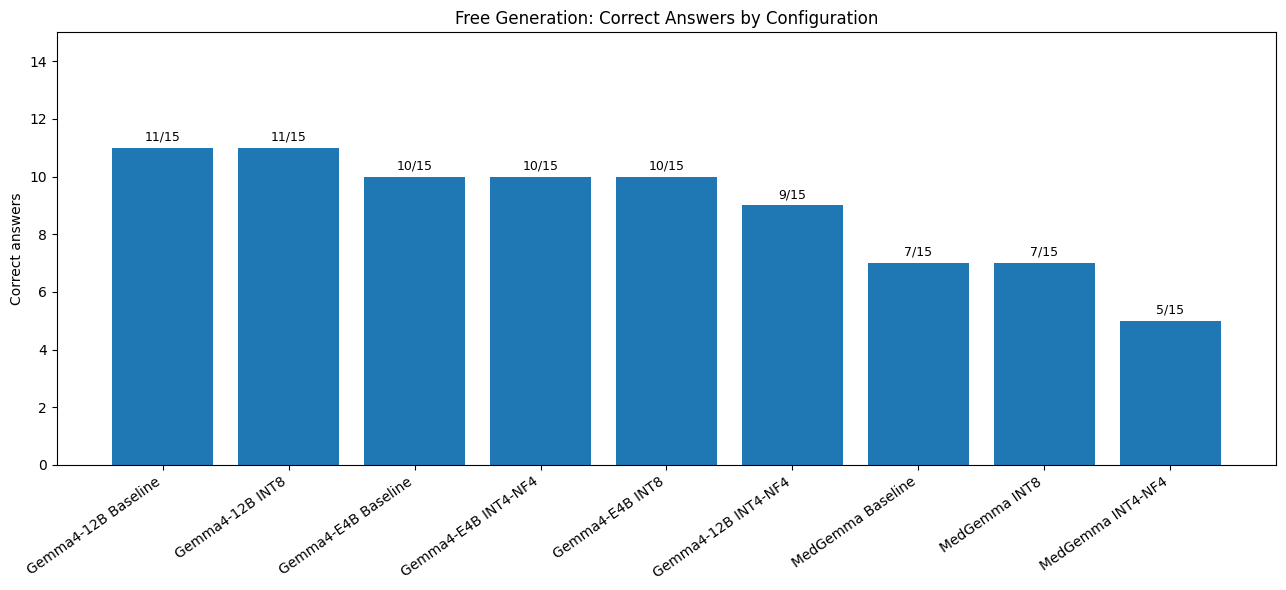

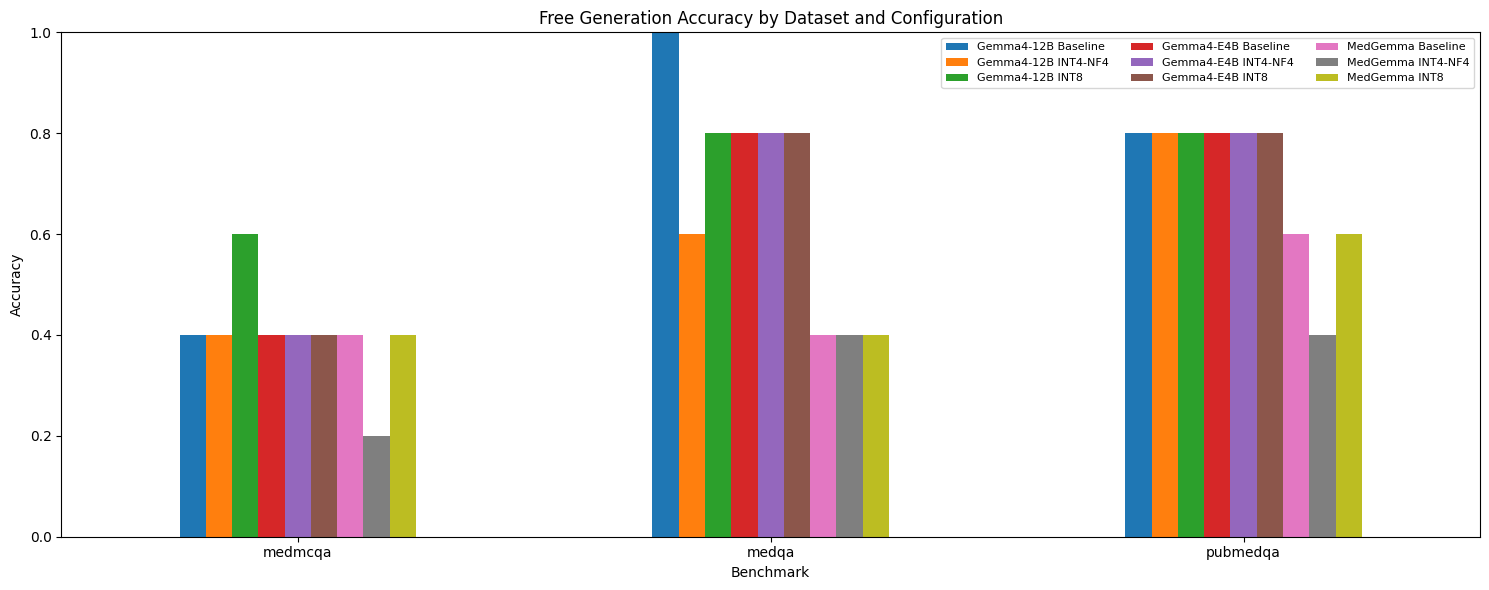

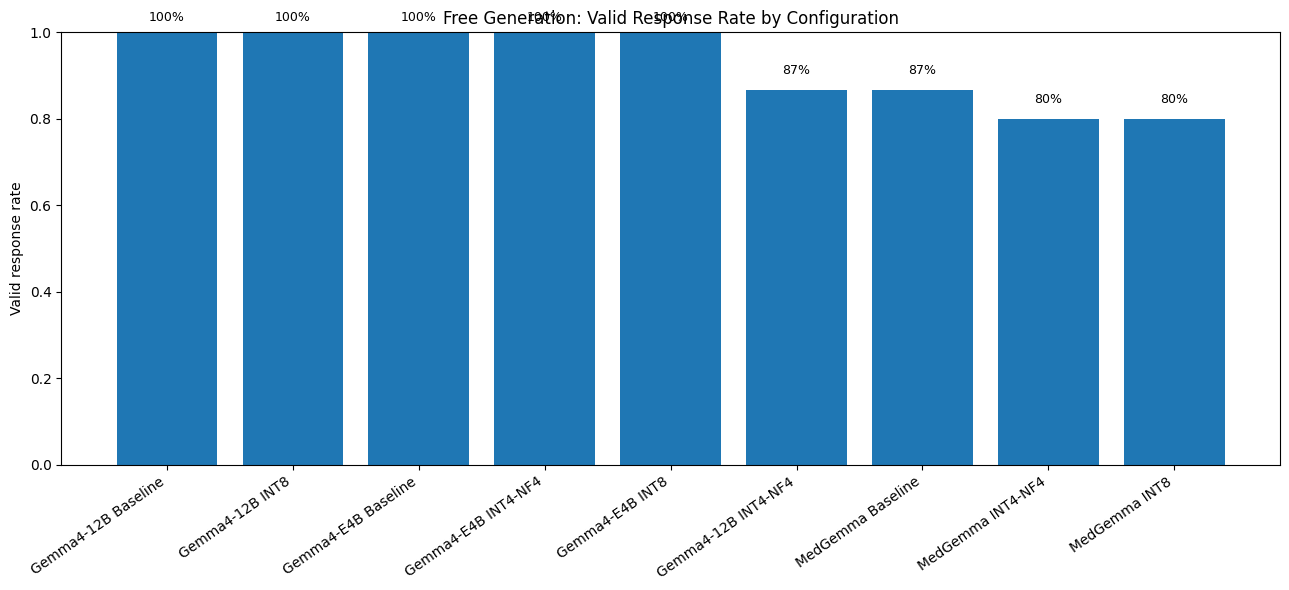

Saved free-generation overall table: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_by_config.csv
Saved free-generation dataset table: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_by_dataset.csv
Saved overall figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_by_config.png
Saved dataset figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_accuracy_by_dataset.png
Saved valid-rate figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_valid_r

In [36]:
# Free Generation Summary Tables + Figures
# Run after the benchmark cell has completed.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path(OUTPUT_DIR)
figure_dir = out_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

report_prefix = globals().get("RUN_PREFIX", globals().get("MULTI_FAMILY_PREFIX", "clean_three_model_v6"))

# Load raw predictions
raw_path = out_dir / f"{report_prefix}_raw_predictions.csv"
if not raw_path.exists():
    raise FileNotFoundError(f"Raw predictions not found: {raw_path}")

raw = pd.read_csv(raw_path)

free = raw[raw["evaluation_mode"].eq("free_generation")].copy()
if free.empty:
    raise ValueError("No free_generation rows found in raw predictions.")

# Ensure boolean columns are real bools
for col in ["is_correct", "is_valid", "hit_token_cap", "is_truncated"]:
    if col in free.columns:
        free[col] = free[col].astype(str).str.lower().isin(["true", "1", "yes"])

if "used_format_repair" in free.columns:
    free["used_format_repair"] = free["used_format_repair"].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    free["used_format_repair"] = False

# Table 1: Overall free-generation correctness across all datasets
free_overall = (
    free
    .groupby(["model_family", "precision", "model_configuration"], as_index=False)
    .agg(
        total_questions=("sample_id", "count"),
        correct_answers=("is_correct", "sum"),
        valid_answers=("is_valid", "sum"),
        invalid_answers=("is_valid", lambda s: (~s).sum()),
        hit_token_cap=("hit_token_cap", "sum"),
        used_format_repair=("used_format_repair", "sum"),
        mean_generated_tokens=("generated_tokens", "mean"),
        mean_latency_seconds=("latency_seconds", "mean"),
    )
)

free_overall["accuracy"] = free_overall["correct_answers"] / free_overall["total_questions"]
free_overall["valid_response_rate"] = free_overall["valid_answers"] / free_overall["total_questions"]
free_overall["hit_token_cap_rate"] = free_overall["hit_token_cap"] / free_overall["total_questions"]
free_overall["format_repair_rate"] = free_overall["used_format_repair"] / free_overall["total_questions"]

free_overall = free_overall.sort_values(
    ["model_family", "precision"]
).reset_index(drop=True)

# Table 2: Free-generation correctness by dataset
free_by_dataset = (
    free
    .groupby(["model_family", "precision", "model_configuration", "benchmark"], as_index=False)
    .agg(
        total_questions=("sample_id", "count"),
        correct_answers=("is_correct", "sum"),
        valid_answers=("is_valid", "sum"),
        invalid_answers=("is_valid", lambda s: (~s).sum()),
        hit_token_cap=("hit_token_cap", "sum"),
        used_format_repair=("used_format_repair", "sum"),
        mean_generated_tokens=("generated_tokens", "mean"),
        mean_latency_seconds=("latency_seconds", "mean"),
    )
)

free_by_dataset["accuracy"] = free_by_dataset["correct_answers"] / free_by_dataset["total_questions"]
free_by_dataset["valid_response_rate"] = free_by_dataset["valid_answers"] / free_by_dataset["total_questions"]
free_by_dataset["hit_token_cap_rate"] = free_by_dataset["hit_token_cap"] / free_by_dataset["total_questions"]
free_by_dataset["format_repair_rate"] = free_by_dataset["used_format_repair"] / free_by_dataset["total_questions"]

free_by_dataset = free_by_dataset.sort_values(
    ["benchmark", "model_family", "precision"]
).reset_index(drop=True)

# Save tables to Drive
overall_path = out_dir / f"{report_prefix}_free_generation_correct_by_config.csv"
dataset_path = out_dir / f"{report_prefix}_free_generation_correct_by_dataset.csv"

free_overall.to_csv(overall_path, index=False)
free_by_dataset.to_csv(dataset_path, index=False)

display(free_overall)
display(free_by_dataset)

# Figure 1: Correct answers out of total, overall by configuration
plot_overall = free_overall.copy()
plot_overall["label"] = plot_overall["model_family"] + " " + plot_overall["precision"]
plot_overall = plot_overall.sort_values("correct_answers", ascending=False)

plt.figure(figsize=(13, 6))
bars = plt.bar(plot_overall["label"], plot_overall["correct_answers"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Correct answers")
plt.title("Free Generation: Correct Answers by Configuration")

max_total = int(plot_overall["total_questions"].max())
plt.ylim(0, max_total)

for bar, correct, total in zip(
    bars,
    plot_overall["correct_answers"],
    plot_overall["total_questions"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{int(correct)}/{int(total)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
overall_fig_path = figure_dir / f"{report_prefix}_free_generation_correct_by_config.png"
plt.savefig(overall_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# Figure 2: Accuracy by dataset and configuration
plot_dataset = free_by_dataset.copy()
plot_dataset["label"] = plot_dataset["model_family"] + " " + plot_dataset["precision"]

pivot_accuracy = plot_dataset.pivot_table(
    index="benchmark",
    columns="label",
    values="accuracy",
    fill_value=0,
)

ax = pivot_accuracy.plot(kind="bar", figsize=(15, 6))
ax.set_title("Free Generation Accuracy by Dataset and Configuration")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Benchmark")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()

dataset_fig_path = figure_dir / f"{report_prefix}_free_generation_accuracy_by_dataset.png"
plt.savefig(dataset_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# Figure 3: Valid response rate by configuration
plot_valid = free_overall.copy()
plot_valid["label"] = plot_valid["model_family"] + " " + plot_valid["precision"]
plot_valid = plot_valid.sort_values("valid_response_rate", ascending=False)

plt.figure(figsize=(13, 6))
bars = plt.bar(plot_valid["label"], plot_valid["valid_response_rate"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Valid response rate")
plt.title("Free Generation: Valid Response Rate by Configuration")
plt.ylim(0, 1)

for bar, rate in zip(bars, plot_valid["valid_response_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        min(bar.get_height() + 0.03, 1.02),
        f"{rate:.0%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
valid_fig_path = figure_dir / f"{report_prefix}_free_generation_valid_rate_by_config.png"
plt.savefig(valid_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved free-generation overall table:", overall_path)
print("Saved free-generation dataset table:", dataset_path)
print("Saved overall figure:", overall_fig_path)
print("Saved dataset figure:", dataset_fig_path)
print("Saved valid-rate figure:", valid_fig_path)

,benchmark,model_family,precision,model_configuration,total_questions,correct_answers,valid_answers,invalid_answers,hit_token_cap,used_format_repair,mean_generated_tokens,mean_latency_seconds,accuracy,valid_response_rate,hit_token_cap_rate,format_repair_rate
0,medmcqa,Gemma4-12B,Baseline,Gemma4-12B Baseline,5,2,5,0,1,1,17.2,1.668596,0.4,1.0,0.2,0.2
1,medmcqa,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,5,2,5,0,3,3,53.8,8.415122,0.4,1.0,0.6,0.6
2,medmcqa,Gemma4-12B,INT8,Gemma4-12B INT8,5,3,5,0,1,1,17.2,5.638962,0.6,1.0,0.2,0.2
3,medmcqa,Gemma4-E4B,Baseline,Gemma4-E4B Baseline,5,2,5,0,0,0,5.0,0.419633,0.4,1.0,0.0,0.0
4,medmcqa,Gemma4-E4B,INT4-NF4,Gemma4-E4B INT4-NF4,5,2,5,0,0,0,5.0,0.774197,0.4,1.0,0.0,0.0
5,medmcqa,Gemma4-E4B,INT8,Gemma4-E4B INT8,5,2,5,0,0,0,5.0,1.647880,0.4,1.0,0.0,0.0
6,medmcqa,MedGemma,Baseline,MedGemma Baseline,5,2,4,1,2,1,31.6,1.906389,0.4,0.8,0.4,0.2
7,medmcqa,MedGemma,INT4-NF4,MedGemma INT4-NF4,5,1,2,3,3,0,47.4,4.826127,0.2,0.4,0.6,0.0
8,medmcqa,MedGemma,INT8,MedGemma INT8,5,2,4,1,2,1,31.0,7.022248,0.4,0.8,0.4,0.2
9,medqa,Gemma4-12B,Baseline,Gemma4-12B Baseline,5,5,5,0,2,2,30.6,2.961319,1.0,1.0,0.4,0.4


,benchmark,model_configuration,gold_answer,predicted_answer,count
0,medmcqa,Gemma4-12B Baseline,A,A,1
1,medmcqa,Gemma4-12B Baseline,A,D,1
2,medmcqa,Gemma4-12B Baseline,B,D,1
3,medmcqa,Gemma4-12B Baseline,C,C,1
4,medmcqa,Gemma4-12B Baseline,D,C,1
...,...,...,...,...,...
113,pubmedqa,MedGemma INT4-NF4,C,A,1
114,pubmedqa,MedGemma INT8,A,A,2
115,pubmedqa,MedGemma INT8,B,A,1
116,pubmedqa,MedGemma INT8,B,B,1


,benchmark,model_configuration,answer_pair,count
0,medmcqa,Gemma4-12B Baseline,A -> A,1
1,medmcqa,Gemma4-12B Baseline,A -> D,1
2,medmcqa,Gemma4-12B Baseline,B -> D,1
3,medmcqa,Gemma4-12B Baseline,C -> C,1
4,medmcqa,Gemma4-12B Baseline,D -> C,1
...,...,...,...,...
113,pubmedqa,MedGemma INT4-NF4,C -> A,1
114,pubmedqa,MedGemma INT8,A -> A,2
115,pubmedqa,MedGemma INT8,B -> A,1
116,pubmedqa,MedGemma INT8,B -> B,1


benchmark,medmcqa,medqa,pubmedqa
model_configuration,,,
Gemma4-12B Baseline,2/5,5/5,4/5
Gemma4-12B INT4-NF4,2/5,3/5,4/5
Gemma4-12B INT8,3/5,4/5,4/5
Gemma4-E4B Baseline,2/5,4/5,4/5
Gemma4-E4B INT4-NF4,2/5,4/5,4/5
Gemma4-E4B INT8,2/5,4/5,4/5
MedGemma Baseline,2/5,2/5,3/5
MedGemma INT4-NF4,1/5,2/5,2/5
MedGemma INT8,2/5,2/5,3/5


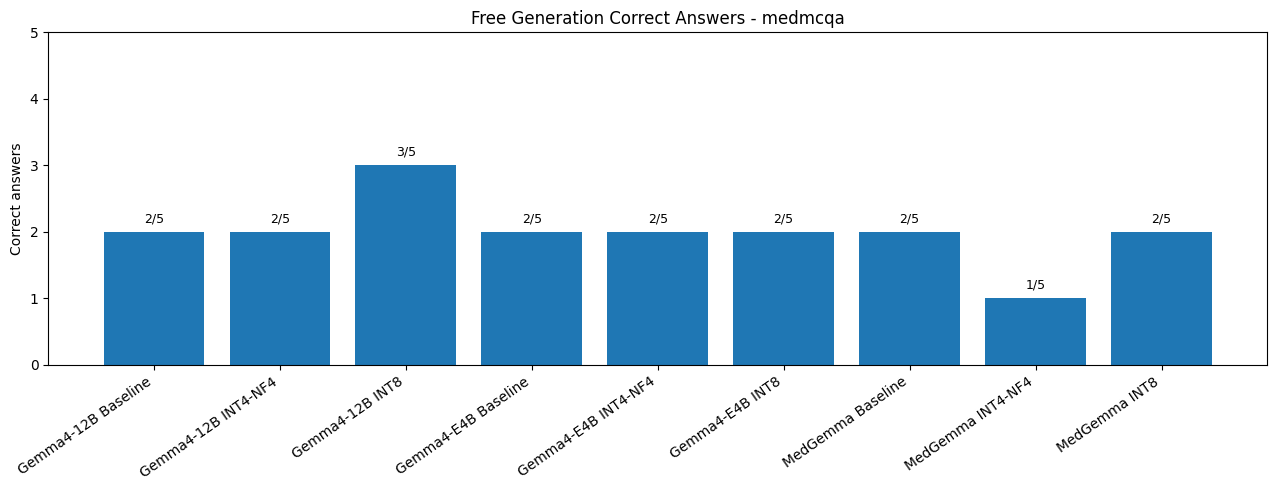

Saved figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_medmcqa.png


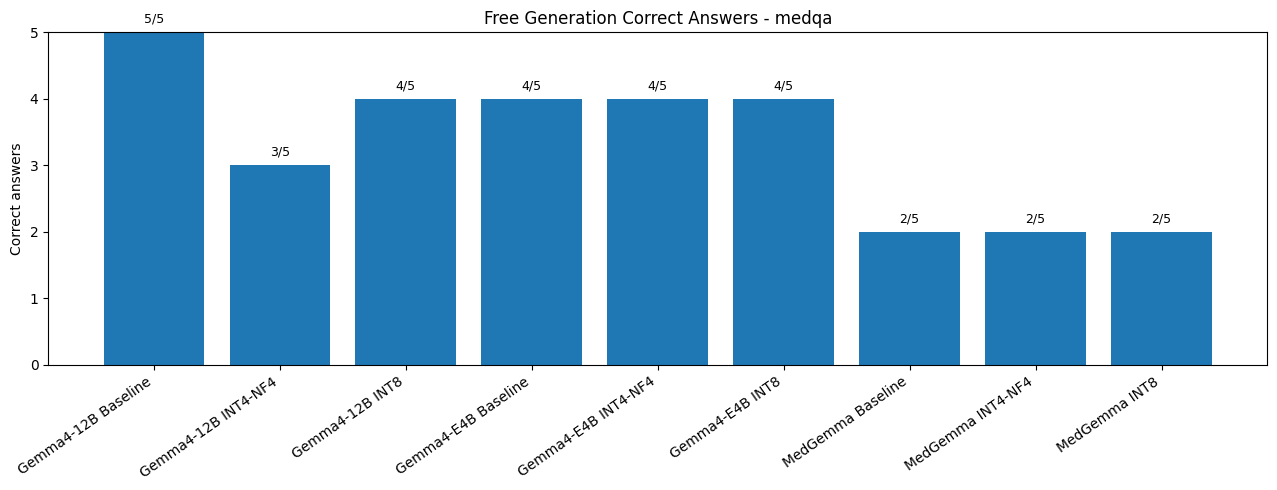

Saved figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_medqa.png


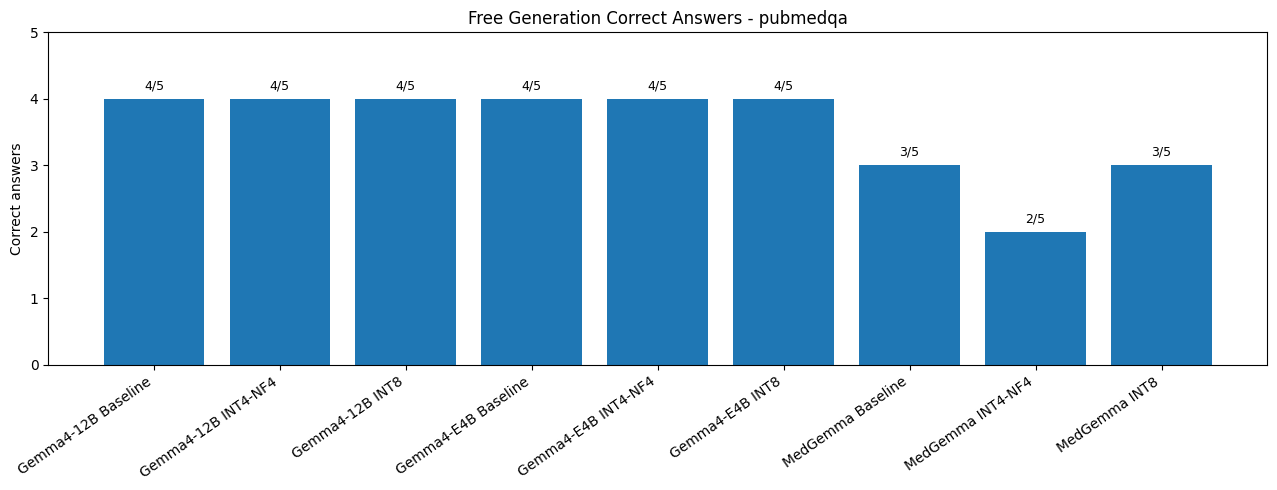

Saved figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_pubmedqa.png
Saved dataset/model summary: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_by_dataset_model_summary.csv
Saved answer distribution: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_answer_distribution.csv
Saved gold->predicted distribution: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_gold_to_predicted_distribution.csv
Saved correct/total pivot: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_free_generation_correct_over_to

In [37]:
# Free Generation: Per-Dataset Answer Breakdown
# Run after benchmark / free-generation rows exist.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path(OUTPUT_DIR)
figure_dir = out_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

report_prefix = globals().get("RUN_PREFIX", globals().get("MULTI_FAMILY_PREFIX", "clean_three_model_v6"))

raw_path = out_dir / f"{report_prefix}_raw_predictions.csv"
if not raw_path.exists():
    raise FileNotFoundError(f"Raw predictions not found: {raw_path}")

raw = pd.read_csv(raw_path)
free = raw[raw["evaluation_mode"].eq("free_generation")].copy()

if free.empty:
    raise ValueError("No free_generation rows found.")

for col in ["is_correct", "is_valid", "hit_token_cap", "is_truncated"]:
    if col in free.columns:
        free[col] = free[col].astype(str).str.lower().isin(["true", "1", "yes"])

if "used_format_repair" in free.columns:
    free["used_format_repair"] = free["used_format_repair"].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    free["used_format_repair"] = False

free["answer_pair"] = free["gold_answer"].astype(str) + " -> " + free["predicted_answer"].astype(str)

# 1. ตารางหลัก: แต่ละ dataset / config ตอบถูกกี่ข้อ
dataset_model_summary = (
    free
    .groupby(["benchmark", "model_family", "precision", "model_configuration"], as_index=False)
    .agg(
        total_questions=("sample_id", "count"),
        correct_answers=("is_correct", "sum"),
        valid_answers=("is_valid", "sum"),
        invalid_answers=("is_valid", lambda s: (~s).sum()),
        hit_token_cap=("hit_token_cap", "sum"),
        used_format_repair=("used_format_repair", "sum"),
        mean_generated_tokens=("generated_tokens", "mean"),
        mean_latency_seconds=("latency_seconds", "mean"),
    )
)

dataset_model_summary["accuracy"] = (
    dataset_model_summary["correct_answers"] / dataset_model_summary["total_questions"]
)
dataset_model_summary["valid_response_rate"] = (
    dataset_model_summary["valid_answers"] / dataset_model_summary["total_questions"]
)
dataset_model_summary["hit_token_cap_rate"] = (
    dataset_model_summary["hit_token_cap"] / dataset_model_summary["total_questions"]
)
dataset_model_summary["format_repair_rate"] = (
    dataset_model_summary["used_format_repair"] / dataset_model_summary["total_questions"]
)

dataset_model_summary = dataset_model_summary.sort_values(
    ["benchmark", "model_family", "precision"]
).reset_index(drop=True)

# 2. ตารางว่าแต่ละ config ทำนายคำตอบอะไรบ้างในแต่ละ dataset
answer_distribution = (
    free
    .groupby(
        ["benchmark", "model_configuration", "gold_answer", "predicted_answer"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "count"})
    .sort_values(["benchmark", "model_configuration", "gold_answer", "predicted_answer"])
)

# 3. Confusion-style table: gold -> predicted
answer_pair_distribution = (
    free
    .groupby(["benchmark", "model_configuration", "answer_pair"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values(["benchmark", "model_configuration", "answer_pair"])
)

# Save CSVs
summary_path = out_dir / f"{report_prefix}_free_generation_by_dataset_model_summary.csv"
answer_dist_path = out_dir / f"{report_prefix}_free_generation_answer_distribution.csv"
pair_dist_path = out_dir / f"{report_prefix}_free_generation_gold_to_predicted_distribution.csv"

dataset_model_summary.to_csv(summary_path, index=False)
answer_distribution.to_csv(answer_dist_path, index=False)
answer_pair_distribution.to_csv(pair_dist_path, index=False)

display(dataset_model_summary)
display(answer_distribution)
display(answer_pair_distribution)

# 4. Pivot table: correct/total readable table
correct_pivot = dataset_model_summary.copy()
correct_pivot["correct_over_total"] = (
    correct_pivot["correct_answers"].astype(int).astype(str)
    + "/"
    + correct_pivot["total_questions"].astype(int).astype(str)
)

correct_pivot_table = correct_pivot.pivot_table(
    index="model_configuration",
    columns="benchmark",
    values="correct_over_total",
    aggfunc="first",
)

correct_pivot_path = out_dir / f"{report_prefix}_free_generation_correct_over_total_pivot.csv"
correct_pivot_table.to_csv(correct_pivot_path)

display(correct_pivot_table)

# 5. กราฟแยก dataset: แต่ละ model/config ตอบถูกกี่ข้อ
for benchmark in sorted(dataset_model_summary["benchmark"].unique()):
    subset = dataset_model_summary[
        dataset_model_summary["benchmark"].eq(benchmark)
    ].copy()

    subset["label"] = subset["model_family"] + " " + subset["precision"]
    subset = subset.sort_values(["model_family", "precision"])

    plt.figure(figsize=(13, 5))
    bars = plt.bar(subset["label"], subset["correct_answers"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Correct answers")
    plt.title(f"Free Generation Correct Answers - {benchmark}")
    plt.ylim(0, int(subset["total_questions"].max()))

    for bar, correct, total in zip(
        bars,
        subset["correct_answers"],
        subset["total_questions"],
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{int(correct)}/{int(total)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = figure_dir / f"{report_prefix}_free_generation_correct_{benchmark}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", fig_path)

print("Saved dataset/model summary:", summary_path)
print("Saved answer distribution:", answer_dist_path)
print("Saved gold->predicted distribution:", pair_dist_path)
print("Saved correct/total pivot:", correct_pivot_path)

## 17. Figures


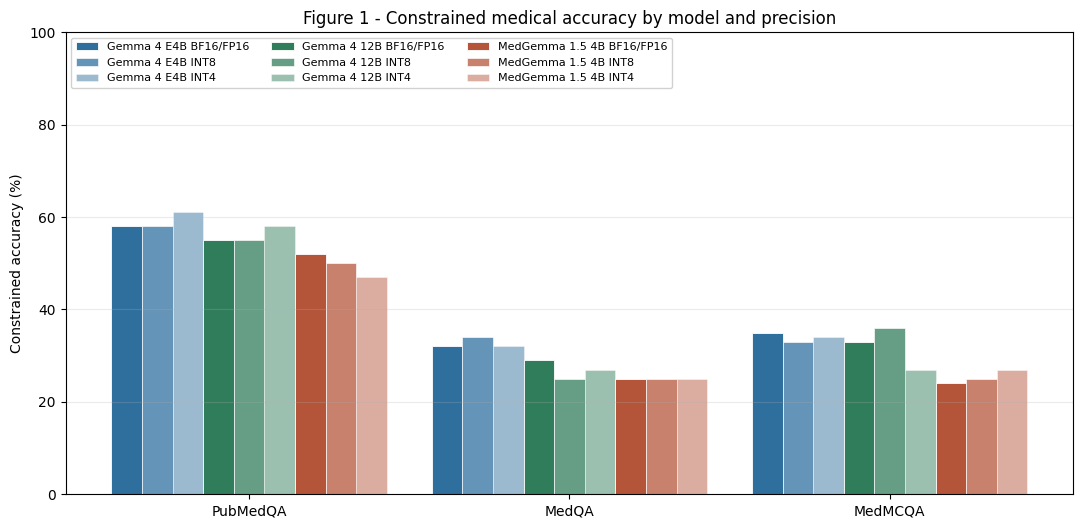

saved 01_medical_accuracy.png


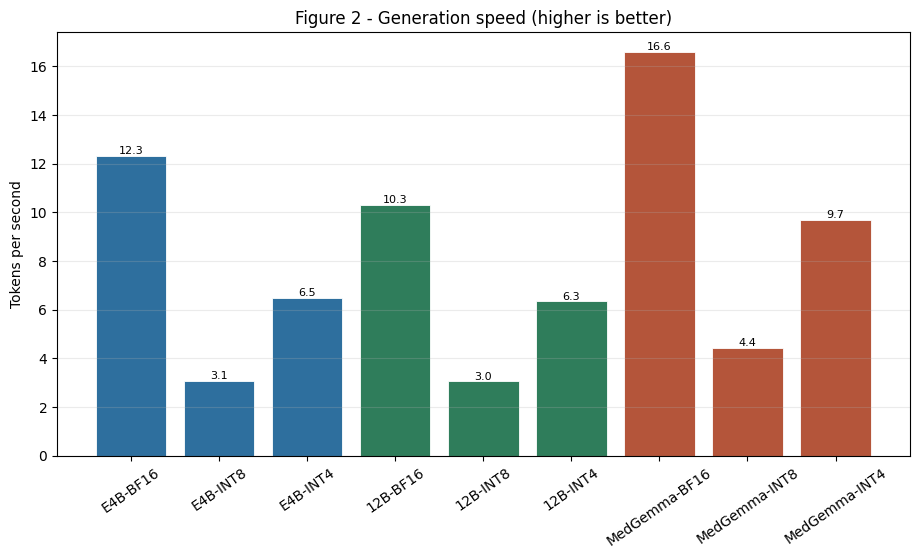

saved 02_tokens_per_second.png


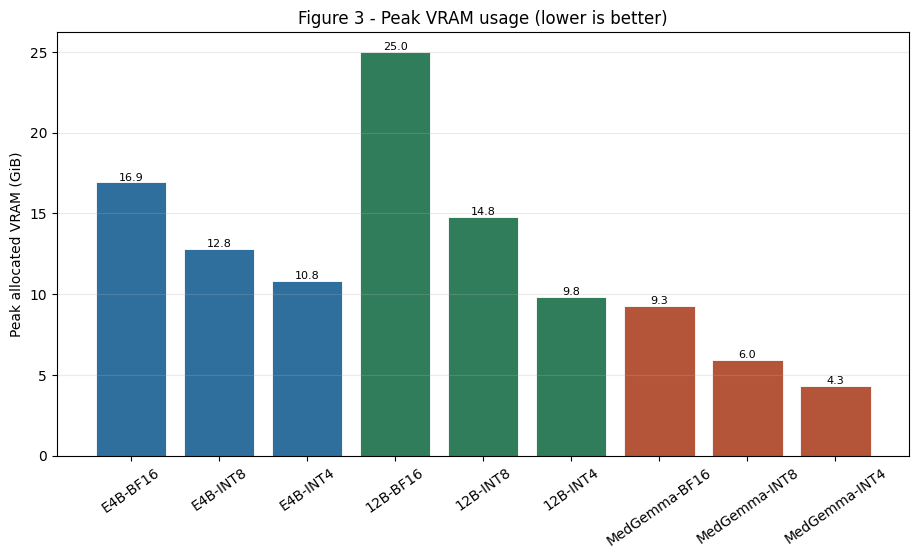

saved 03_peak_vram.png


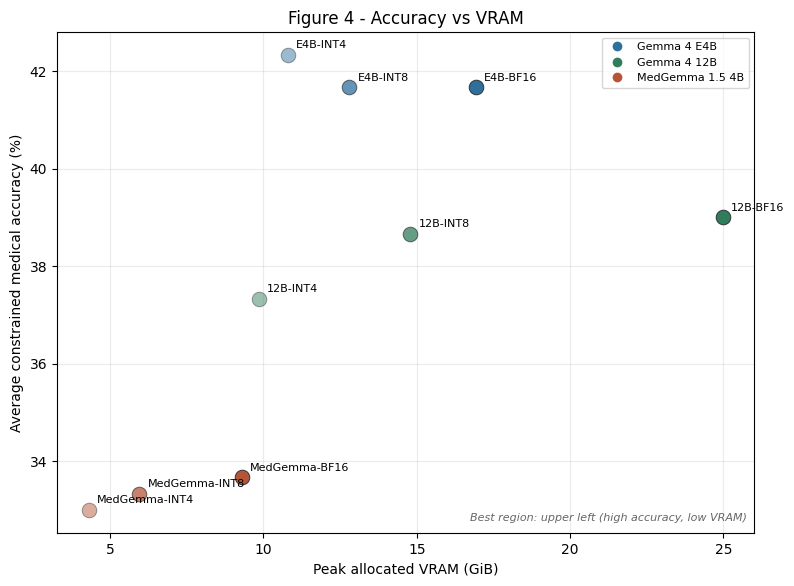

saved 04_accuracy_vs_vram.png


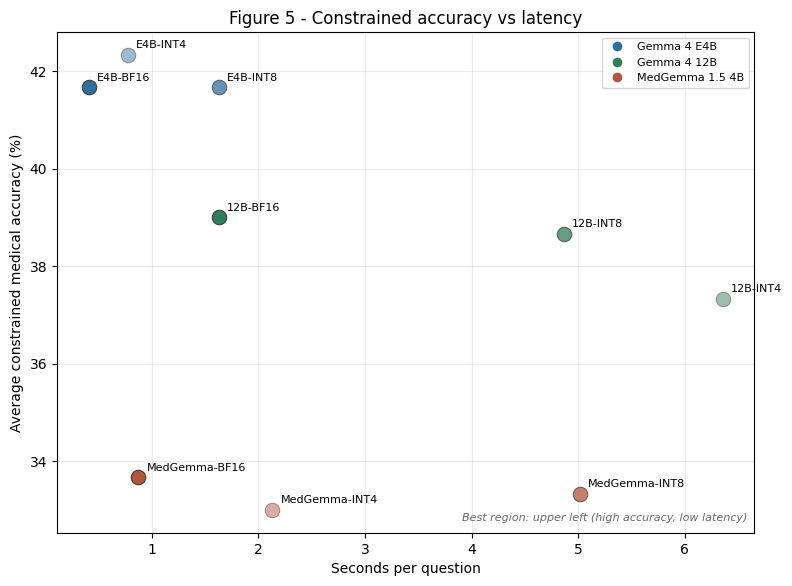

saved 05_accuracy_vs_latency.png


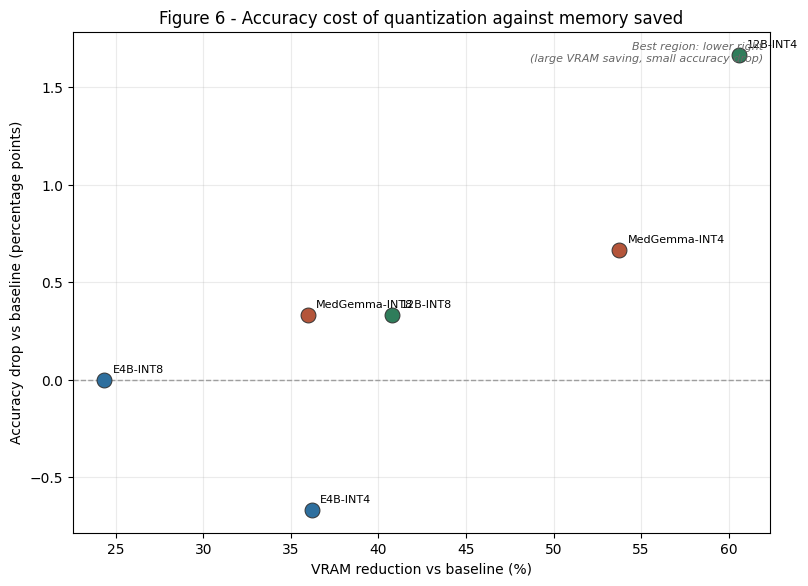

saved 06_accuracy_drop_vs_vram_reduction.png

6 figures written to /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures


In [26]:
FAMILY_COLORS = {"Gemma4-E4B": "#2E6F9E", "Gemma4-12B": "#2F7D5B", "MedGemma": "#B4553A"}
PRECISION_ALPHA = {"Baseline": 1.0, "INT8": 0.74, "INT4-NF4": 0.48}
FALLBACK_COLORS = ["#6C5B8B", "#8A7A2E", "#3F6F72", "#94456B"]

def family_color(family):
    if family in FAMILY_COLORS:
        return FAMILY_COLORS[family]
    return FALLBACK_COLORS[REPORT_FAMILIES.index(family) % len(FALLBACK_COLORS)]

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("saved", path.name)
    return path

def annotate_points(ax, points):
    for x, y, label in points:
        ax.annotate(label, (x, y), xytext=(6, 5), textcoords="offset points", fontsize=8)

def note_missing(ax, count):
    if count:
        ax.text(0.99, 0.02, f"{count} configuration(s) unavailable (N/A)", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=8, style="italic", color="#666666")

saved_figures = []

# --- Figure 1: grouped constrained accuracy by benchmark -------------------------------
plotted = [(f, p) for f, p in REPORT_CONFIGS if pd.notna(average_accuracy(f, p))]
if plotted:
    fig, ax = plt.subplots(figsize=(13, 6))
    positions = np.arange(len(REPORT_BENCHMARKS))
    width = 0.86 / len(plotted)
    for i, (family, precision) in enumerate(plotted):
        scores = ACCURACY_BY_CONFIG.get((family, precision), {})
        values = [scores.get(b, np.nan) * 100 if pd.notna(scores.get(b, np.nan)) else np.nan
                  for b in REPORT_BENCHMARKS]
        ax.bar(positions + i * width - 0.43 + width / 2, values, width,
               label=f"{family_label(family)} {precision_label(precision)}",
               color=family_color(family), alpha=PRECISION_ALPHA.get(precision, 1.0),
               edgecolor="white", linewidth=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([BENCHMARK_LABELS.get(b, b) for b in REPORT_BENCHMARKS])
    ax.set_ylabel("Constrained accuracy (%)")
    ax.set_title("Figure 1 - Constrained medical accuracy by model and precision")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=3, fontsize=8, loc="upper left", framealpha=0.9)
    note_missing(ax, len(REPORT_CONFIGS) - len(plotted))
    saved_figures.append(save_figure(fig, "01_medical_accuracy.png"))

# --- Figure 2: tokens per second -------------------------------------------
speed_points = [(f, p, metric(PERFORMANCE_INDEX, "tokens_per_second", f, p)) for f, p in REPORT_CONFIGS]
speed_points = [(f, p, v) for f, p, v in speed_points if pd.notna(v)]
if speed_points:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    labels = [short_config_label(f, p) for f, p, _ in speed_points]
    ax.bar(labels, [v for _, _, v in speed_points],
           color=[family_color(f) for f, _, _ in speed_points],
           alpha=1.0, edgecolor="white", linewidth=0.6)
    for i, (_, _, value) in enumerate(speed_points):
        ax.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Tokens per second")
    ax.set_title("Figure 2 - Generation speed (higher is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
    note_missing(ax, len(REPORT_CONFIGS) - len(speed_points))
    saved_figures.append(save_figure(fig, "02_tokens_per_second.png"))

# --- Figure 3: peak VRAM ----------------------------------------------------
vram_points = [(f, p, metric(MEMORY_INDEX, "peak_allocated_vram_gib", f, p)) for f, p in REPORT_CONFIGS]
vram_points = [(f, p, v) for f, p, v in vram_points if pd.notna(v)]
if vram_points:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    labels = [short_config_label(f, p) for f, p, _ in vram_points]
    ax.bar(labels, [v for _, _, v in vram_points],
           color=[family_color(f) for f, _, _ in vram_points],
           alpha=1.0, edgecolor="white", linewidth=0.6)
    for i, (_, _, value) in enumerate(vram_points):
        ax.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Peak allocated VRAM (GiB)")
    ax.set_title("Figure 3 - Peak VRAM usage (lower is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
    note_missing(ax, len(REPORT_CONFIGS) - len(vram_points))
    saved_figures.append(save_figure(fig, "03_peak_vram.png"))

# --- Figures 4 and 5: accuracy against cost --------------------------------
def scatter_against_accuracy(x_column, index_frame, xlabel, title, filename, invert_hint):
    points = []
    for family, precision in REPORT_CONFIGS:
        x = metric(index_frame, x_column, family, precision)
        y = average_accuracy(family, precision)
        if pd.notna(x) and pd.notna(y):
            points.append((family, precision, x, y * 100))
    if not points:
        return None
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for family, precision, x, y in points:
        ax.scatter(x, y, s=110, color=family_color(family),
                   alpha=PRECISION_ALPHA.get(precision, 1.0),
                   edgecolor="#333333", linewidth=0.7, zorder=3)
    annotate_points(ax, [(x, y, short_config_label(f, p)) for f, p, x, y in points])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average constrained medical accuracy (%)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.text(0.99, 0.02, invert_hint, transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, style="italic", color="#666666")
    handles = [plt.Line2D([], [], marker="o", linestyle="", color=family_color(f),
                          label=family_label(f)) for f in REPORT_FAMILIES]
    ax.legend(handles=handles, fontsize=8, loc="best")
    return save_figure(fig, filename)

figure4 = scatter_against_accuracy(
    "peak_allocated_vram_gib", MEMORY_INDEX, "Peak allocated VRAM (GiB)",
    "Figure 4 - Accuracy vs VRAM", "04_accuracy_vs_vram.png",
    "Best region: upper left (high accuracy, low VRAM)")
figure5 = scatter_against_accuracy(
    "mean_latency_seconds", PERFORMANCE_INDEX, "Seconds per question",
    "Figure 5 - Constrained accuracy vs latency", "05_accuracy_vs_latency.png",
    "Best region: upper left (high accuracy, low latency)")
saved_figures += [f for f in (figure4, figure5) if f]

# --- Figure 6: accuracy drop against VRAM reduction ------------------------
tradeoff_points = []
for _, row in table4_tradeoff.iterrows():
    if pd.notna(row["Accuracy Drop"]) and pd.notna(row["VRAM Reduction %"]):
        tradeoff_points.append((row["Model"], row["Quantization"],
                                float(row["VRAM Reduction %"]), float(row["Accuracy Drop"]) * 100))
if tradeoff_points:
    inverse_labels = {family_label(f): f for f in REPORT_FAMILIES}
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for model, quant, x, y in tradeoff_points:
        ax.scatter(x, y, s=115, color=family_color(inverse_labels.get(model, model)),
                   edgecolor="#333333", linewidth=0.7, zorder=3)
    annotate_points(ax, [
        (x, y, f"{family_label(inverse_labels.get(m, m), True)}-{q}")
        for m, q, x, y in tradeoff_points])
    ax.axhline(0, color="#999999", linewidth=1, linestyle="--", zorder=1)
    ax.set_xlabel("VRAM reduction vs baseline (%)")
    ax.set_ylabel("Accuracy drop vs baseline (percentage points)")
    ax.set_title("Figure 6 - Accuracy cost of quantization against memory saved")
    ax.grid(alpha=0.25)
    ax.text(0.99, 0.98, "Best region: lower right\n(large VRAM saving, small accuracy drop)",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            style="italic", color="#666666")
    saved_figures.append(save_figure(fig, "06_accuracy_drop_vs_vram_reduction.png"))

print(f"\n{len(saved_figures)} figures written to {FIGURE_DIR}")

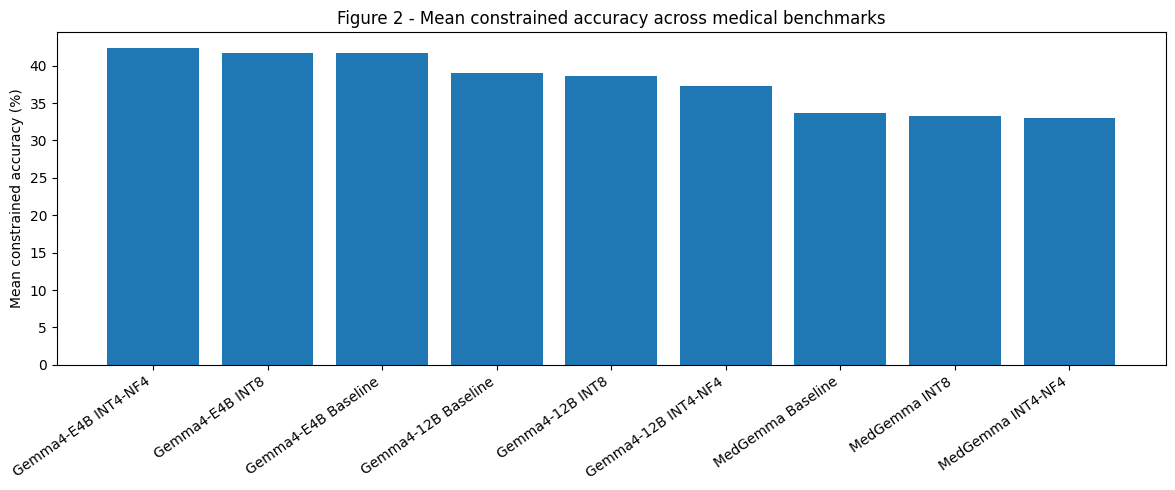

saved 02_mean_constrained_accuracy.png


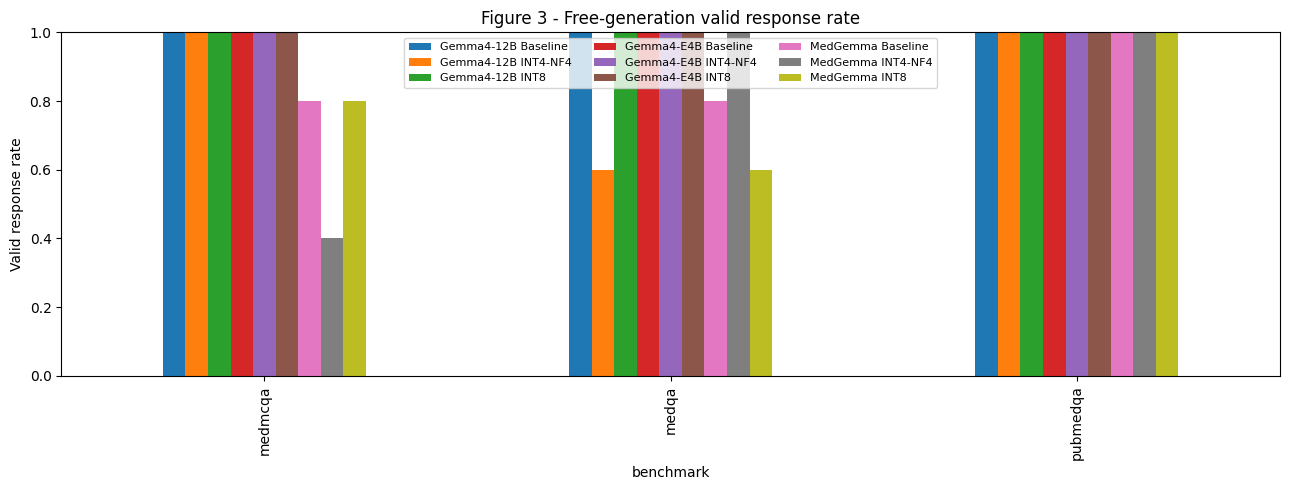

saved 03_free_generation_valid_rate.png


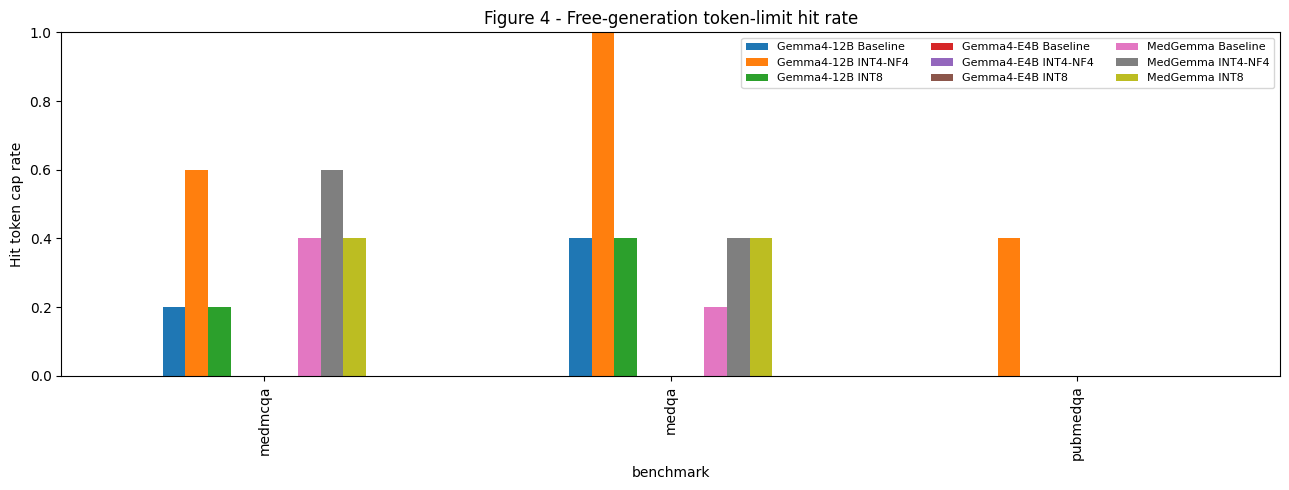

saved 04_free_generation_hit_token_cap_rate.png


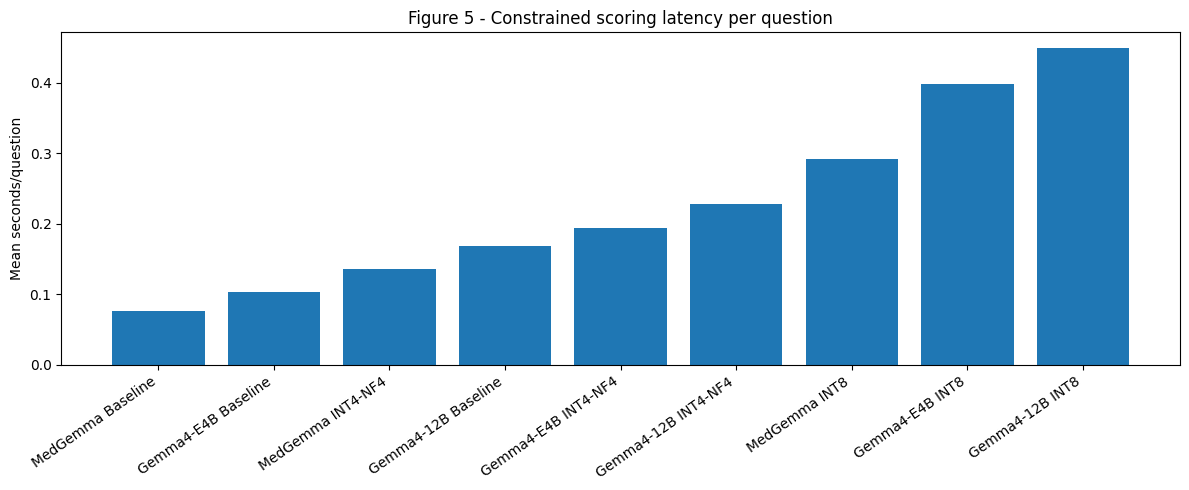

saved 05_seconds_per_question.png


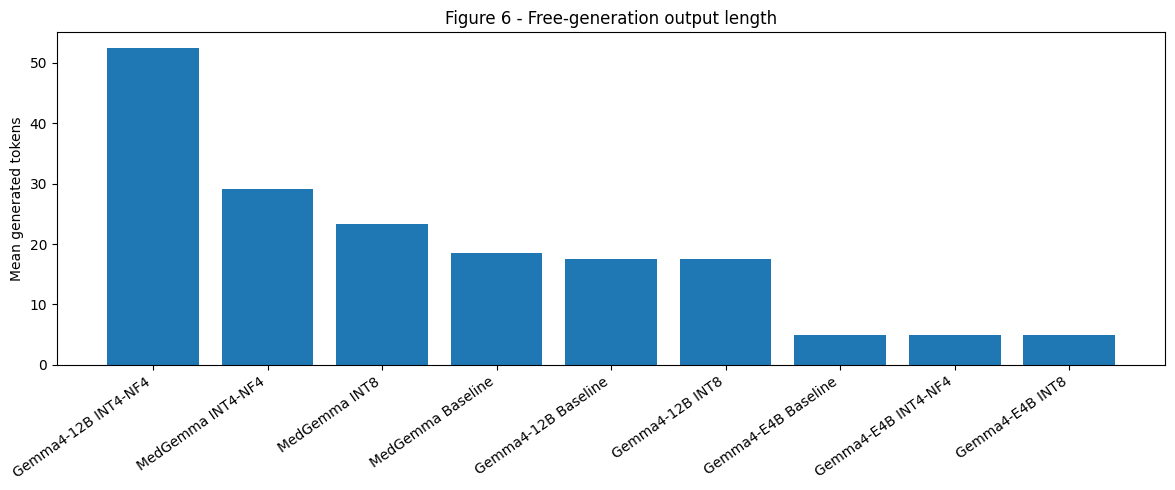

saved 06_free_generation_tokens.png


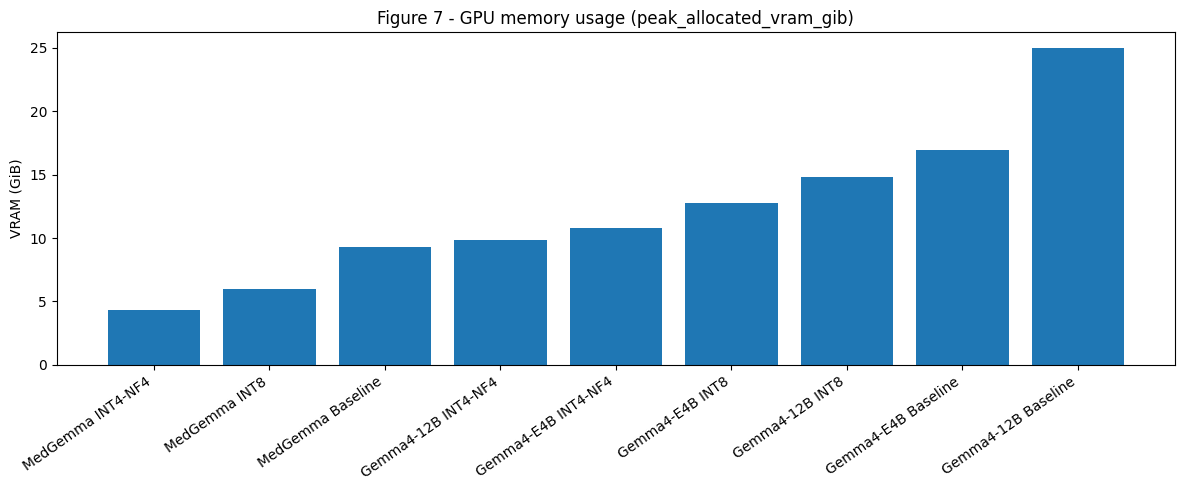

saved 07_peak_vram.png


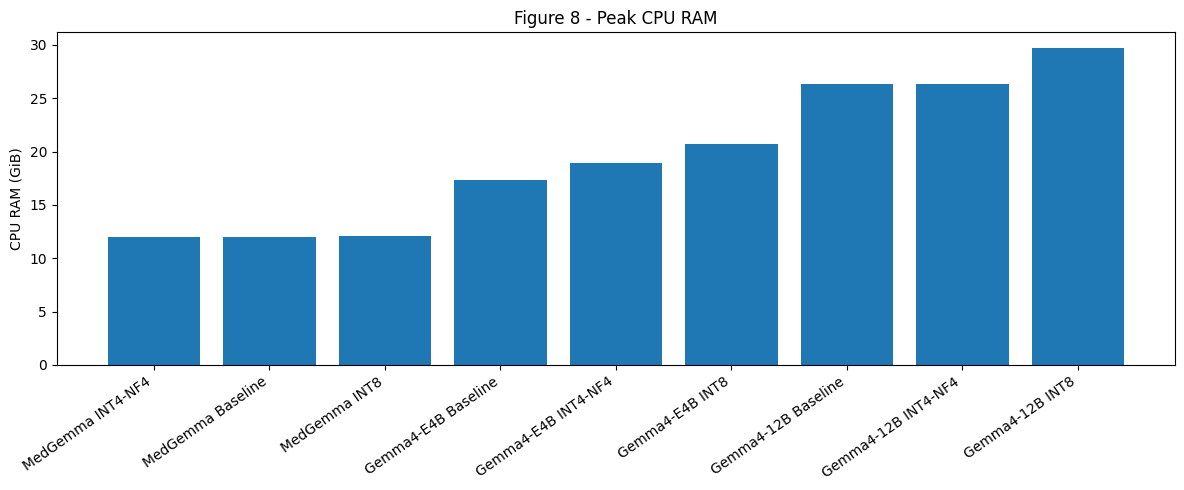

saved 08_peak_cpu_ram.png


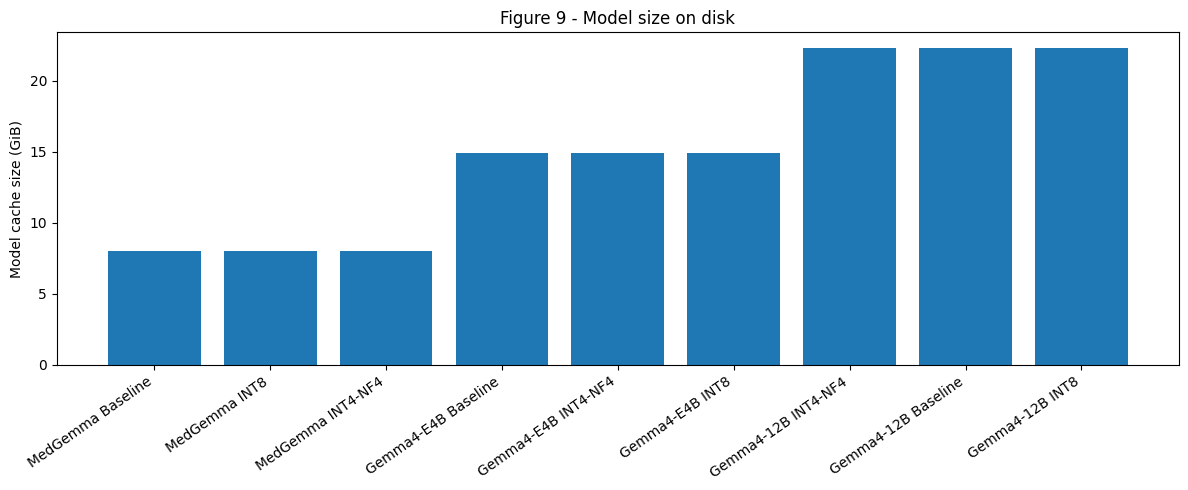

saved 09_model_size.png


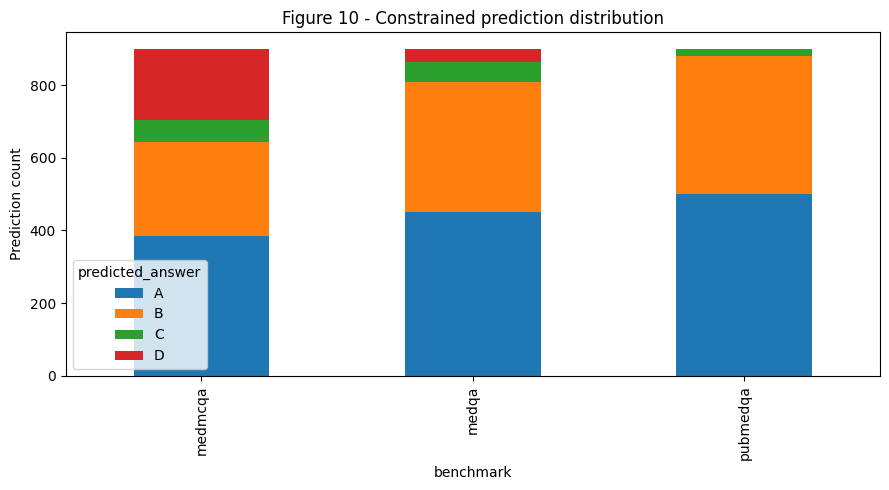

saved 10_prediction_distribution.png
Extra figures saved to: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

FIGURE_DIR = Path(FIGURE_DIR)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def _save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved", filename)
    return path

# โหลด summary หลัก
report_prefix = globals().get("RUN_PREFIX", globals().get("MULTI_FAMILY_PREFIX", "clean_three_model_v6"))

summary_path = Path(OUTPUT_DIR) / f"{report_prefix}_benchmark_summary_all_modes.csv"
performance_path = Path(OUTPUT_DIR) / f"{report_prefix}_performance_summary.csv"
memory_path = Path(OUTPUT_DIR) / f"{report_prefix}_memory_summary.csv"
raw_path = Path(OUTPUT_DIR) / f"{report_prefix}_raw_predictions.csv"

summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
performance = pd.read_csv(performance_path) if performance_path.exists() else pd.DataFrame()
memory = pd.read_csv(memory_path) if memory_path.exists() else pd.DataFrame()
raw = pd.read_csv(raw_path) if raw_path.exists() else pd.DataFrame()

# 02 - Mean constrained accuracy by configuration
if not summary.empty:
    constrained = summary[summary["evaluation_mode"].eq("constrained")].copy()
    if not constrained.empty:
        mean_acc = (
            constrained.groupby("model_configuration", as_index=False)["accuracy"]
            .mean()
            .sort_values("accuracy", ascending=False)
        )

        plt.figure(figsize=(12, 5))
        plt.bar(mean_acc["model_configuration"], mean_acc["accuracy"] * 100)
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Mean constrained accuracy (%)")
        plt.title("Figure 2 - Mean constrained accuracy across medical benchmarks")
        _save_current_figure("02_mean_constrained_accuracy.png")

# 03 - Free-generation valid response rate
if not summary.empty:
    free = summary[summary["evaluation_mode"].eq("free_generation")].copy()
    if not free.empty and "valid_response_rate" in free.columns:
        pivot = free.pivot_table(
            index="benchmark",
            columns="model_configuration",
            values="valid_response_rate",
            aggfunc="mean",
        )

        plt.figure(figsize=(13, 5))
        pivot.plot(kind="bar", ax=plt.gca())
        plt.ylabel("Valid response rate")
        plt.ylim(0, 1)
        plt.title("Figure 3 - Free-generation valid response rate")
        plt.legend(fontsize=8, ncol=3)
        _save_current_figure("03_free_generation_valid_rate.png")

# 04 - Free-generation truncation / token cap rate
if not summary.empty:
    free = summary[summary["evaluation_mode"].eq("free_generation")].copy()
    if not free.empty and "hit_token_cap_rate" in free.columns:
        pivot = free.pivot_table(
            index="benchmark",
            columns="model_configuration",
            values="hit_token_cap_rate",
            aggfunc="mean",
        )

        plt.figure(figsize=(13, 5))
        pivot.plot(kind="bar", ax=plt.gca())
        plt.ylabel("Hit token cap rate")
        plt.ylim(0, 1)
        plt.title("Figure 4 - Free-generation token-limit hit rate")
        plt.legend(fontsize=8, ncol=3)
        _save_current_figure("04_free_generation_hit_token_cap_rate.png")

# 05 - Seconds per question
if not summary.empty and "mean_seconds_per_question" in summary.columns:
    constrained = summary[summary["evaluation_mode"].eq("constrained")].copy()
    if not constrained.empty:
        speed = (
            constrained.groupby("model_configuration", as_index=False)["mean_seconds_per_question"]
            .mean()
            .sort_values("mean_seconds_per_question")
        )

        plt.figure(figsize=(12, 5))
        plt.bar(speed["model_configuration"], speed["mean_seconds_per_question"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Mean seconds/question")
        plt.title("Figure 5 - Constrained scoring latency per question")
        _save_current_figure("05_seconds_per_question.png")

# 06 - Generated token count
if not summary.empty and "mean_generated_tokens" in summary.columns:
    free = summary[summary["evaluation_mode"].eq("free_generation")].copy()
    if not free.empty:
        gen_tokens = (
            free.groupby("model_configuration", as_index=False)["mean_generated_tokens"]
            .mean()
            .sort_values("mean_generated_tokens", ascending=False)
        )

        plt.figure(figsize=(12, 5))
        plt.bar(gen_tokens["model_configuration"], gen_tokens["mean_generated_tokens"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Mean generated tokens")
        plt.title("Figure 6 - Free-generation output length")
        _save_current_figure("06_free_generation_tokens.png")

# 07 - Peak VRAM
if not memory.empty:
    vram_col = None
    for candidate in ["peak_allocated_vram_gib", "peak_reserved_vram_gib", "gpu_allocated_after_load_gib"]:
        if candidate in memory.columns:
            vram_col = candidate
            break

    if vram_col:
        vram = memory[["model_configuration", vram_col]].dropna().copy()
        if not vram.empty:
            vram = vram.sort_values(vram_col)

            plt.figure(figsize=(12, 5))
            plt.bar(vram["model_configuration"], vram[vram_col])
            plt.xticks(rotation=35, ha="right")
            plt.ylabel("VRAM (GiB)")
            plt.title(f"Figure 7 - GPU memory usage ({vram_col})")
            _save_current_figure("07_peak_vram.png")

# 08 - CPU RAM
if not memory.empty and "peak_cpu_ram_gib" in memory.columns:
    ram = memory[["model_configuration", "peak_cpu_ram_gib"]].dropna().copy()
    if not ram.empty:
        ram = ram.sort_values("peak_cpu_ram_gib")

        plt.figure(figsize=(12, 5))
        plt.bar(ram["model_configuration"], ram["peak_cpu_ram_gib"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("CPU RAM (GiB)")
        plt.title("Figure 8 - Peak CPU RAM")
        _save_current_figure("08_peak_cpu_ram.png")

# 09 - Model cache size
if not memory.empty and "model_cache_size_gib" in memory.columns:
    size = memory[["model_configuration", "model_cache_size_gib"]].dropna().copy()
    if not size.empty:
        size = size.sort_values("model_cache_size_gib")

        plt.figure(figsize=(12, 5))
        plt.bar(size["model_configuration"], size["model_cache_size_gib"])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Model cache size (GiB)")
        plt.title("Figure 9 - Model size on disk")
        _save_current_figure("09_model_size.png")

# 10 - Prediction distribution per dataset
if not raw.empty:
    constrained_raw = raw[raw["evaluation_mode"].eq("constrained")].copy()
    if not constrained_raw.empty:
        pred_counts = (
            constrained_raw
            .groupby(["benchmark", "predicted_answer"])
            .size()
            .reset_index(name="count")
        )
        pivot = pred_counts.pivot_table(
            index="benchmark",
            columns="predicted_answer",
            values="count",
            fill_value=0,
        )

        plt.figure(figsize=(9, 5))
        pivot.plot(kind="bar", stacked=True, ax=plt.gca())
        plt.ylabel("Prediction count")
        plt.title("Figure 10 - Constrained prediction distribution")
        _save_current_figure("10_prediction_distribution.png")

print("Extra figures saved to:", FIGURE_DIR)

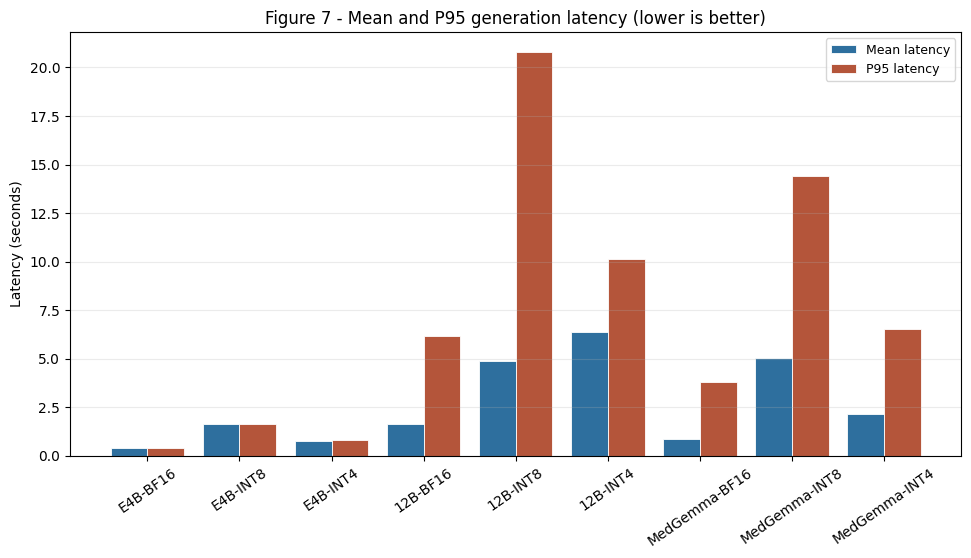

saved 07_latency_comparison.png


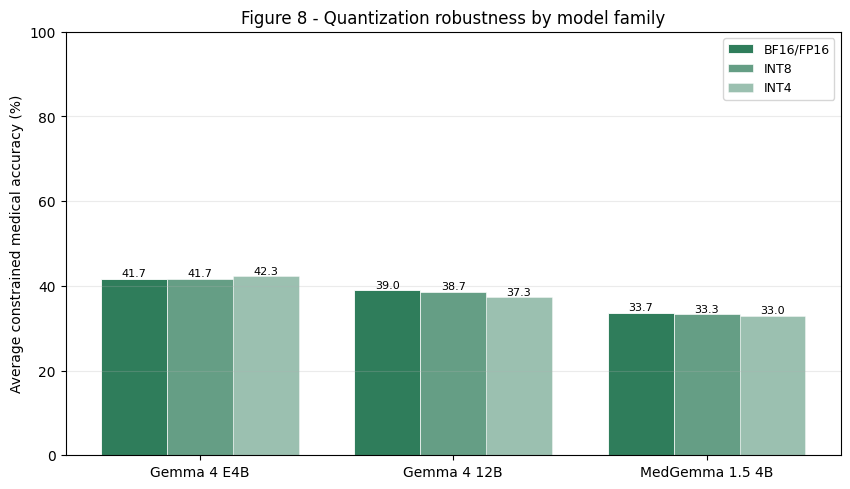

saved 08_quantization_robustness.png

Total figures in /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures: 17


In [28]:
# --- Figure 7: latency comparison ------------------------------------------
latency_points = []
for family, precision in REPORT_CONFIGS:
    mean_latency = metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, precision)
    p95_latency = metric(PERFORMANCE_INDEX, "p95_latency_seconds", family, precision)
    if pd.notna(mean_latency) or pd.notna(p95_latency):
        latency_points.append((family, precision, mean_latency, p95_latency))

if latency_points:
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    positions = np.arange(len(latency_points))
    ax.bar(positions - 0.2, [m for _, _, m, _ in latency_points], 0.4,
           label="Mean latency", color="#2E6F9E", edgecolor="white", linewidth=0.6)
    ax.bar(positions + 0.2, [p for _, _, _, p in latency_points], 0.4,
           label="P95 latency", color="#B4553A", edgecolor="white", linewidth=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([short_config_label(f, p) for f, p, _, _ in latency_points], rotation=35)
    ax.set_ylabel("Latency (seconds)")
    ax.set_title("Figure 7 - Mean and P95 generation latency (lower is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)
    note_missing(ax, len(REPORT_CONFIGS) - len(latency_points))
    saved_figures.append(save_figure(fig, "07_latency_comparison.png"))
else:
    print("Figure 7 skipped: no latency measurements available.")

# --- Figure 8: quantization robustness by family ---------------------------
robust_families = [f for f in REPORT_FAMILIES
                   if any(pd.notna(average_accuracy(f, p)) for p in PRECISION_ORDER)]
if robust_families:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    positions = np.arange(len(robust_families))
    width = 0.26
    for i, precision in enumerate(PRECISION_ORDER):
        values = [average_accuracy(f, precision) * 100
                  if pd.notna(average_accuracy(f, precision)) else np.nan
                  for f in robust_families]
        ax.bar(positions + (i - 1) * width, values, width,
               label=precision_label(precision), color="#2F7D5B",
               alpha=PRECISION_ALPHA.get(precision, 1.0), edgecolor="white", linewidth=0.6)
        for x, value in zip(positions + (i - 1) * width, values):
            if pd.notna(value):
                ax.text(x, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(positions)
    ax.set_xticklabels([family_label(f) for f in robust_families])
    ax.set_ylabel("Average constrained medical accuracy (%)")
    ax.set_title("Figure 8 - Quantization robustness by model family")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)
    saved_figures.append(save_figure(fig, "08_quantization_robustness.png"))
else:
    print("Figure 8 skipped: no accuracy results available.")

print(f"\nTotal figures in {FIGURE_DIR}: {len(sorted(FIGURE_DIR.glob('*.png')))}")

## 18. Final Evidence-Only Analysis


In [29]:
def best_by(values, largest=True):
    '''Return (label, value) of the best available measurement, or None when none exist.'''
    usable = [(label, value) for label, value in values if pd.notna(value)]
    if not usable:
        return None
    return max(usable, key=lambda kv: kv[1]) if largest else min(usable, key=lambda kv: kv[1])

analysis = ["## Final analysis", "", "Accuracy below means constrained accuracy (the primary knowledge metric).", "",
            "Every statement below is derived from completed measurements only. "
            "Questions without sufficient data are reported as unanswerable rather than estimated.", ""]

accuracy_values = [(short_config_label(f, p), average_accuracy(f, p)) for f, p in REPORT_CONFIGS]
latency_values = [(short_config_label(f, p), metric(PERFORMANCE_INDEX, "mean_latency_seconds", f, p))
                  for f, p in REPORT_CONFIGS]
vram_values = [(short_config_label(f, p), metric(MEMORY_INDEX, "peak_allocated_vram_gib", f, p))
               for f, p in REPORT_CONFIGS]

# 1-3 -----------------------------------------------------------------------
top_accuracy = best_by(accuracy_values, largest=True)
analysis.append("**1. Highest average medical accuracy**")
analysis.append(f"{top_accuracy[0]} at {top_accuracy[1] * 100:.2f}%." if top_accuracy
                else "No configuration produced accuracy results.")

top_speed = best_by(latency_values, largest=False)
analysis += ["", "**2. Fastest configuration**"]
analysis.append(f"{top_speed[0]} at {top_speed[1]:.2f} seconds/question." if top_speed
                else "No configuration produced speed measurements.")

low_vram = best_by(vram_values, largest=False)
analysis += ["", "**3. Lowest VRAM**"]
analysis.append(f"{low_vram[0]} at {low_vram[1]:.2f} GiB peak allocated." if low_vram
                else "No configuration produced memory measurements.")

# 4-5 -----------------------------------------------------------------------
def best_preserving(precision):
    rows = table4_tradeoff[table4_tradeoff["Quantization"] == precision_label(precision)]
    rows = rows.dropna(subset=["Accuracy Drop"])
    if rows.empty:
        return None
    best = rows.loc[rows["Accuracy Drop"].idxmin()]
    return best["Model"], float(best["Accuracy Drop"])

for number, precision in ((4, "INT8"), (5, "INT4-NF4")):
    result = best_preserving(precision)
    analysis += ["", f"**{number}. {precision_label(precision)} configuration that preserved accuracy best**"]
    if result:
        name, drop = result
        direction = "lost" if drop >= 0 else "gained"
        analysis.append(f"{name}: {direction} {abs(drop) * 100:.2f} percentage points versus its own baseline.")
    else:
        analysis.append(f"No family completed both a baseline and an {precision_label(precision)} run.")

# 6-7 -----------------------------------------------------------------------
def normalize(series):
    '''Min-max scale to [0, 1]; a flat series scores 1 everywhere.'''
    spread = series.max() - series.min()
    return (series - series.min()) / spread if spread else pd.Series(1.0, index=series.index)

def best_balanced(cost_values, lower_cost_is_better):
    '''Rank equally on normalized accuracy and normalized cost, as Section 19 does.'''
    rows = [{"name": name, "accuracy": accuracy, "cost": cost}
            for (name, accuracy), (_, cost) in zip(accuracy_values, cost_values)
            if pd.notna(accuracy) and pd.notna(cost)]
    if not rows:
        return None
    frame = pd.DataFrame(rows)
    cost_score = 1 - normalize(frame["cost"]) if lower_cost_is_better else normalize(frame["cost"])
    frame["score"] = (normalize(frame["accuracy"]) + cost_score) / 2
    best = frame.loc[frame["score"].idxmax()]
    return best["name"], float(best["accuracy"]), float(best["cost"])

vram_balance = best_balanced(vram_values, lower_cost_is_better=True)
analysis += ["", "**6. Best accuracy-to-VRAM trade-off**"]
analysis.append(
    f"{vram_balance[0]}: {vram_balance[1] * 100:.2f}% accuracy at {vram_balance[2]:.2f} GiB peak VRAM. "
    "Ranked with equal weight on normalized accuracy and normalized memory saving."
    if vram_balance else "Needs both accuracy and VRAM measurements; not available.")

speed_balance = best_balanced(latency_values, lower_cost_is_better=True)
analysis += ["", "**7. Best accuracy-to-speed trade-off**"]
analysis.append(
    f"{speed_balance[0]}: {speed_balance[1] * 100:.2f}% accuracy at "
    f"{speed_balance[2]:.2f} seconds/question. "
    "Ranked with equal weight on normalized accuracy and normalized speed."
    if speed_balance else "Needs both accuracy and speed measurements; not available.")

# 8-9 -----------------------------------------------------------------------
MEDICAL_FAMILY = "MedGemma"
general_families = [f for f in REPORT_FAMILIES if f != MEDICAL_FAMILY]

analysis += ["", "**8. Does MedGemma outperform general-purpose Gemma 4 on medical benchmarks?**"]
medical_best = best_by([(short_config_label(MEDICAL_FAMILY, p), average_accuracy(MEDICAL_FAMILY, p))
                        for p in PRECISION_ORDER], largest=True) if MEDICAL_FAMILY in REPORT_FAMILIES else None
general_best = best_by([(short_config_label(f, p), average_accuracy(f, p))
                        for f in general_families for p in PRECISION_ORDER], largest=True)
if medical_best and general_best:
    gap = (medical_best[1] - general_best[1]) * 100
    verdict = ("Yes" if gap > 0 else "No" if gap < 0 else "Tie")
    analysis.append(
        f"{verdict}. Best MedGemma configuration {medical_best[0]} reached {medical_best[1] * 100:.2f}%, "
        f"against {general_best[0]} at {general_best[1] * 100:.2f}% "
        f"(difference {gap:+.2f} percentage points). Note this compares best-of-family, not matched precision.")
else:
    analysis.append("Unanswerable: results are missing for MedGemma or for every general-purpose family.")

LARGE_FAMILY = "Gemma4-12B"
analysis += ["", "**9. Does Gemma 4 12B compensate for the lack of medical specialisation through scale?**"]
large_baseline = average_accuracy(LARGE_FAMILY, "Baseline") if LARGE_FAMILY in REPORT_FAMILIES else math.nan
medical_baseline = average_accuracy(MEDICAL_FAMILY, "Baseline") if MEDICAL_FAMILY in REPORT_FAMILIES else math.nan
if pd.notna(large_baseline) and pd.notna(medical_baseline):
    gap = (large_baseline - medical_baseline) * 100
    verdict = "Yes" if gap > 0 else "No" if gap < 0 else "Tie"
    analysis.append(
        f"{verdict}, at matched BF16/FP16 precision. {family_label(LARGE_FAMILY)} scored "
        f"{large_baseline * 100:.2f}% against {family_label(MEDICAL_FAMILY)} at {medical_baseline * 100:.2f}% "
        f"({gap:+.2f} percentage points).")
else:
    analysis.append("Unanswerable: the baseline run is missing for at least one of the two families.")

# 10 ------------------------------------------------------------------------
analysis += ["", "**10. Recommendation under limited GPU memory**"]
candidates = []
for (name, accuracy), (_, vram) in zip(accuracy_values, vram_values):
    if pd.notna(accuracy) and pd.notna(vram):
        candidates.append((name, accuracy, vram))
if candidates:
    fits_16gb = [c for c in candidates if c[2] <= 15.0]
    pool = fits_16gb or candidates
    recommended = max(pool, key=lambda item: item[1])
    scope = "fitting within a 16 GB GPU" if fits_16gb else "measured (none fit within 16 GB)"
    analysis.append(
        f"Among configurations {scope}, **{recommended[0]}** gives the highest accuracy "
        f"({recommended[1] * 100:.2f}%) at {recommended[2]:.2f} GiB peak VRAM.")
    analysis.append("This ranks measured accuracy against measured memory only. It is not a clinical "
                    "deployment recommendation and does not account for safety, calibration, or licensing.")
else:
    analysis.append("Unanswerable: no configuration has both accuracy and memory measurements.")

missing = [short_config_label(f, p) for f, p in REPORT_CONFIGS if pd.isna(average_accuracy(f, p))]
if missing:
    analysis += ["", "**Configurations without results (reported as N/A above)**", ", ".join(missing) + "."]

final_analysis_text = "\n".join(analysis)
display(Markdown(final_analysis_text))
(Path(OUTPUT_DIR) / "final_analysis.md").write_text(final_analysis_text, encoding="utf-8")

refresh_output_manifest("finalized")
organized_dir = refresh_organized_output()
export_dir = DRIVE_RESULTS_BASE / "exports"
export_dir.mkdir(parents=True, exist_ok=True)
export_stamp = datetime.now(BANGKOK_TZ).strftime("%Y%m%d_%H%M%S")
archive_base = export_dir / f"{RUN_FOLDER_NAME}_{export_stamp}"
archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=organized_dir)
(DRIVE_RESULTS_BASE / "LATEST_EXPORT.txt").write_text(
    f"{archive_path}\nSource: {OUTPUT_DIR}\n", encoding="utf-8"
)
print(f"\nAnalysis written to final_analysis.md")
print(f"Organized Drive folder: {organized_dir}")
print(f"Drive ZIP export: {archive_path}")

## Final analysis

Accuracy below means constrained accuracy (the primary knowledge metric).

Every statement below is derived from completed measurements only. Questions without sufficient data are reported as unanswerable rather than estimated.

**1. Highest average medical accuracy**
E4B-INT4 at 42.33%.

**2. Fastest configuration**
E4B-BF16 at 0.41 seconds/question.

**3. Lowest VRAM**
MedGemma-INT4 at 4.30 GiB peak allocated.

**4. INT8 configuration that preserved accuracy best**
Gemma 4 E4B: lost 0.00 percentage points versus its own baseline.

**5. INT4 configuration that preserved accuracy best**
Gemma 4 E4B: gained 0.67 percentage points versus its own baseline.

**6. Best accuracy-to-VRAM trade-off**
E4B-INT4: 42.33% accuracy at 10.80 GiB peak VRAM. Ranked with equal weight on normalized accuracy and normalized memory saving.

**7. Best accuracy-to-speed trade-off**
E4B-INT4: 42.33% accuracy at 0.77 seconds/question. Ranked with equal weight on normalized accuracy and normalized speed.

**8. Does MedGemma outperform general-purpose Gemma 4 on medical benchmarks?**
No. Best MedGemma configuration MedGemma-BF16 reached 33.67%, against E4B-INT4 at 42.33% (difference -8.67 percentage points). Note this compares best-of-family, not matched precision.

**9. Does Gemma 4 12B compensate for the lack of medical specialisation through scale?**
Yes, at matched BF16/FP16 precision. Gemma 4 12B scored 39.00% against MedGemma 1.5 4B at 33.67% (+5.33 percentage points).

**10. Recommendation under limited GPU memory**
Among configurations fitting within a 16 GB GPU, **E4B-INT4** gives the highest accuracy (42.33%) at 10.80 GiB peak VRAM.
This ranks measured accuracy against measured memory only. It is not a clinical deployment recommendation and does not account for safety, calibration, or licensing.


Analysis written to final_analysis.md
Organized Drive folder: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/organized
Drive ZIP export: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/exports/corrected_pipeline_v6_20260819_20260819_183936.zip


In [30]:
"""LEGACY DRIVE COPY CELL (kept for audit; intentionally not executed).
from pathlib import Path
import shutil
from datetime import datetime

primary_mount = Path("/content/drive")

# ถ้า Drive mount อยู่แล้ว ให้ใช้ต่อโดยไม่ mount ซ้ำ
if (primary_mount / "MyDrive").is_dir():
    DRIVE_ROOT = primary_mount / "MyDrive"
    print("Google Drive is already mounted:", DRIVE_ROOT)

else:
    # /content/drive มีไฟล์ค้าง จึง mount Drive ที่ตำแหน่งใหม่
    alternate_mount = Path("/content/google_drive")

    if not (alternate_mount / "MyDrive").is_dir():
        alternate_mount.mkdir(parents=True, exist_ok=True)

        if any(alternate_mount.iterdir()):
            raise RuntimeError(
                f"Alternate mountpoint is not empty: {alternate_mount}"
            )

        drive.mount(str(alternate_mount))

    DRIVE_ROOT = alternate_mount / "MyDrive"
    print("Google Drive mounted at:", DRIVE_ROOT)


RUN_NAME = datetime.now().strftime(
    "gemma4_medgemma_results_%Y%m%d_%H%M%S"
)

DRIVE_RESULTS_BASE = (
    DRIVE_ROOT / "gemma4_medgemma_benchmark_results"
)
DRIVE_RESULTS_DIR = DRIVE_RESULTS_BASE / RUN_NAME

source_dir = Path(OUTPUT_DIR)

if not source_dir.exists():
    raise FileNotFoundError(
        f"OUTPUT_DIR does not exist: {source_dir}"
    )

DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    source_dir,
    DRIVE_RESULTS_DIR,
    dirs_exist_ok=True,
)

zip_base = DRIVE_RESULTS_BASE / RUN_NAME
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=source_dir,
)

print("Saved results folder:")
print(DRIVE_RESULTS_DIR)

print("Saved ZIP archive:")
print(zip_path)
"""
organized_dir = refresh_organized_output()
manifest = refresh_output_manifest("organized_refresh")
print("Drive output is already saved live at:", OUTPUT_DIR)
print("Organized view:", organized_dir)
print("Files verified by manifest:", manifest["file_count"])

Drive output is already saved live at: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819
Organized view: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/organized
Files verified by manifest: 48


In [31]:
from huggingface_hub import HfApi, notebook_login
from pathlib import Path
from datetime import datetime

notebook_login()

api = HfApi()

HF_NAMESPACE = None  # ใส่ username/org เองได้ เช่น "your-username"; ถ้า None จะใช้ account ที่ login
HF_REPO_NAME = "gemma4-medgemma-benchmark-results"
HF_PRIVATE = True

whoami = api.whoami()
namespace = HF_NAMESPACE or whoami["name"]
repo_id = f"{namespace}/{HF_REPO_NAME}"

api.create_repo(
    repo_id=repo_id,
    repo_type="dataset",
    private=HF_PRIVATE,
    exist_ok=True,
)

run_name = datetime.now().strftime("run_%Y%m%d_%H%M%S")

api.upload_folder(
    repo_id=repo_id,
    repo_type="dataset",
    folder_path=str(Path(OUTPUT_DIR)),
    path_in_repo=run_name,
    commit_message=f"Upload Gemma 4 + MedGemma benchmark results: {run_name}",
)

print("Uploaded benchmark results to Hugging Face:")
print(f"https://huggingface.co/datasets/{repo_id}")
print("Path in repo:", run_name)

Uploaded benchmark results to Hugging Face:
https://huggingface.co/datasets/pupupapapa/gemma4-medgemma-benchmark-results
Path in repo: run_20260819_114022


In [32]:
from huggingface_hub import HfApi, notebook_login
from pathlib import Path
import gc
import torch
import traceback

notebook_login()

api = HfApi()

HF_NAMESPACE = None  # เช่น "your-username"; ถ้า None จะใช้ account ที่ login
HF_PRIVATE = True

whoami = api.whoami()
namespace = HF_NAMESPACE or whoami["name"]

QUANTIZED_UPLOAD_TARGETS = []
for family in ACTIVE_FAMILIES:
    model_id = MODEL_FAMILIES[family]["model_id"]
    revision = (MODEL_FAMILIES[family].get("resolved_revision")
                or MODEL_FAMILIES[family].get("revision"))

    for precision in ["INT8", "INT4-NF4"]:
        if precision not in ACTIVE_PRECISIONS:
            continue

        source_name = model_id.split("/")[-1].lower()
        precision_name = precision.lower().replace("-nf4", "").replace("-", "-")
        repo_name = f"{source_name}-{precision_name}-bnb"

        QUANTIZED_UPLOAD_TARGETS.append({
            "family": family,
            "model_id": model_id,
            "revision": revision,
            "precision": precision,
            "repo_id": f"{namespace}/{repo_name}",
        })

print("Upload plan:")
for target in QUANTIZED_UPLOAD_TARGETS:
    print(f"- {target['family']} {target['precision']} -> {target['repo_id']}")

UPLOAD_QUANTIZED_MODELS = True

if not UPLOAD_QUANTIZED_MODELS:
    print("UPLOAD_QUANTIZED_MODELS is False; nothing uploaded.")
else:
    upload_records = []

    for target in QUANTIZED_UPLOAD_TARGETS:
        family = target["family"]
        model_id = target["model_id"]
        revision = target["revision"]
        precision = target["precision"]
        repo_id = target["repo_id"]

        model = None
        processor = None

        try:
            print(f"\n=== Uploading {family} {precision} ===")
            print("Source:", model_id)
            print("Target:", repo_id)

            unload_model()
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()

            api.create_repo(
                repo_id=repo_id,
                repo_type="model",
                private=HF_PRIVATE,
                exist_ok=True,
            )

            processor = load_family_processor(model_id, revision)
            model, actual_dtype, quant_method = load_family_model(model_id, revision, precision)

            model.push_to_hub(
                repo_id,
                private=HF_PRIVATE,
                commit_message=f"Upload {family} {precision} BitsAndBytes quantized checkpoint",
            )

            companion = processor.processor if hasattr(processor, "processor") else processor
            companion.push_to_hub(
                repo_id,
                private=HF_PRIVATE,
                commit_message=f"Upload processor for {family} {precision}",
            )

            model_card = f"""---
license: gemma
base_model: {model_id}
library_name: transformers
tags:
- gemma
- medgemma
- quantized
- bitsandbytes
- int8
- int4
- medical-benchmark
---

# {family} {precision} BitsAndBytes Quantized Checkpoint

Source model: `{model_id}`  
Precision: `{precision}`  
Quantization method: `{quant_method}`  
Actual dtype: `{actual_dtype}`  

This repository was created from the benchmark notebook and stores a BitsAndBytes quantized checkpoint.

## Notes

- Baseline BF16/FP16 is not uploaded because it is the original upstream model.
- INT8 uses `BitsAndBytesConfig(load_in_8bit=True)`.
- INT4 uses NF4 with double quantization.
- Benchmark results are not claimed in this model card unless added separately.
"""

            api.upload_file(
                repo_id=repo_id,
                repo_type="model",
                path_or_fileobj=model_card.encode("utf-8"),
                path_in_repo="README.md",
                commit_message=f"Add model card for {family} {precision}",
            )

            upload_records.append({
                "family": family,
                "precision": precision,
                "source_model": model_id,
                "repo_id": repo_id,
                "actual_dtype": actual_dtype,
                "quantization_method": quant_method,
                "error": None,
            })

            print("Uploaded:", f"https://huggingface.co/{repo_id}")

        except Exception as exc:
            error = f"{type(exc).__name__}: {exc}"
            upload_records.append({
                "family": family,
                "precision": precision,
                "source_model": model_id,
                "repo_id": repo_id,
                "error": error,
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", error)

        finally:
            del model
            del processor
            unload_model()

    upload_records_df = pd.DataFrame(upload_records)
    upload_records_df.to_csv(Path(OUTPUT_DIR) / "quantized_model_upload_records.csv", index=False)

    display(upload_records_df)

Upload plan:
- Gemma4-E4B INT8 -> pupupapapa/gemma-4-e4b-it-int8-bnb
- Gemma4-E4B INT4-NF4 -> pupupapapa/gemma-4-e4b-it-int4-bnb
- Gemma4-12B INT8 -> pupupapapa/gemma-4-12b-it-int8-bnb
- Gemma4-12B INT4-NF4 -> pupupapapa/gemma-4-12b-it-int4-bnb
- MedGemma INT8 -> pupupapapa/medgemma-1.5-4b-it-int8-bnb
- MedGemma INT4-NF4 -> pupupapapa/medgemma-1.5-4b-it-int4-bnb

=== Uploading Gemma4-E4B INT8 ===
Source: google/gemma-4-E4B-it
Target: pupupapapa/gemma-4-e4b-it-int8-bnb


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp3bhczvtj/tokenizer.json:  48%|####7     | 16.0MB / 33.4MB            

Uploaded: https://huggingface.co/pupupapapa/medgemma-1.5-4b-it-int4-bnb


,family,precision,source_model,repo_id,actual_dtype,quantization_method,error
0,Gemma4-E4B,INT8,google/gemma-4-E4B-it,pupupapapa/gemma-4-e4b-it-int8-bnb,INT8 weights (mixed compute),BitsAndBytes,None
1,Gemma4-E4B,INT4-NF4,google/gemma-4-E4B-it,pupupapapa/gemma-4-e4b-it-int4-bnb,INT4 NF4 (compute bfloat16),BitsAndBytes,None
2,Gemma4-12B,INT8,google/gemma-4-12B-it,pupupapapa/gemma-4-12b-it-int8-bnb,INT8 weights (mixed compute),BitsAndBytes,None
3,Gemma4-12B,INT4-NF4,google/gemma-4-12B-it,pupupapapa/gemma-4-12b-it-int4-bnb,INT4 NF4 (compute bfloat16),BitsAndBytes,None
4,MedGemma,INT8,google/medgemma-1.5-4b-it,pupupapapa/medgemma-1.5-4b-it-int8-bnb,INT8 weights (mixed compute),BitsAndBytes,None
5,MedGemma,INT4-NF4,google/medgemma-1.5-4b-it,pupupapapa/medgemma-1.5-4b-it-int4-bnb,INT4 NF4 (compute bfloat16),BitsAndBytes,None


In [33]:
"""LEGACY METADATA COPY CELL (kept for audit; intentionally not executed).
from pathlib import Path
import shutil

# ใช้ Drive ที่ mount อยู่แล้ว
if Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

elif Path("/content/google_drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/google_drive/MyDrive")

else:
    # mount ที่ตำแหน่งใหม่ เพราะ /content/drive มีไฟล์ค้าง
    alternate_mount = Path("/content/google_drive")
    alternate_mount.mkdir(parents=True, exist_ok=True)

    if any(alternate_mount.iterdir()):
        raise RuntimeError(
            f"Mountpoint is not empty: {alternate_mount}"
        )

    drive.mount(str(alternate_mount))
    DRIVE_ROOT = alternate_mount / "MyDrive"


DRIVE_DIR = (
    DRIVE_ROOT / "gemma4_medgemma_benchmark_results"
)
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    "sample_ids.json",
    f"{RUN_PREFIX}_experiment_config.json",
    f"{RUN_PREFIX}_config.json",
]

for filename in files_to_copy:
    src = Path(OUTPUT_DIR) / filename
    dst = DRIVE_DIR / filename

    if not src.exists():
        print("Missing, skipped:", src)
        continue

    # ป้องกันการคัดลอกไฟล์ทับตัวเอง
    if src.resolve() == dst.resolve():
        print("Already in destination:", src)
        continue

    shutil.copy2(src, dst)
    print("Copied:", src, "->", dst)
"""
print("No extra copy is needed; metadata is saved directly under:", OUTPUT_DIR)
refresh_organized_output()
refresh_output_manifest("metadata_refresh")

No extra copy is needed; metadata is saved directly under: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819


{'status': 'metadata_refresh',
 'updated_at_utc': '2026-08-19T11:50:58.495223+00:00',
 'output_dir': '/content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819',
 'run_folder': 'corrected_pipeline_v6_20260819',
 'file_count': 49,
 'files': [{'path': 'accuracy_comparison.csv', 'bytes': 500},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_analysis.md', 'bytes': 1434},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_benchmark_summary.csv',
   'bytes': 4498},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_benchmark_summary_all_modes.csv',
   'bytes': 8603},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_chance_floor_alerts.csv',
   'bytes': 131},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_config.json',
   'bytes': 29697},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_experiment_config.json',
   'bytes': 29053},
  {'path': 'clean_three_model_v6_25d8fa6d6b2ca4bb_failures.json', 'bytes': 2},
  {'path': 'clean_three_model_v6_25d8fa6d6b2c

In [34]:
"""LEGACY TEST-FOLDER COPY CELL (kept for audit; intentionally not executed).
from datetime import datetime
import shutil
import json

# ใช้ Drive root ที่ test แล้วเห็นจริง
if Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")
elif Path("/content/google_drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/google_drive/MyDrive")
elif Path("/content/gdrive_mount/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive_mount/MyDrive")
else:
    raise RuntimeError("Cannot find mounted Google Drive. Please run the test mount cell first.")

SOURCE_DIR = Path(OUTPUT_DIR)

print("DRIVE_ROOT:", DRIVE_ROOT)
print("SOURCE_DIR:", SOURCE_DIR)
print("SOURCE_DIR exists:", SOURCE_DIR.exists())

if not SOURCE_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR not found: {SOURCE_DIR}")

source_items = list(SOURCE_DIR.iterdir())
print("Number of items in OUTPUT_DIR:", len(source_items))

if len(source_items) == 0:
    raise RuntimeError(f"OUTPUT_DIR is empty: {SOURCE_DIR}")

# save ใต้ folder test ที่คุณบอกว่าเห็นใน Drive
BASE_DIR = DRIVE_ROOT / "gemma4_medgemma_benchmark_results_TEST"
BASE_DIR.mkdir(parents=True, exist_ok=True)

now = datetime.now().strftime("%Y%m%d_%H%M%S")
DEST_DIR = BASE_DIR / f"gemma4_medgemma_results_{now}"
DEST_DIR.mkdir(parents=True, exist_ok=False)

copied = []

for item in source_items:
    dst = DEST_DIR / item.name

    if item.is_dir():
        shutil.copytree(item, dst)
    else:
        shutil.copy2(item, dst)

    copied.append(item.name)

metadata = {
    "saved_at": now,
    "source_dir": str(SOURCE_DIR),
    "destination_dir": str(DEST_DIR),
    "copied_count": len(copied),
    "copied_items": copied,
}

with open(DEST_DIR / "drive_save_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\nDONE: Saved outputs to:")
print(DEST_DIR)

print("\nCopied items:")
for name in copied:
    print("-", name)

print("\nNow check Google Drive folder:")
print("My Drive/gemma4_medgemma_benchmark_results_TEST/" + DEST_DIR.name)
"""
organized_dir = refresh_organized_output()
manifest = refresh_output_manifest("final_check")
print("Final Drive folder:", OUTPUT_DIR)
print("Organized folder:", organized_dir)
print("Manifest file count:", manifest["file_count"])

Final Drive folder: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819
Organized folder: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/organized
Manifest file count: 49



=== FreeGen10: Gemma4-E4B Baseline (google/gemma-4-E4B-it) ===


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Gemma4-E4B Baseline - pubmedqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

Gemma4-E4B Baseline - medqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

Gemma4-E4B Baseline - medmcqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

MedGemma INT4-NF4 - pubmedqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

MedGemma INT4-NF4 - medqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

MedGemma INT4-NF4 - medmcqa - freegen10:   0%|          | 0/10 [00:00<?, ?it/s]

,model_family,precision,model_configuration,benchmark,total_evaluated,correct,valid,hit_token_cap,mean_generated_tokens,mean_latency_seconds,accuracy,valid_response_rate,hit_token_cap_rate
0,Gemma4-12B,Baseline,Gemma4-12B Baseline,medmcqa,10,4,9,1,10.9,1.040724,0.4,0.9,0.1
1,Gemma4-12B,Baseline,Gemma4-12B Baseline,medqa,10,4,5,5,34.5,3.273968,0.4,0.5,0.5
2,Gemma4-12B,Baseline,Gemma4-12B Baseline,pubmedqa,10,6,10,0,5.0,0.491342,0.6,1.0,0.0
3,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,medmcqa,10,4,7,3,28.2,4.339369,0.4,0.7,0.3
4,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,medqa,10,0,0,10,64.0,9.793313,0.0,0.0,1.0
5,Gemma4-12B,INT4-NF4,Gemma4-12B INT4-NF4,pubmedqa,10,5,6,4,28.6,4.391641,0.5,0.6,0.4
6,Gemma4-12B,INT8,Gemma4-12B INT8,medmcqa,10,5,9,1,10.9,3.539927,0.5,0.9,0.1
7,Gemma4-12B,INT8,Gemma4-12B INT8,medqa,10,4,6,4,28.6,9.183655,0.4,0.6,0.4
8,Gemma4-12B,INT8,Gemma4-12B INT8,pubmedqa,10,6,10,0,5.0,1.692386,0.6,1.0,0.0
9,Gemma4-E4B,Baseline,Gemma4-E4B Baseline,medmcqa,10,6,10,0,5.0,0.418370,0.6,1.0,0.0


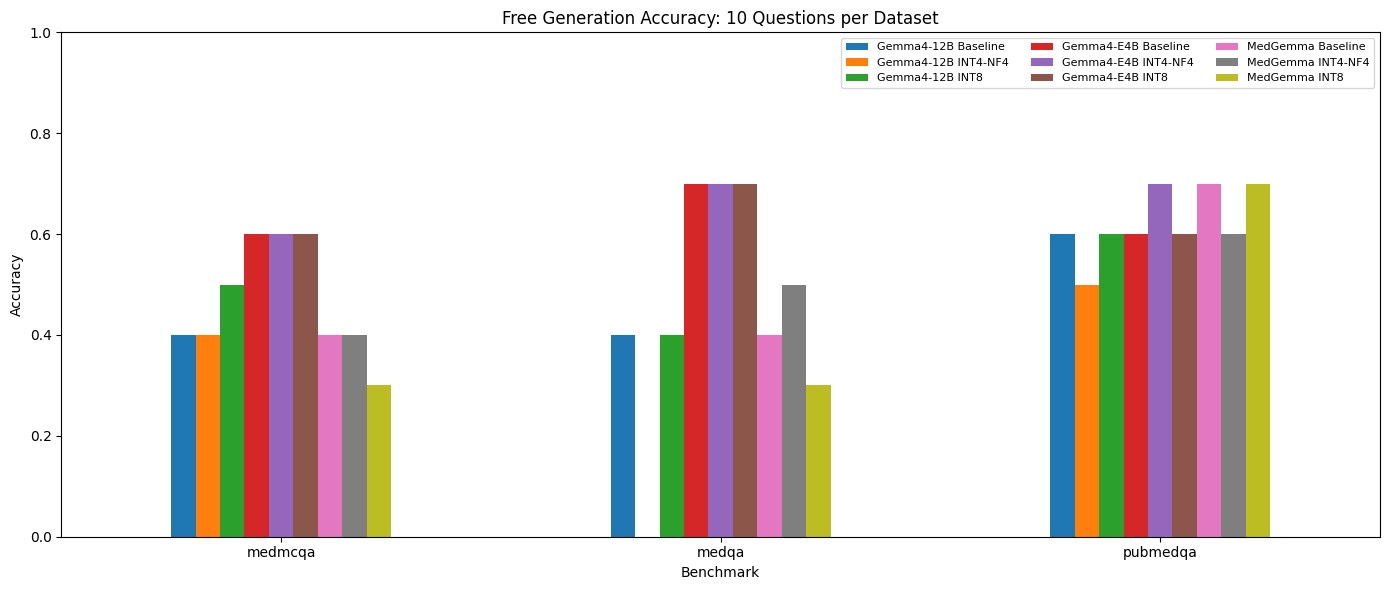

Saved raw: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_freegen10_raw_predictions.csv
Saved summary: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_freegen10_summary.csv
Saved figure: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/figures/clean_three_model_v6_25d8fa6d6b2ca4bb_freegen10_accuracy.png
Saved failures: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_20260819/clean_three_model_v6_25d8fa6d6b2ca4bb_freegen10_failures.json


In [35]:
# Standalone Free Generation Smoke Test: 10 questions/dataset/configuration
# Assumes the notebook setup cells already defined:
# ACTIVE_FAMILIES, ACTIVE_PRECISIONS, MODEL_FAMILIES, normalized_datasets,
# load_family_processor, load_family_model, unload_model, format_model_prompt,
# generate_once, extract_answer, save_csv/save_json optional, OUTPUT_DIR/RUN_PREFIX optional

import gc
import json
import math
import time
import traceback
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

FREEGEN_ONLY_N = 10
FREEGEN_ONLY_MAX_NEW_TOKENS = 64
FREEGEN_ONLY_PREFIX = globals().get("RUN_PREFIX", "freegen_only") + "_freegen10"

freegen_rows = []
freegen_failures = []

def _freegen_output_dir():
    out = Path(globals().get("OUTPUT_DIR", "."))
    out.mkdir(parents=True, exist_ok=True)
    (out / "figures").mkdir(parents=True, exist_ok=True)
    return out

def _freegen_model_tags(family, precision, model_id):
    return {
        "model_family": family,
        "precision": precision,
        "model_id": model_id,
        "model_configuration": f"{family} {precision}",
    }

out_dir = _freegen_output_dir()

for family in ACTIVE_FAMILIES:
    settings = MODEL_FAMILIES[family]
    model_id = settings["model_id"]
    revision = settings.get("resolved_revision") or settings.get("revision")

    for precision in ACTIVE_PRECISIONS:
        config_name = f"{family} {precision}"
        model = processor = None

        try:
            print(f"\n=== FreeGen10: {config_name} ({model_id}) ===")

            unload_model()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats()

            processor = load_family_processor(model_id, revision)
            model, actual_dtype, quant_method = load_family_model(model_id, revision, precision)

            tags = _freegen_model_tags(family, precision, model_id)
            tags.update({
                "actual_dtype": actual_dtype,
                "quantization_method": quant_method,
                "freegen_max_new_tokens": FREEGEN_ONLY_MAX_NEW_TOKENS,
            })

            for benchmark, samples in normalized_datasets.items():
                selected = samples[:FREEGEN_ONLY_N]

                for sample in tqdm(selected, desc=f"{config_name} - {benchmark} - freegen10"):
                    prompt = format_model_prompt(sample, processor, "free_generation")

                    started = time.perf_counter()
                    response = ""
                    prediction = "INVALID"
                    token_count = 0
                    hit_cap = False
                    error = None

                    try:
                        response, token_count, latency, hit_cap = generate_once(
                            model,
                            processor,
                            prompt,
                            FREEGEN_ONLY_MAX_NEW_TOKENS,
                        )
                        prediction = extract_answer(response, sample["choices"])
                    except Exception as exc:
                        latency = time.perf_counter() - started
                        error = f"{type(exc).__name__}: {exc}"

                    is_valid = prediction in sample["choices"]
                    is_correct = prediction == sample["answer"]

                    status = (
                        "error" if error
                        else "truncated" if hit_cap and not is_valid
                        else "invalid" if not is_valid
                        else "valid"
                    )

                    freegen_rows.append({
                        **tags,
                        "evaluation_mode": "free_generation_only_10",
                        "benchmark": benchmark,
                        "sample_id": sample["id"],
                        "gold_answer": sample["answer"],
                        "predicted_answer": prediction,
                        "is_correct": bool(is_correct),
                        "is_valid": bool(is_valid),
                        "response_status": status,
                        "hit_token_cap": bool(hit_cap),
                        "generated_tokens": int(token_count),
                        "latency_seconds": float(latency),
                        "raw_response": response,
                        "error": error,
                    })

        except Exception as exc:
            freegen_failures.append({
                "model_configuration": config_name,
                "model_family": family,
                "precision": precision,
                "model_id": model_id,
                "error": f"{type(exc).__name__}: {exc}",
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", freegen_failures[-1]["error"])

        finally:
            try:
                del model
                del processor
            except Exception:
                pass
            unload_model()
            gc.collect()

# Save raw results
freegen_df = pd.DataFrame(freegen_rows)
failures_df = pd.DataFrame(freegen_failures)

raw_path = out_dir / f"{FREEGEN_ONLY_PREFIX}_raw_predictions.csv"
summary_path = out_dir / f"{FREEGEN_ONLY_PREFIX}_summary.csv"
failure_path = out_dir / f"{FREEGEN_ONLY_PREFIX}_failures.json"

freegen_df.to_csv(raw_path, index=False)
failure_path.write_text(json.dumps(freegen_failures, indent=2, ensure_ascii=False), encoding="utf-8")

# Summarize
if freegen_df.empty:
    print("No free generation rows were produced.")
else:
    summary = (
        freegen_df
        .groupby(["model_family", "precision", "model_configuration", "benchmark"], as_index=False)
        .agg(
            total_evaluated=("sample_id", "count"),
            correct=("is_correct", "sum"),
            valid=("is_valid", "sum"),
            hit_token_cap=("hit_token_cap", "sum"),
            mean_generated_tokens=("generated_tokens", "mean"),
            mean_latency_seconds=("latency_seconds", "mean"),
        )
    )

    summary["accuracy"] = summary["correct"] / summary["total_evaluated"]
    summary["valid_response_rate"] = summary["valid"] / summary["total_evaluated"]
    summary["hit_token_cap_rate"] = summary["hit_token_cap"] / summary["total_evaluated"]

    summary.to_csv(summary_path, index=False)

    display(summary.sort_values(["model_family", "precision", "benchmark"]))

    # Plot accuracy by benchmark
    plot_df = summary.copy()
    plot_df["configuration"] = plot_df["model_family"] + " " + plot_df["precision"]

    pivot = plot_df.pivot_table(
        index="benchmark",
        columns="configuration",
        values="accuracy",
        fill_value=0,
    )

    ax = pivot.plot(kind="bar", figsize=(14, 6))
    ax.set_title("Free Generation Accuracy: 10 Questions per Dataset")
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Benchmark")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, ncol=3)
    plt.xticks(rotation=0)
    plt.tight_layout()

    fig_path = out_dir / "figures" / f"{FREEGEN_ONLY_PREFIX}_accuracy.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved raw:", raw_path)
    print("Saved summary:", summary_path)
    print("Saved figure:", fig_path)
    print("Saved failures:", failure_path)

## Outputs

Results are saved live under `MyDrive/gemma4_medgemma_benchmark_results/runs/corrected_pipeline_v6_YYYYMMDD`. `CURRENT_RUN.txt` records the active folder, while `LATEST_EXPORT.txt` records the newest ZIP.

The same artifacts are mirrored into `organized/`:

- raw predictions
- benchmark summary
- performance summary
- memory summary
- failures JSON
- comparison CSV files
- figures PNG files
- final analysis markdown
- `OUTPUT_MANIFEST.json`, which lists every verified file and byte size
